# Notebook de réplication d’un autocall par vanilles

## Objectif

L’idée de ce notebook est de construire une base propre pour étudier la réplication statique d’un autocall par un panier fini de vanilles.

On veut ici :

- définir clairement le produit cible ;
- poser un modèle de pricing de référence ;
- construire un univers de vanilles ;
- tester un benchmark naïf ;
- rendre le tout plus lisible et plus simple à déboguer.


In [36]:
from __future__ import annotations

from typing import Any, Dict, Optional
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from IPython.display import display


import yfinance as yf

In [37]:
np.set_printoptions(linewidth=10000)

## 2. Principe général

On part d’un autocall simple, puis on cherche à l’approximer par une combinaison linéaire de 100 à 200 vanilles observables sur le marché.

La logique du notebook est la suivante :

1. construire le payoff cible de l’autocall ;
2. construire un univers de vanilles ;
3. price les deux dans un même cadre ;
4. résoudre un problème de fit direct ;
5. mesurer la qualité de l’approximation ;
6. identifier les limites de cette baseline.

Cette baseline servira de point de comparaison pour une méthode plus intelligente fondée sur la structure du produit.

---

## 3. Produit cible

On commence par un autocall simple, à une seule sous-jacente, avec :

- plusieurs dates de constatation ;
- un coupon fixe ;
- un niveau d’autocall ;
- une barrière down éventuelle ;
- un payoff terminal simple en cas de non-rappel.

Il est important de ne pas introduire trop de complexité dès le départ.  
Le produit doit être assez riche pour être représentatif, mais assez simple pour être codé, testé et debuggué rapidement.

In [64]:
import importlib
import products_core
importlib.reload(products_core)

from products_core import AutocallProduct, VanillaProduct, EuropeanCall, EuropeanPut, BinaryCall, BinaryPut, Cash, build_vanilla_universe, vanilla_universe_to_dataframe

## Tests de cohérence du payoff de l’autocall

On construit ici trois trajectoires de prix artificielles pour vérifier que la fonction `compute_autocall_payoff` réagit correctement dans les trois situations clés :

- **Cas 1** : le produit est appelé au premier coupon.
- **Cas 2** : le produit n’est jamais appelé et la barrière n’est jamais touchée.
- **Cas 3** : le produit n’est pas appelé, mais la barrière est touchée pendant la vie du produit.

In [39]:
dates = pd.bdate_range("2025-01-01", periods=280)    # 1 an de jours ouvrés
prices = pd.Series(100.0, index=dates)

# Cas 1 : autocall au premier coupon
prices1 = prices.copy()
prices1.loc[dates[63:]] = 101.0  # autour du 3e mois

# Cas 2 : jamais appelé, pas de barrière
prices2 = prices.copy()             # spot initial constant à 99% du nominal
prices2.loc[:] = 99.0

# Cas 3 : barrière touchée = 70
prices3 = prices.copy()
prices3.loc[dates[50:80]] = 55.0
prices3.loc[dates[80:]] = 99.0

prod = AutocallProduct()

res1 = prod.compute_autocall_payoff(prices1, start_date=dates[0])
res2 = prod.compute_autocall_payoff(prices2, start_date=dates[0])
res3 = prod.compute_autocall_payoff(prices3, start_date=dates[0])

print("Called : ", res1["called"], "/ Call Date : ", res1["call_date"], "/ Undiscounted Payoff : ", res1["undiscounted_payoff"])
print("Called : ", res2["called"], "/ Call Date : ", res2["call_date"], "/ Barrier Hit : ", res2["barrier_hit"], "/ Undiscounted Payoff : ", res2["undiscounted_payoff"])
print("Called : ", res3["called"], "/ Call Date : ", res3["call_date"], "/ Barrier Hit : ", res3["barrier_hit"], "/ Undiscounted Payoff : ", res3["undiscounted_payoff"])

Called :  True / Call Date :  2025-04-01 00:00:00 / Undiscounted Payoff :  105.0
Called :  False / Call Date :  None / Barrier Hit :  False / Undiscounted Payoff :  120.0
Called :  False / Call Date :  None / Barrier Hit :  True / Undiscounted Payoff :  114.0


## 4. Univers de vanilles

On construit ensuite une base de vanilles couvrant :

- plusieurs maturités ;
- plusieurs strikes autour du spot ;
- des calls et des puts ;
- idéalement des instruments proches des dates de call de l’autocall.

L’idée est de disposer d’un dictionnaire d’instruments suffisamment riche pour que le fit direct ait une chance raisonnable de fonctionner.

Le point critique ici est la diversité du panier.  
Un panier trop concentré autour de l’ATM donne un fit fragile ; un panier trop large peut devenir instable numériquement sans régularisation.

---

## 5. Modèle de pricing de référence

Pour la première version du notebook, on choisit un cadre de pricing simple et contrôlé.

Le plus naturel est de commencer avec :

- Black-Scholes comme modèle de base ;
- éventuellement une surface implicite en second temps ;
- puis plus tard un modèle plus riche si nécessaire.

Le but est de séparer clairement :

- l’erreur liée à la réplication ;
- l’erreur liée au modèle de prix ;
- l’erreur liée à la discrétisation.

Tant que ces trois sources d’erreur ne sont pas séparées, les résultats seront difficiles à interpréter.

In [40]:
from products_core import norm_cdf, norm_pdf, bs_d1_d2, _year_fraction

## Test des produits européens et des parités Black-Scholes

On fixe ici un jeu de paramètres simple afin de tester les produits de base :

- un call européen,
- un put européen,
- un call binaire,
- un put binaire.

L’objectif est de vérifier que :
- les prix Black-Scholes sont cohérents,
- la parité put-call est bien respectée,
- la parité entre les deux options binaires est bien vérifiée,
- les payoffs terminaux correspondent aux définitions théoriques.

In [41]:
# ------------------------------------------------------------
# Paramètres de test
# ------------------------------------------------------------
valuation_date = pd.Timestamp("2026-06-20")
maturity = pd.Timestamp("2027-06-20")

spot = 100.0
strike = 100.0
rate = 0.03
dividend_yield = 0.01
vol = 0.20              
# On suppose que la volatilité est constante pour simplifier l'exemple, et unique pour toutes les options. 
# Dans la réalité, on utiliserait une surface de volatilité.

# ------------------------------------------------------------
# Création des produits
# ------------------------------------------------------------
call = EuropeanCall(name="Call_100",        strike=strike,maturity_date=maturity,notional=1.0)
put = EuropeanPut(  name="Put_100",         strike=strike,maturity_date=maturity,notional=1.0)
bcall = BinaryCall( name="BinaryCall_100",  strike=strike,maturity_date=maturity,notional=1.0)
bput = BinaryPut(   name="BinaryPut_100",   strike=strike,maturity_date=maturity,notional=1.0)

# ------------------------------------------------------------
# Prix Black-Scholes
# ------------------------------------------------------------
c = call.   price_bs(spot, valuation_date, rate, dividend_yield, vol)
p = put.    price_bs(spot, valuation_date, rate, dividend_yield, vol)
bc = bcall. price_bs(spot, valuation_date, rate, dividend_yield, vol)
bp = bput.  price_bs(spot, valuation_date, rate, dividend_yield, vol)

print("Call      :", c)
print("Put       :", p)
print("Binary call:", bc)
print("Binary put :", bp)

# ------------------------------------------------------------
# Tests de cohérence
# ------------------------------------------------------------
T = _year_fraction(valuation_date, maturity)

# Parité put-call : C - P = S0 * exp(-q*T) - K * exp(-r*T)
# Parité binaire : BC + BP = exp(-r*T)
lhs = c - p
rhs = spot * math.exp(-dividend_yield * T) - strike * math.exp(-rate * T)

print("\nPut-call parity: C - P = S0 * exp(-q*T) - K * exp(-r*T)")
print("LHS =", lhs)
print("RHS =", rhs)
print("Erreur absolue =", abs(lhs - rhs))

print("\nBinary parity: BC + BP = e^{-rT}")
print("BC + BP =", bc + bp)
print("e^{-rT}  =", math.exp(-rate * T))
print("Erreur absolue =", abs((bc + bp) - math.exp(-rate * T)))

# ------------------------------------------------------------
# Payoff terminal simple
# ------------------------------------------------------------
spot_T = 112.0
print("\nPayoffs à S_T = 112:")
print("Call payoff :", call.payoff(spot_T))
print("Put payoff  :", put.payoff(spot_T))
print("BC payoff   :", bcall.payoff(spot_T))
print("BP payoff   :", bput.payoff(spot_T))

Call      : 8.827321225352122
Put       : 6.866891205286137
Binary call: 0.4852227667742541
Binary put : 0.4852227667742541

Put-call parity: C - P = S0 * exp(-q*T) - K * exp(-r*T)
LHS = 1.960430020065985
RHS = 1.960430020065985
Erreur absolue = 0.0

Binary parity: BC + BP = e^{-rT}
BC + BP = 0.9704455335485082
e^{-rT}  = 0.9704455335485082
Erreur absolue = 0.0

Payoffs à S_T = 112:
Call payoff : 12.0
Put payoff  : 0.0
BC payoff   : 1.0
BP payoff   : 0.0


## Simulation Black-Scholes d'une trajectoire de prix

Cette fonction génère une trajectoire quotidienne du sous-jacent sous le modèle Black-Scholes.  
Elle servira ensuite à simuler des scénarios de marché pour le pricing Monte Carlo de l'autocall.

In [42]:
import monte_carlo
importlib.reload(monte_carlo)

from monte_carlo import simulate_gbm_path

## Pricing Monte Carlo de l'autocall

On simule un grand nombre de trajectoires du sous-jacent, puis on calcule le payoff de l'autocall sur chaque trajectoire.  
Le prix final est obtenu en moyennant les cashflows actualisés.

In [43]:
from monte_carlo import price_autocall_bs_mc

## Construction de la grille de travail

On construit ici deux axes de calcul :
- une liste de dates pertinentes,
- une grille de spots autour du spot initial.

Cette grille sert à étudier la valeur de l'autocall en fonction du temps et du niveau du sous-jacent.

In [44]:
import benchmark_general
importlib.reload(benchmark_general)
from benchmark_general import build_autocall_training_grid_axes, build_naive_vanilla_basis

## Surface de prix sur la grille

On calcule le prix de l'autocall pour chaque couple (date, spot) de la grille afin d'obtenir une matrice de prix.

In [45]:
import target_price
importlib.reload(target_price)

from target_price import price_autocall_on_tensor_bs_mc

## Prix de l'autocall sur une grille de dates et de spots

On instancie ici un autocall simple, puis on calcule :

1. un prix Monte Carlo sur un scénario de référence ;
2. une matrice de prix sur une grille de travail composée :
   - de plusieurs dates pertinentes,
   - de plusieurs niveaux de spot autour de `spot0`.

Le tableau affiché représente donc une surface de prix de l'autocall :
- les **lignes** correspondent aux dates,
- les **colonnes** correspondent aux spots,
- chaque case contient le prix estimé du produit pour ce couple (date, spot).

Cela permet de visualiser comment la valeur de l'autocall varie à la fois avec le temps et avec le niveau du sous-jacent.

In [46]:
prod = AutocallProduct(notional=100.0,autocall_strike=1.00,coupon_rate=0.02,down_barrier=0.70,observation_months=[3, 6, 9, 12],)

valuation_date = pd.Timestamp("2026-06-20")
maturity_date = pd.Timestamp("2027-06-20")
spot0 = 100.0
rate = 0.03
dividend_yield = 0.01
vol = 0.20

res = price_autocall_bs_mc(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,n_paths=2000)
print(res["actualized_price"], res["std_error"])

99.08412193765336 0.22082624538496165


In [47]:
dates, spots = build_autocall_training_grid_axes(spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,n_spots=15,spot_min_mult=0.6,spot_max_mult=1.4,include_call_dates=True,product=prod)

price_tensor = price_autocall_on_tensor_bs_mc(product=prod,dates=dates,spots=spots,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,n_paths=200,seed=42)

df_view = pd.DataFrame(price_tensor, index=[d.strftime("%Y-%m-%d") for d in dates], columns=np.round(spots, 2))          # tableau des prix simulés de l'autocall sur la grille (dates en lignes, spots en colonnes)       
display(df_view)
print("Prix de l'autocall : lignes = dates, colonnes = spots")


#Les 4 lignes viennent des dates d’observation : typiquement 3, 6, 9, 12 mois si observation_months = [3, 6, 9, 12].
#Les 15 colonnes viennent de n_spots=15, donc tu as pris 15 valeurs de spot entre 0.6 * spot0 et 1.4 * spot0.
#La dernière ligne entièrement à 100 suggère qu’à cette date, le payoff est identique quel que soit le spot dans ta grille, ce qui est cohérent avec un produit arrivé à une situation où le remboursement est fixé par le contrat.

,60.00,65.71,71.43,77.14,82.86,88.57,94.29,100.00,105.71,111.43,117.14,122.86,128.57,134.29,140.00
2026-09-20,99.553877,99.553877,99.563729,99.563729,99.569797,99.575864,99.581931,99.581931,99.588126,99.449804,99.437542,99.437542,99.437542,99.420041,99.426236
2026-12-20,100.300584,100.304323,100.298210,100.298210,100.298210,100.298210,100.292097,100.298210,100.294471,100.294471,100.294471,100.288359,100.294471,100.294471,100.300584
2027-03-20,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847
2027-06-20,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


Prix de l'autocall : lignes = dates, colonnes = spots


## 6. Formulation du benchmark naïf : réplication par un portefeuille de vanilles

Le benchmark consiste à approximer la valeur de l’autocall par une combinaison linéaire de vanilles :

$$
V_{\text{autocall}}(d,s) \approx \sum_{i=1}^N w_i V_i(d,s)
$$

où :

- $V_{\text{autocall}}$ est la valeur du produit cible ;
- $V_i$ est la valeur de la vanille $i$ ;
- $w_i$ est le poids associé.
- d = une date de valorisation
- s = un niveau de spot 

Ce benchmark doit être traité comme une approximation statique simple, pas comme une réplication exacte.
L'idée est volontairement naïve :
- on construit une base de produits simples (calls / puts, éventuellement en grande quantité),
- on ajuste leurs poids pour reproduire au mieux la surface de prix de l'autocall,
- on compare ensuite la qualité de la réplication obtenue.

Ce benchmark sert de point de comparaison simple avant d'aller vers des méthodes plus sophistiquées de calibration ou d'approximation.

## Benchmark naïf par étapes

On construit ici une réplication simple de l'autocall à l'aide d'options vanilles européennes, en procédant par niveaux de complexité.

La démarche est la suivante :
1. commencer avec un portefeuille composé uniquement de calls ;
2. enrichir ensuite la base avec des calls et des puts ;
3. ajouter enfin les options binaires pour vérifier si elles améliorent sensiblement la qualité de réplication.

L’objectif est de comparer, étape par étape, la capacité de chaque famille de produits à reproduire la surface de prix de l’autocall.

In [48]:
# ============================================================
# 6. BENCHMARK NAÏF :     Calls -> Calls/Puts -> Calls/Puts/Binaires
# ============================================================

# ------------------------------------------------------------
# Pricing d'un panier sur une grille (dates x spots)
# ------------------------------------------------------------
from target_price import price_vanilla_basis_on_grid

In [49]:
# ------------------------------------------------------------
# 3) Fit ridge simple (benchmark naïf)
# ------------------------------------------------------------
from benchmark_general import fit_linear, fit_lstsq


# ------------------------------------------------------------
# 4) Métriques
# ------------------------------------------------------------
from benchmark_general import benchmark_metrics

In [50]:
# ------------------------------------------------------------
# 5) Pipeline complet
# ------------------------------------------------------------
from target_price import run_naive_benchmark_price

# ------------------------------------------------------------
# 6) Affichage / comparaison
# ------------------------------------------------------------
from benchmark_general import plot_benchmark_surface

=== CALLS - l1 ===
Train: {'mae': 1.0847619099270862e-12, 'rmse': 1.2890636990129834e-12, 'max_abs_error': 2.3874235921539366e-12, 'mean_error': -1.0847619099270862e-12}
Test : {'mae': 0.9520863262899373, 'rmse': 1.1660638553119491, 'max_abs_error': 1.9870915674502498, 'mean_error': 0.639292938852671}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,1.013395
48,C_20261020_110.00,EuropeanCall,2026-10-20,110.0,-0.881019
50,C_20261020_120.00,EuropeanCall,2026-10-20,120.0,0.768765
74,C_20261220_110.00,EuropeanCall,2026-12-20,110.0,0.428665
76,C_20261220_120.00,EuropeanCall,2026-12-20,120.0,-0.398046
49,C_20261020_115.00,EuropeanCall,2026-10-20,115.0,-0.364429
47,C_20261020_105.00,EuropeanCall,2026-10-20,105.0,0.344396
46,C_20261020_100.00,EuropeanCall,2026-10-20,100.0,0.322166
63,C_20261120_120.00,EuropeanCall,2026-11-20,120.0,-0.297384
51,C_20261020_125.00,EuropeanCall,2026-10-20,125.0,0.274503


=== CALLS + PUTS - l1 ===
Train: {'mae': 9.000207986294602e-14, 'rmse': 1.1123266067299841e-13, 'max_abs_error': 2.8421709430404007e-13, 'mean_error': 2.936909974475081e-14}
Test : {'mae': 0.7079814225927544, 'rmse': 0.8282592843878516, 'max_abs_error': 1.381130711207959, 'mean_error': 0.18402291341768992}


,name,kind,maturity_date,strike,weight
95,C_20261020_110.00,EuropeanCall,2026-10-20,110.0,-0.449887
96,P_20261020_110.00,EuropeanPut,2026-10-20,110.0,-0.430163
100,P_20261020_120.00,EuropeanPut,2026-10-20,120.0,0.406698
99,C_20261020_120.00,EuropeanCall,2026-10-20,120.0,0.362663
0,CASH_20270620,Cash,2027-06-20,0.0,0.255212
151,C_20261220_120.00,EuropeanCall,2026-12-20,120.0,-0.234411
148,P_20261220_110.00,EuropeanPut,2026-12-20,110.0,0.228426
97,C_20261020_115.00,EuropeanCall,2026-10-20,115.0,-0.198048
147,C_20261220_110.00,EuropeanCall,2026-12-20,110.0,0.195875
125,C_20261120_120.00,EuropeanCall,2026-11-20,120.0,-0.176929


=== FULL - l1 ===
Train: {'mae': 2.0084674664152165e-13, 'rmse': 2.5015410247706903e-13, 'max_abs_error': 6.679101716144942e-13, 'mean_error': 1.5252984060983483e-13}
Test : {'mae': 0.7221065105835137, 'rmse': 0.8164686348699798, 'max_abs_error': 1.2659606736494595, 'mean_error': 0.2860178603854616}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,0.254335
1,C_20260720_70.00,EuropeanCall,2026-07-20,70.0,0.080167
53,C_20260820_70.00,EuropeanCall,2026-08-20,70.0,0.080167
105,C_20260920_70.00,EuropeanCall,2026-09-20,70.0,0.080167
102,P_20260820_130.00,EuropeanPut,2026-08-20,130.0,0.060333
50,P_20260720_130.00,EuropeanPut,2026-07-20,130.0,0.060333
154,P_20260920_130.00,EuropeanPut,2026-09-20,130.0,0.060333
309,C_20261220_130.00,EuropeanCall,2026-12-20,130.0,-0.058893
622,P_20270620_130.00,EuropeanPut,2027-06-20,130.0,0.054548
570,P_20270520_130.00,EuropeanPut,2027-05-20,130.0,0.053421


,family,train_mae,train_rmse,train_max_abs_error,train_mean_error,test_mae,test_rmse,test_max_abs_error,test_mean_error
0,calls,1.084762e-12,1.289064e-12,2.387424e-12,-1.084762e-12,0.952086,1.166064,1.987092,0.639293
1,calls_puts,9.000208e-14,1.112327e-13,2.842171e-13,2.936910e-14,0.707981,0.828259,1.381131,0.184023
2,full,2.008467e-13,2.501541e-13,6.679102e-13,1.525298e-13,0.722107,0.816469,1.265961,0.286018


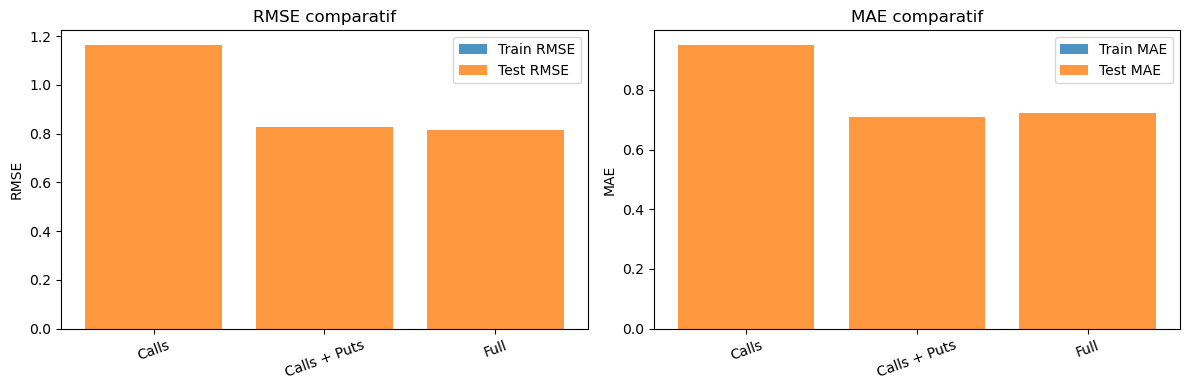

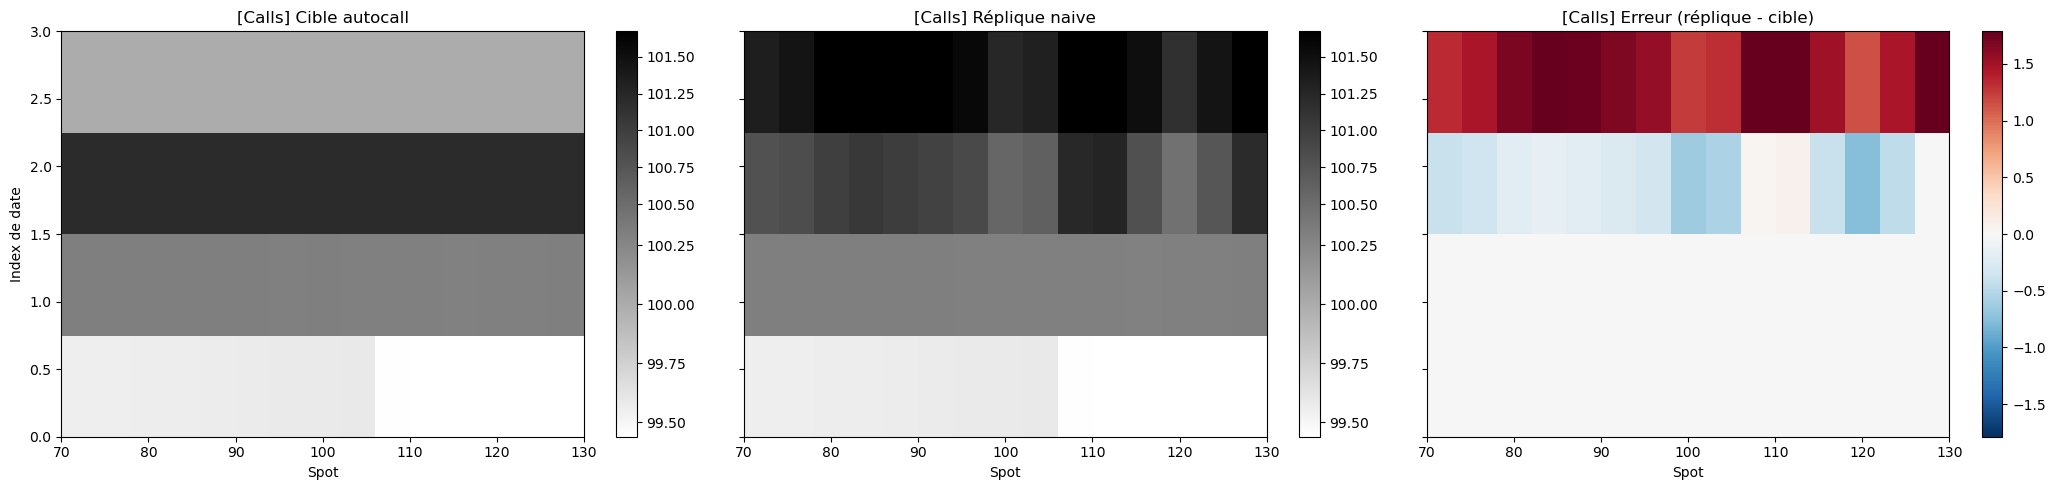

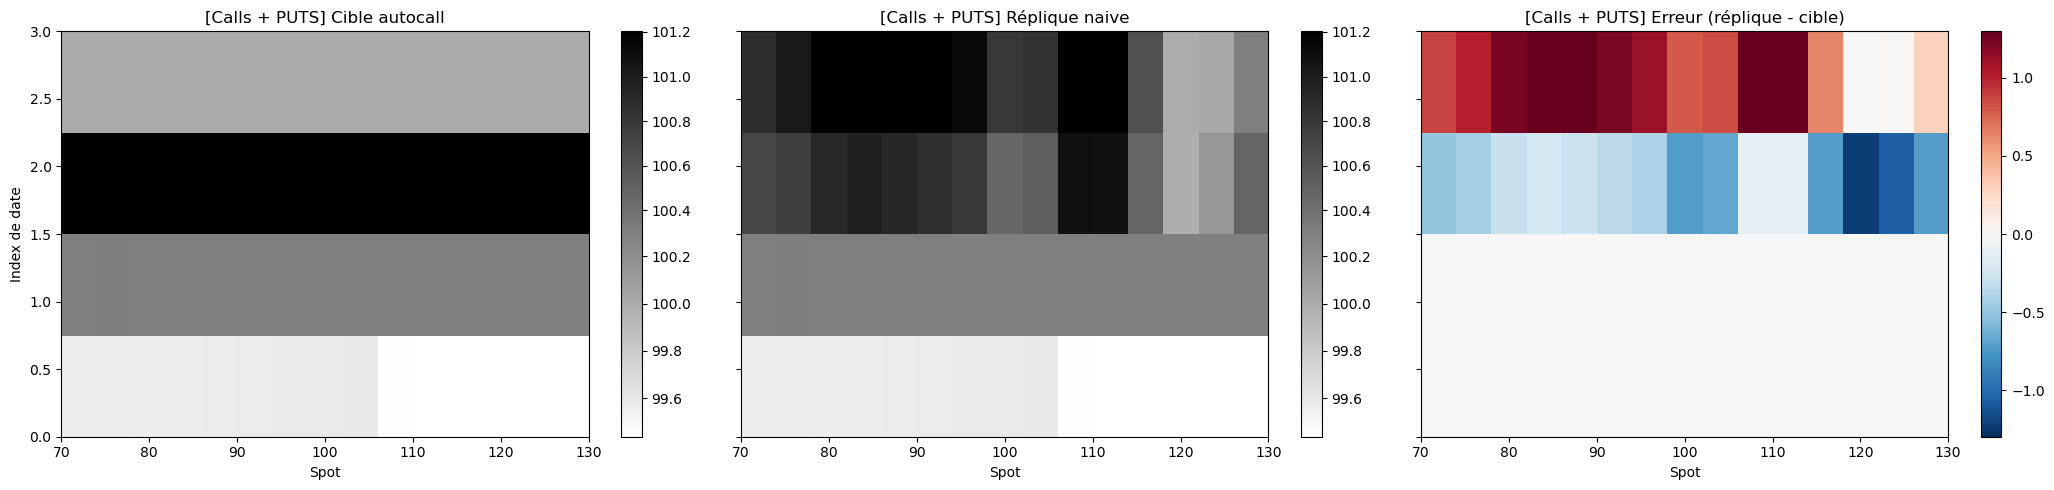

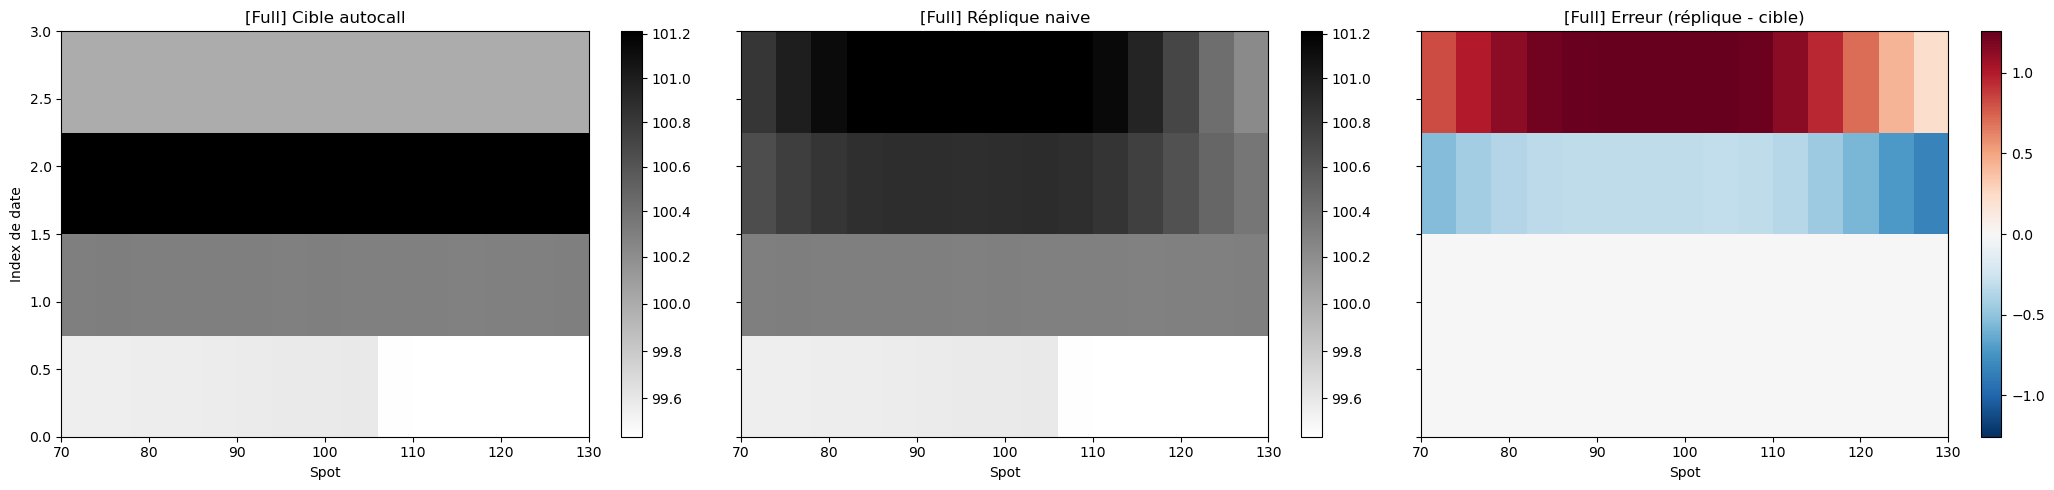

=== CALLS - l2 ===
Train: {'mae': 1.8927522186610682e-07, 'rmse': 3.8168742921059517e-07, 'max_abs_error': 1.2074322768285128e-06, 'mean_error': 6.726471231862282e-14}
Test : {'mae': 0.9774743090679489, 'rmse': 1.2219483670983318, 'max_abs_error': 2.016975833144855, 'mean_error': 0.7065141777632159}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,1.017774
48,C_20261020_110.00,EuropeanCall,2026-10-20,110.0,-0.881035
50,C_20261020_120.00,EuropeanCall,2026-10-20,120.0,0.768495
74,C_20261220_110.00,EuropeanCall,2026-12-20,110.0,0.428499
76,C_20261220_120.00,EuropeanCall,2026-12-20,120.0,-0.397970
49,C_20261020_115.00,EuropeanCall,2026-10-20,115.0,-0.364440
47,C_20261020_105.00,EuropeanCall,2026-10-20,105.0,0.344179
46,C_20261020_100.00,EuropeanCall,2026-10-20,100.0,0.321705
63,C_20261120_120.00,EuropeanCall,2026-11-20,120.0,-0.297259
51,C_20261020_125.00,EuropeanCall,2026-10-20,125.0,0.274416


=== CALLS + PUTS - l2 ===
Train: {'mae': 9.475723696065567e-08, 'rmse': 1.9098311360532256e-07, 'max_abs_error': 6.040089459702358e-07, 'mean_error': 6.158037043254202e-15}
Test : {'mae': 0.9994874755951382, 'rmse': 1.2652396955431329, 'max_abs_error': 2.1059096617102284, 'mean_error': 0.7605185739179007}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,1.039031
96,P_20261020_110.00,EuropeanPut,2026-10-20,110.0,-0.441238
95,C_20261020_110.00,EuropeanCall,2026-10-20,110.0,-0.440365
99,C_20261020_120.00,EuropeanCall,2026-10-20,120.0,0.384487
100,P_20261020_120.00,EuropeanPut,2026-10-20,120.0,0.383086
147,C_20261220_110.00,EuropeanCall,2026-12-20,110.0,0.214801
148,P_20261220_110.00,EuropeanPut,2026-12-20,110.0,0.213440
152,P_20261220_120.00,EuropeanPut,2026-12-20,120.0,-0.199405
151,C_20261220_120.00,EuropeanCall,2026-12-20,120.0,-0.199113
98,P_20261020_115.00,EuropeanPut,2026-10-20,115.0,-0.184213


=== FULL - l2 ===
Train: {'mae': 2.9394205588081e-11, 'rmse': 4.7050249506974354e-11, 'max_abs_error': 1.56106239046494e-10, 'mean_error': -8.100187187665142e-14}
Test : {'mae': 0.9959192496719093, 'rmse': 1.3203511190569872, 'max_abs_error': 1.954240610612004, 'mean_error': 0.8654362660585956}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,1.041522
294,P_20261220_110.00,EuropeanPut,2026-12-20,110.0,-0.007881
33,C_20260720_110.00,EuropeanCall,2026-07-20,110.0,0.007157
137,C_20260920_110.00,EuropeanCall,2026-09-20,110.0,0.007157
85,C_20260820_110.00,EuropeanCall,2026-08-20,110.0,0.007157
293,C_20261220_110.00,EuropeanCall,2026-12-20,110.0,-0.006898
34,P_20260720_110.00,EuropeanPut,2026-07-20,110.0,0.006434
86,P_20260820_110.00,EuropeanPut,2026-08-20,110.0,0.006434
138,P_20260920_110.00,EuropeanPut,2026-09-20,110.0,0.006434
241,C_20261120_110.00,EuropeanCall,2026-11-20,110.0,-0.006222


,family,train_mae,train_rmse,train_max_abs_error,train_mean_error,test_mae,test_rmse,test_max_abs_error,test_mean_error
0,calls,1.892752e-07,3.816874e-07,1.207432e-06,6.726471e-14,0.977474,1.221948,2.016976,0.706514
1,calls_puts,9.475724e-08,1.909831e-07,6.040089e-07,6.158037e-15,0.999487,1.265240,2.105910,0.760519
2,full,2.939421e-11,4.705025e-11,1.561062e-10,-8.100187e-14,0.995919,1.320351,1.954241,0.865436


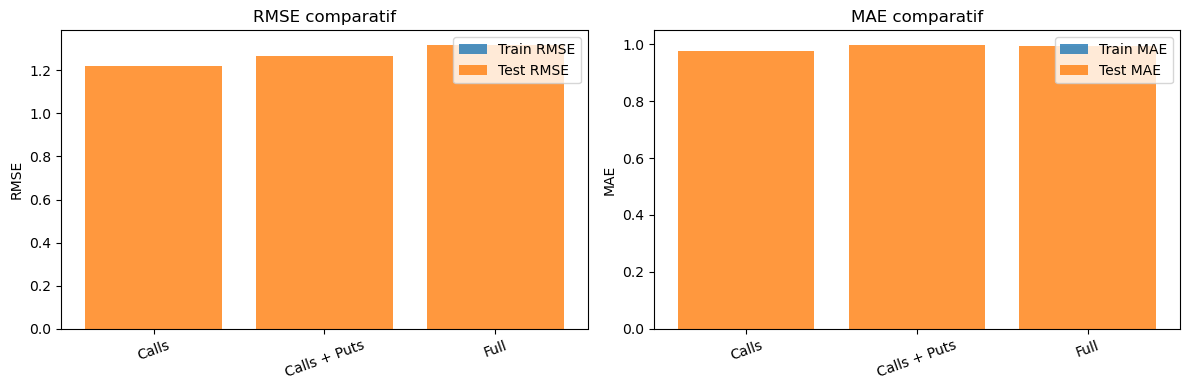

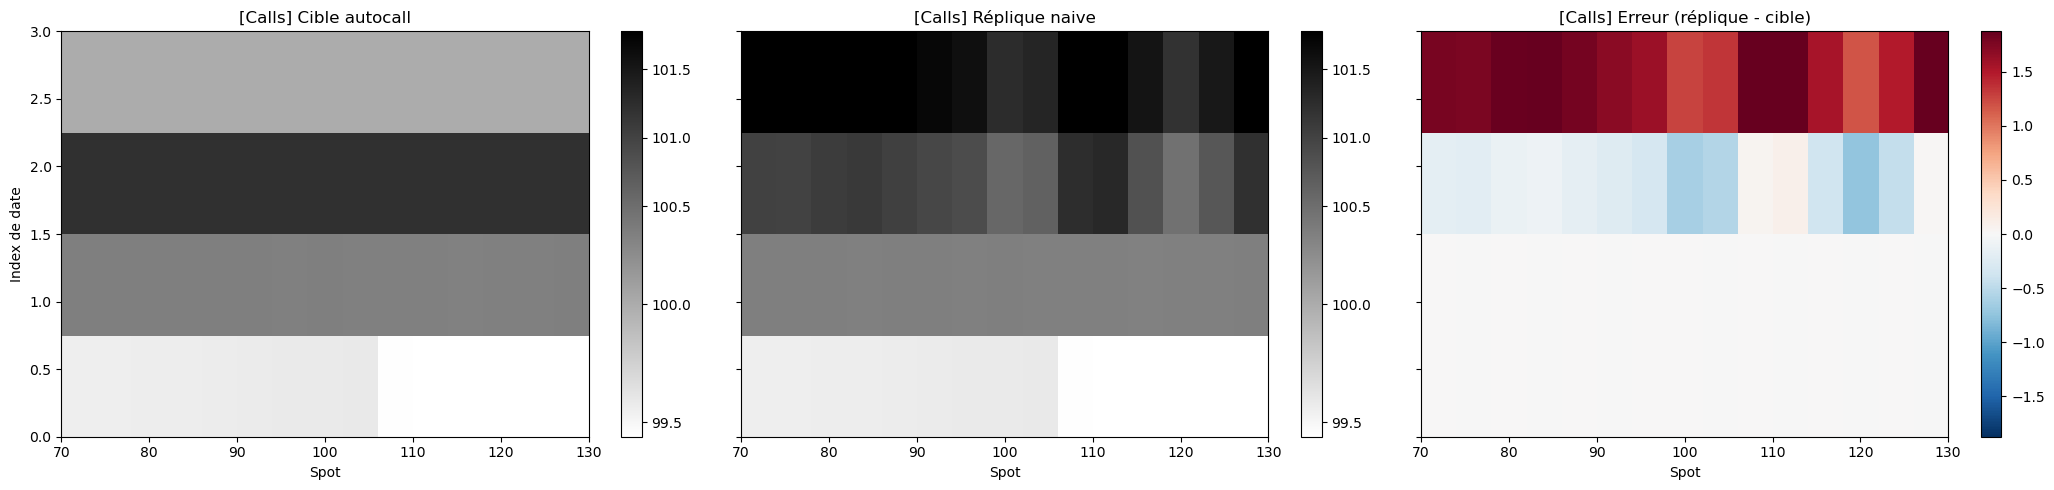

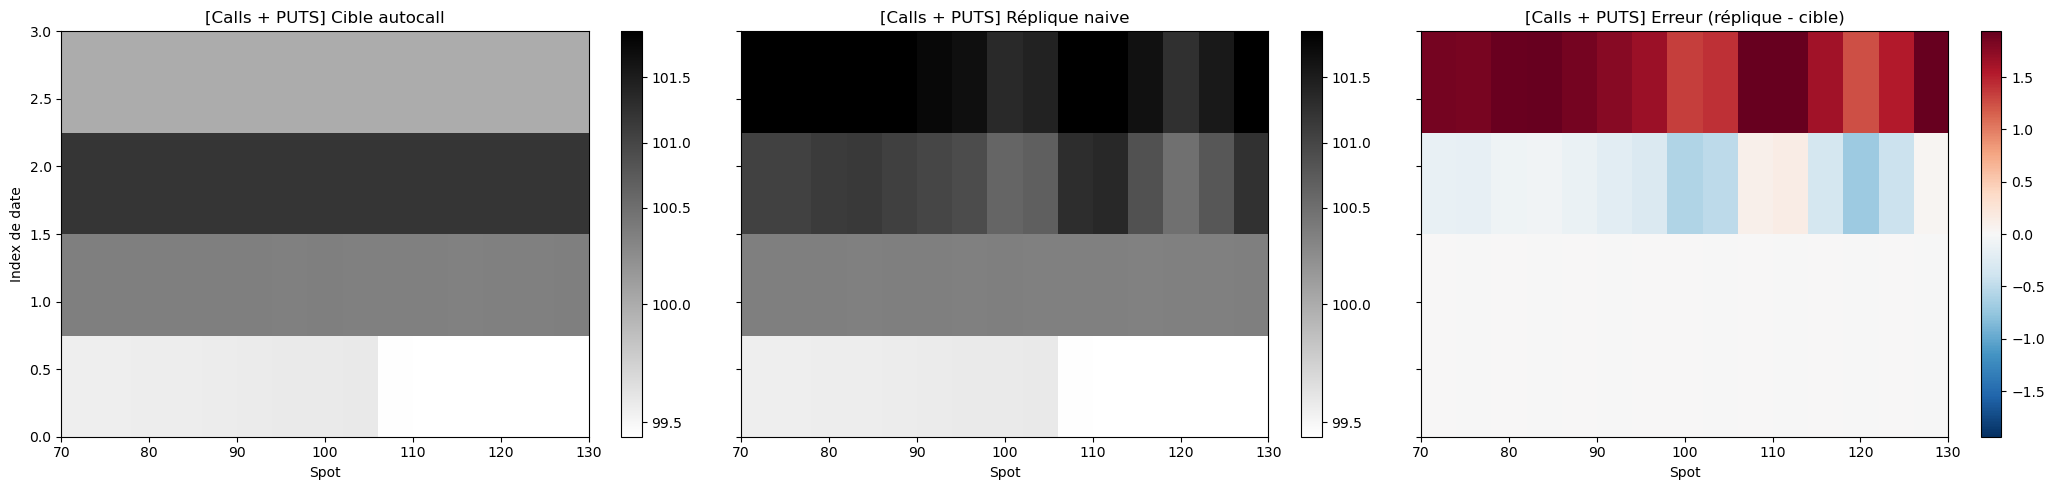

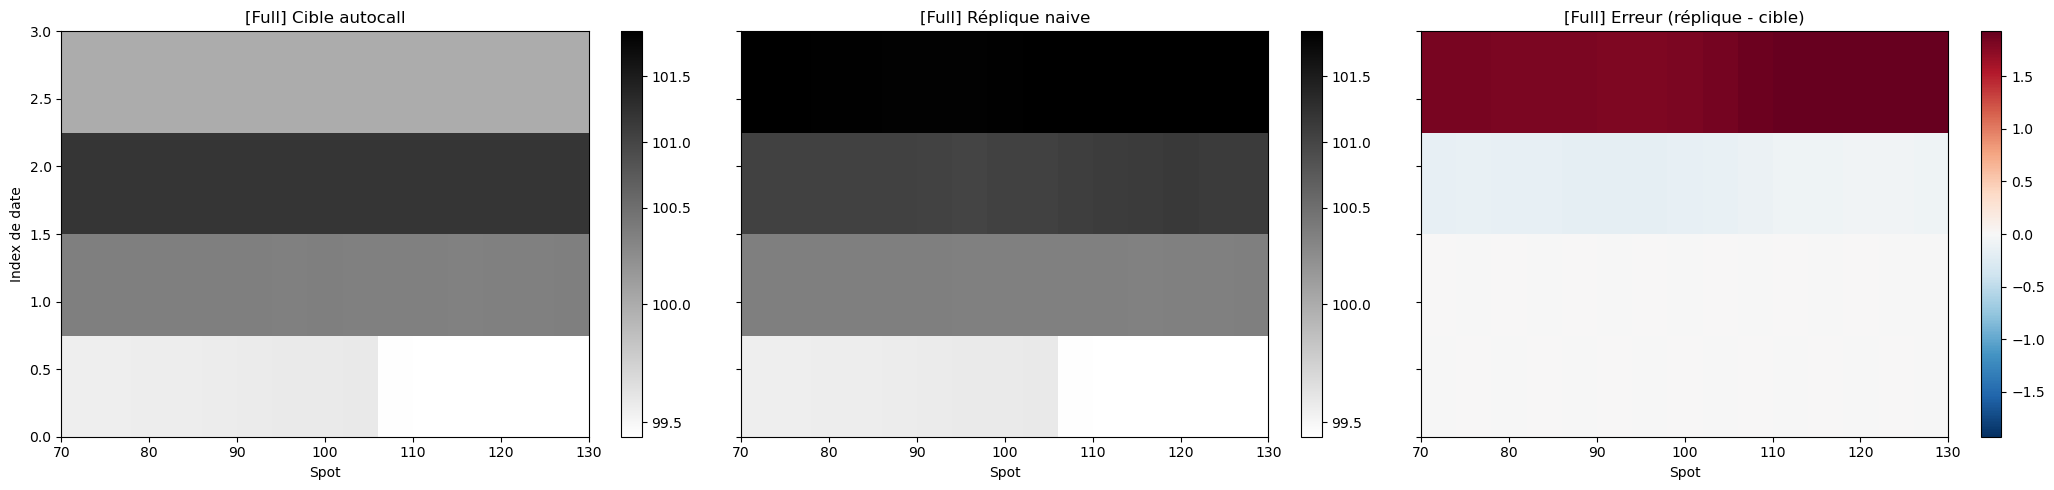

=== CALLS - huber ===
Train: {'mae': 1.0847619099270862e-12, 'rmse': 1.2890636990129834e-12, 'max_abs_error': 2.3874235921539366e-12, 'mean_error': -1.0847619099270862e-12}
Test : {'mae': 0.9520863262899373, 'rmse': 1.1660638553119491, 'max_abs_error': 1.9870915674502498, 'mean_error': 0.639292938852671}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,1.013395
48,C_20261020_110.00,EuropeanCall,2026-10-20,110.0,-0.881019
50,C_20261020_120.00,EuropeanCall,2026-10-20,120.0,0.768765
74,C_20261220_110.00,EuropeanCall,2026-12-20,110.0,0.428665
76,C_20261220_120.00,EuropeanCall,2026-12-20,120.0,-0.398046
49,C_20261020_115.00,EuropeanCall,2026-10-20,115.0,-0.364429
47,C_20261020_105.00,EuropeanCall,2026-10-20,105.0,0.344396
46,C_20261020_100.00,EuropeanCall,2026-10-20,100.0,0.322166
63,C_20261120_120.00,EuropeanCall,2026-11-20,120.0,-0.297384
51,C_20261020_125.00,EuropeanCall,2026-10-20,125.0,0.274503


=== CALLS + PUTS - huber ===
Train: {'mae': 9.000207986294602e-14, 'rmse': 1.1123266067299841e-13, 'max_abs_error': 2.8421709430404007e-13, 'mean_error': 2.936909974475081e-14}
Test : {'mae': 0.7079814225927544, 'rmse': 0.8282592843878516, 'max_abs_error': 1.381130711207959, 'mean_error': 0.18402291341768992}


,name,kind,maturity_date,strike,weight
95,C_20261020_110.00,EuropeanCall,2026-10-20,110.0,-0.449887
96,P_20261020_110.00,EuropeanPut,2026-10-20,110.0,-0.430163
100,P_20261020_120.00,EuropeanPut,2026-10-20,120.0,0.406698
99,C_20261020_120.00,EuropeanCall,2026-10-20,120.0,0.362663
0,CASH_20270620,Cash,2027-06-20,0.0,0.255212
151,C_20261220_120.00,EuropeanCall,2026-12-20,120.0,-0.234411
148,P_20261220_110.00,EuropeanPut,2026-12-20,110.0,0.228426
97,C_20261020_115.00,EuropeanCall,2026-10-20,115.0,-0.198048
147,C_20261220_110.00,EuropeanCall,2026-12-20,110.0,0.195875
125,C_20261120_120.00,EuropeanCall,2026-11-20,120.0,-0.176929


=== FULL - huber ===
Train: {'mae': 2.0084674664152165e-13, 'rmse': 2.5015410247706903e-13, 'max_abs_error': 6.679101716144942e-13, 'mean_error': 1.5252984060983483e-13}
Test : {'mae': 0.7221065105835137, 'rmse': 0.8164686348699798, 'max_abs_error': 1.2659606736494595, 'mean_error': 0.2860178603854616}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,0.254335
1,C_20260720_70.00,EuropeanCall,2026-07-20,70.0,0.080167
53,C_20260820_70.00,EuropeanCall,2026-08-20,70.0,0.080167
105,C_20260920_70.00,EuropeanCall,2026-09-20,70.0,0.080167
102,P_20260820_130.00,EuropeanPut,2026-08-20,130.0,0.060333
50,P_20260720_130.00,EuropeanPut,2026-07-20,130.0,0.060333
154,P_20260920_130.00,EuropeanPut,2026-09-20,130.0,0.060333
309,C_20261220_130.00,EuropeanCall,2026-12-20,130.0,-0.058893
622,P_20270620_130.00,EuropeanPut,2027-06-20,130.0,0.054548
570,P_20270520_130.00,EuropeanPut,2027-05-20,130.0,0.053421


,family,train_mae,train_rmse,train_max_abs_error,train_mean_error,test_mae,test_rmse,test_max_abs_error,test_mean_error
0,calls,1.084762e-12,1.289064e-12,2.387424e-12,-1.084762e-12,0.952086,1.166064,1.987092,0.639293
1,calls_puts,9.000208e-14,1.112327e-13,2.842171e-13,2.936910e-14,0.707981,0.828259,1.381131,0.184023
2,full,2.008467e-13,2.501541e-13,6.679102e-13,1.525298e-13,0.722107,0.816469,1.265961,0.286018


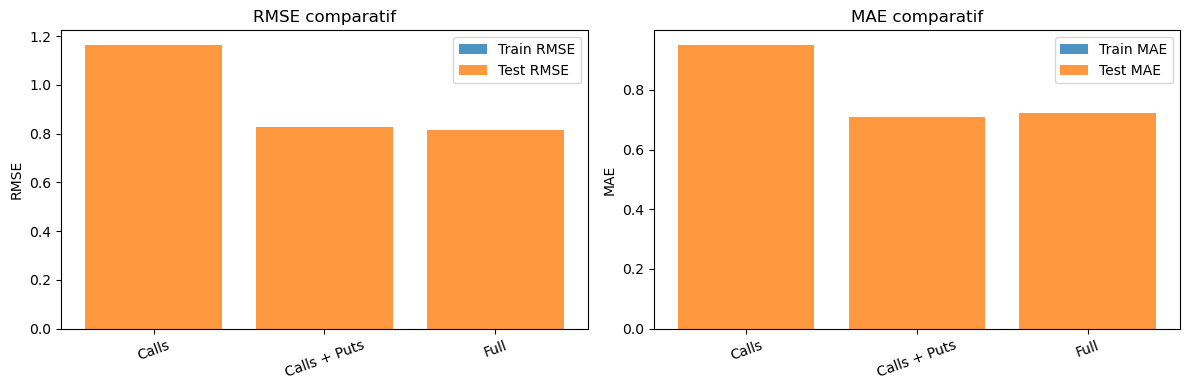

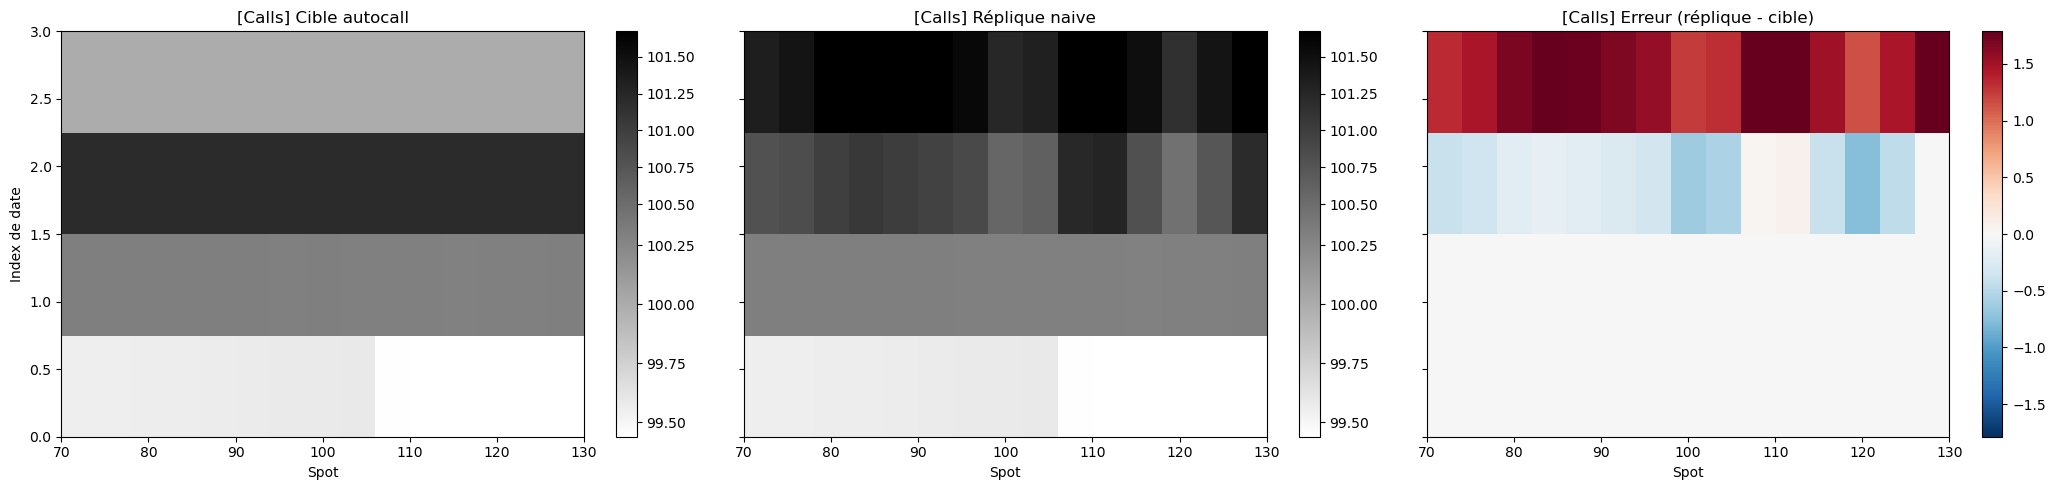

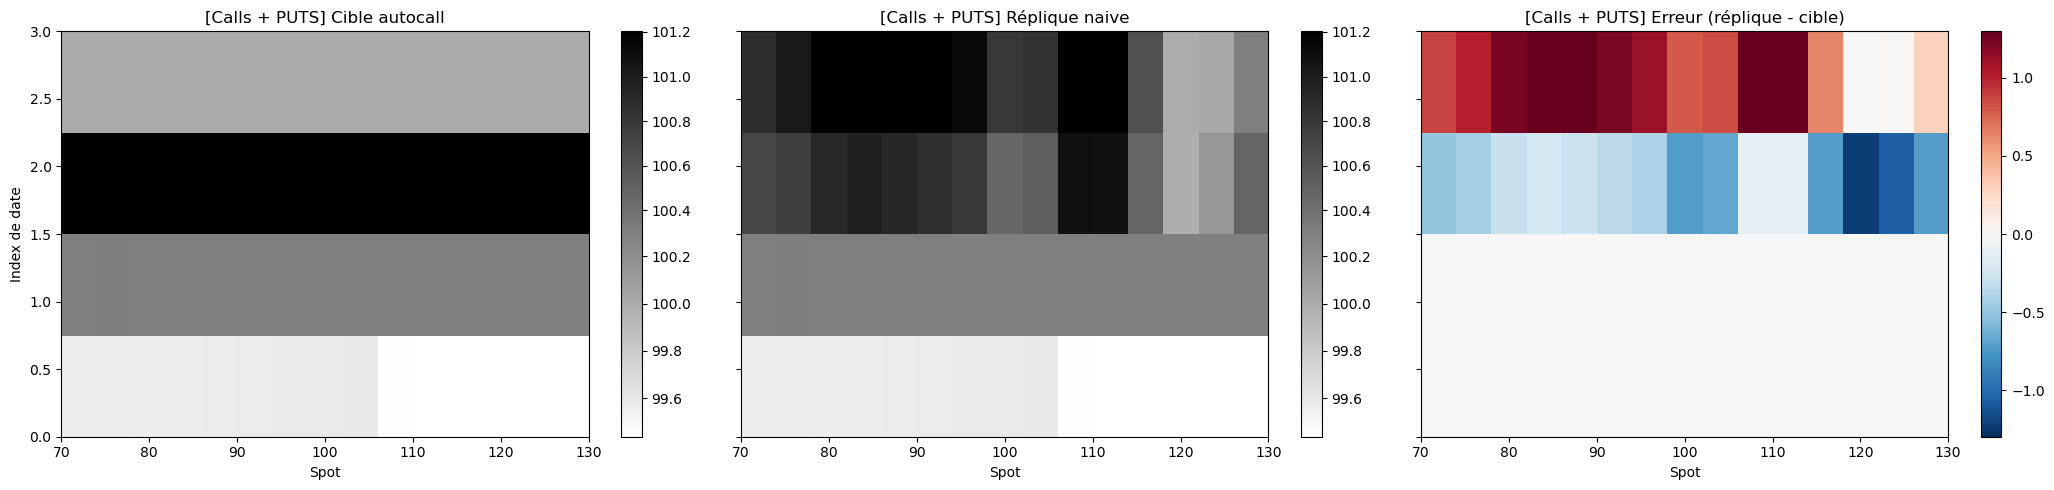

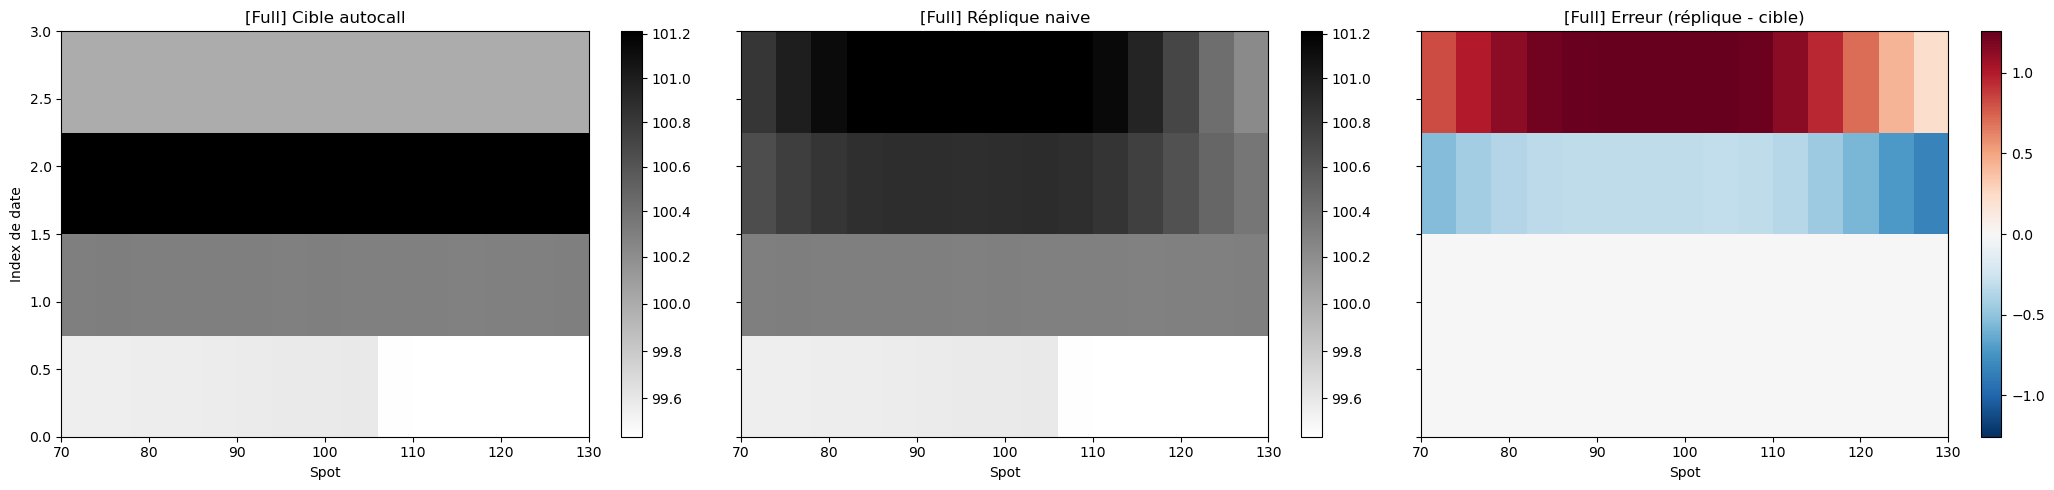

=== CALLS - elastic_net ===
Train: {'mae': 1.0847619099270862e-12, 'rmse': 1.2890636990129834e-12, 'max_abs_error': 2.3874235921539366e-12, 'mean_error': -1.0847619099270862e-12}
Test : {'mae': 0.9520863262899373, 'rmse': 1.1660638553119491, 'max_abs_error': 1.9870915674502498, 'mean_error': 0.639292938852671}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,1.013395
48,C_20261020_110.00,EuropeanCall,2026-10-20,110.0,-0.881019
50,C_20261020_120.00,EuropeanCall,2026-10-20,120.0,0.768765
74,C_20261220_110.00,EuropeanCall,2026-12-20,110.0,0.428665
76,C_20261220_120.00,EuropeanCall,2026-12-20,120.0,-0.398046
49,C_20261020_115.00,EuropeanCall,2026-10-20,115.0,-0.364429
47,C_20261020_105.00,EuropeanCall,2026-10-20,105.0,0.344396
46,C_20261020_100.00,EuropeanCall,2026-10-20,100.0,0.322166
63,C_20261120_120.00,EuropeanCall,2026-11-20,120.0,-0.297384
51,C_20261020_125.00,EuropeanCall,2026-10-20,125.0,0.274503


=== CALLS + PUTS - elastic_net ===
Train: {'mae': 9.000207986294602e-14, 'rmse': 1.1123266067299841e-13, 'max_abs_error': 2.8421709430404007e-13, 'mean_error': 2.936909974475081e-14}
Test : {'mae': 0.7079814225927544, 'rmse': 0.8282592843878516, 'max_abs_error': 1.381130711207959, 'mean_error': 0.18402291341768992}


,name,kind,maturity_date,strike,weight
95,C_20261020_110.00,EuropeanCall,2026-10-20,110.0,-0.449887
96,P_20261020_110.00,EuropeanPut,2026-10-20,110.0,-0.430163
100,P_20261020_120.00,EuropeanPut,2026-10-20,120.0,0.406698
99,C_20261020_120.00,EuropeanCall,2026-10-20,120.0,0.362663
0,CASH_20270620,Cash,2027-06-20,0.0,0.255212
151,C_20261220_120.00,EuropeanCall,2026-12-20,120.0,-0.234411
148,P_20261220_110.00,EuropeanPut,2026-12-20,110.0,0.228426
97,C_20261020_115.00,EuropeanCall,2026-10-20,115.0,-0.198048
147,C_20261220_110.00,EuropeanCall,2026-12-20,110.0,0.195875
125,C_20261120_120.00,EuropeanCall,2026-11-20,120.0,-0.176929


=== FULL - elastic_net ===
Train: {'mae': 2.0084674664152165e-13, 'rmse': 2.5015410247706903e-13, 'max_abs_error': 6.679101716144942e-13, 'mean_error': 1.5252984060983483e-13}
Test : {'mae': 0.7221065105835137, 'rmse': 0.8164686348699798, 'max_abs_error': 1.2659606736494595, 'mean_error': 0.2860178603854616}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,0.254335
1,C_20260720_70.00,EuropeanCall,2026-07-20,70.0,0.080167
53,C_20260820_70.00,EuropeanCall,2026-08-20,70.0,0.080167
105,C_20260920_70.00,EuropeanCall,2026-09-20,70.0,0.080167
102,P_20260820_130.00,EuropeanPut,2026-08-20,130.0,0.060333
50,P_20260720_130.00,EuropeanPut,2026-07-20,130.0,0.060333
154,P_20260920_130.00,EuropeanPut,2026-09-20,130.0,0.060333
309,C_20261220_130.00,EuropeanCall,2026-12-20,130.0,-0.058893
622,P_20270620_130.00,EuropeanPut,2027-06-20,130.0,0.054548
570,P_20270520_130.00,EuropeanPut,2027-05-20,130.0,0.053421


,family,train_mae,train_rmse,train_max_abs_error,train_mean_error,test_mae,test_rmse,test_max_abs_error,test_mean_error
0,calls,1.084762e-12,1.289064e-12,2.387424e-12,-1.084762e-12,0.952086,1.166064,1.987092,0.639293
1,calls_puts,9.000208e-14,1.112327e-13,2.842171e-13,2.936910e-14,0.707981,0.828259,1.381131,0.184023
2,full,2.008467e-13,2.501541e-13,6.679102e-13,1.525298e-13,0.722107,0.816469,1.265961,0.286018


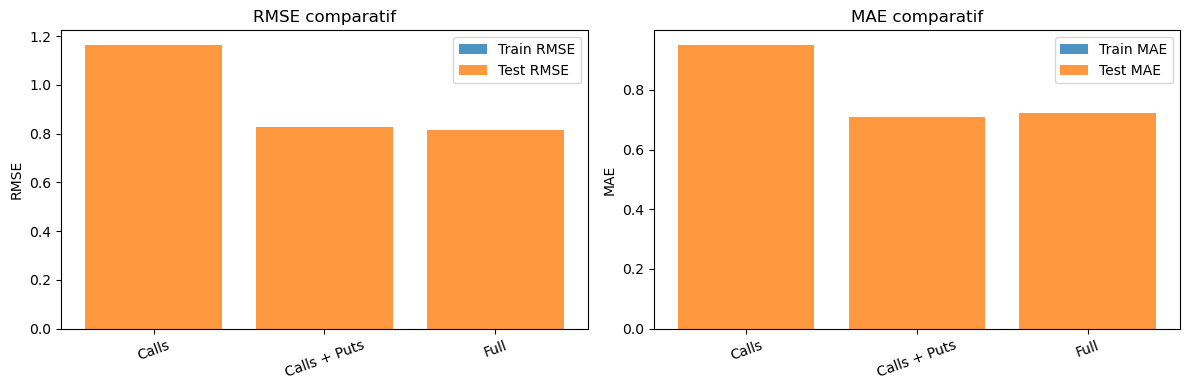

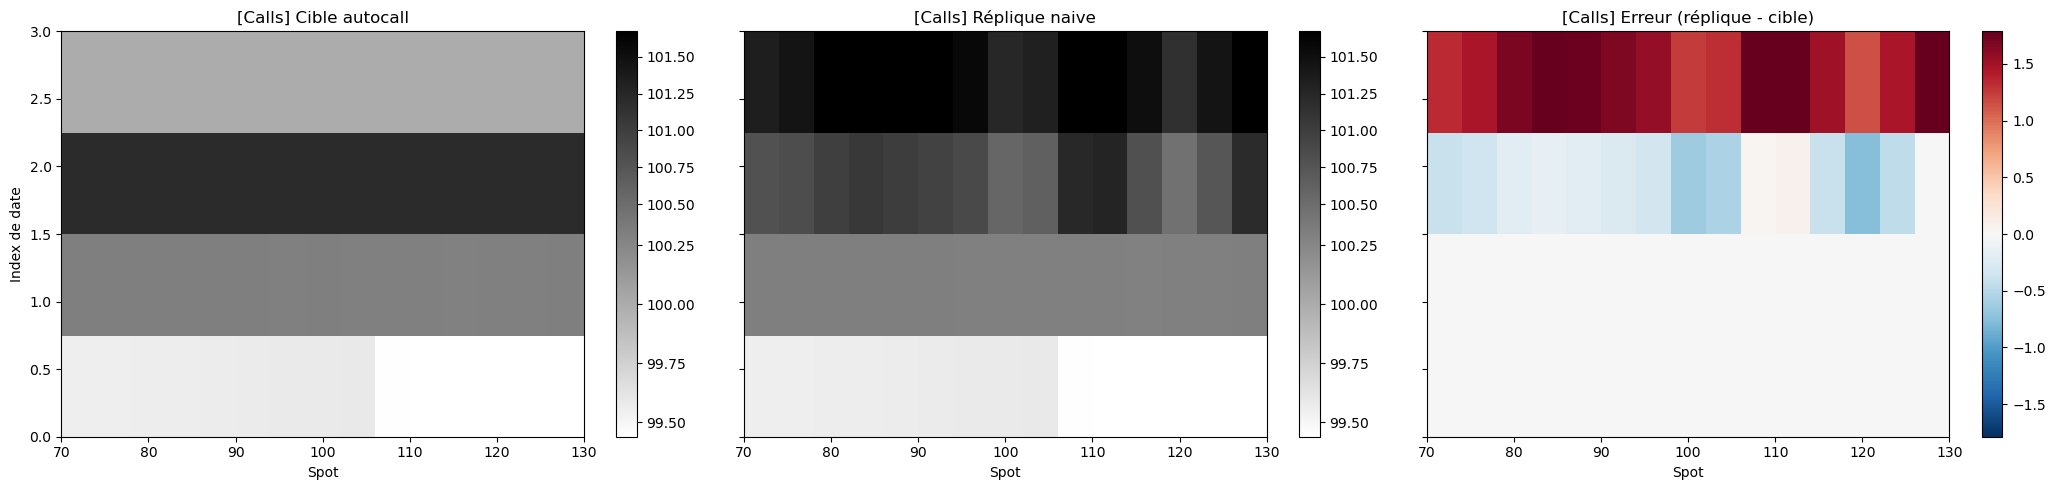

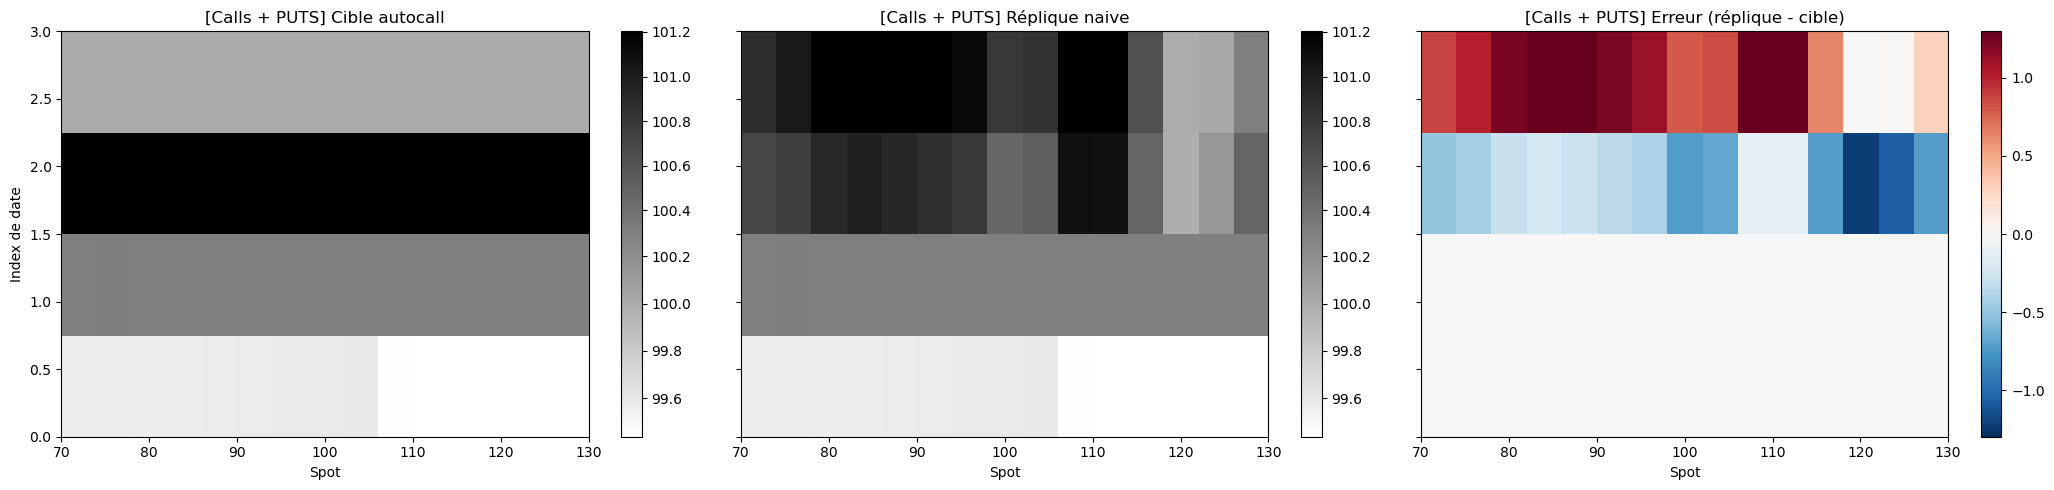

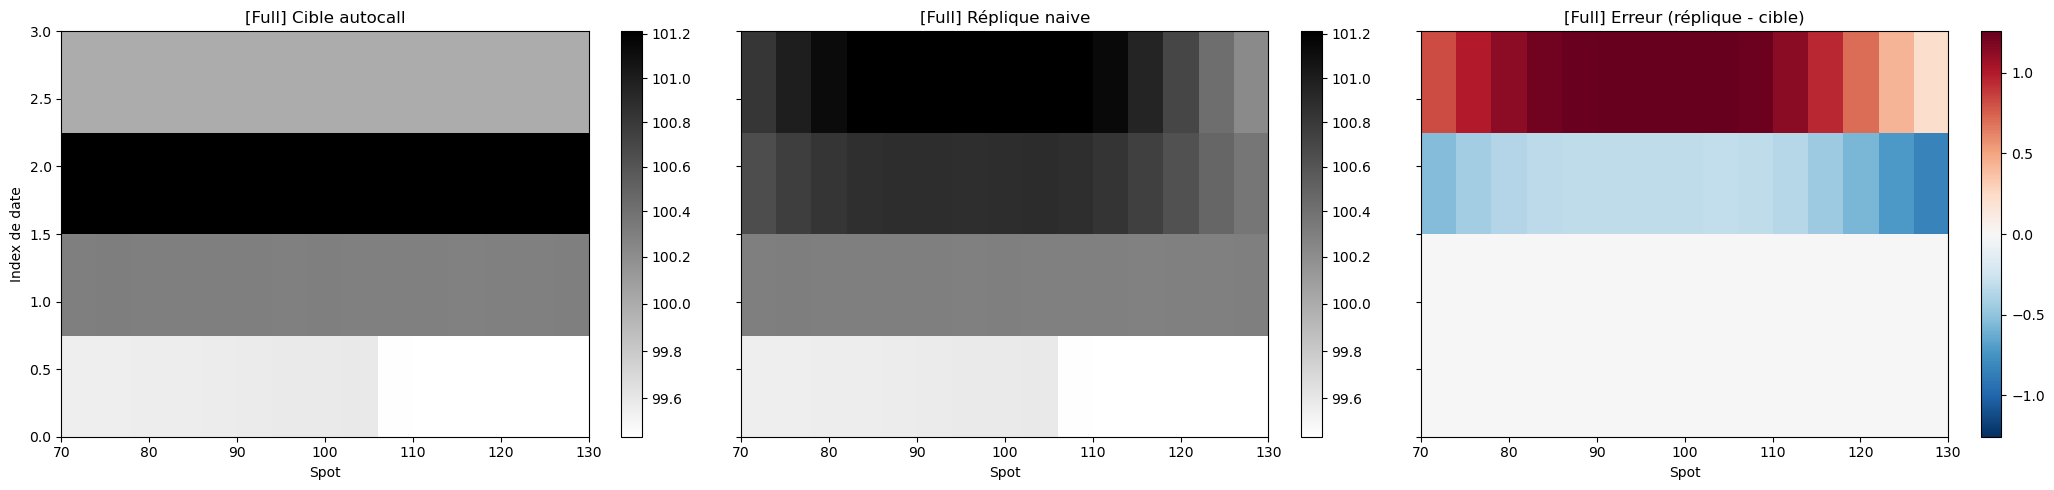

=== CALLS - l1_2 ===
Train: {'mae': 1.0847619099270862e-12, 'rmse': 1.2890636990129834e-12, 'max_abs_error': 2.3874235921539366e-12, 'mean_error': -1.0847619099270862e-12}
Test : {'mae': 0.9520863262899373, 'rmse': 1.1660638553119491, 'max_abs_error': 1.9870915674502498, 'mean_error': 0.639292938852671}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,1.013395
48,C_20261020_110.00,EuropeanCall,2026-10-20,110.0,-0.881019
50,C_20261020_120.00,EuropeanCall,2026-10-20,120.0,0.768765
74,C_20261220_110.00,EuropeanCall,2026-12-20,110.0,0.428665
76,C_20261220_120.00,EuropeanCall,2026-12-20,120.0,-0.398046
49,C_20261020_115.00,EuropeanCall,2026-10-20,115.0,-0.364429
47,C_20261020_105.00,EuropeanCall,2026-10-20,105.0,0.344396
46,C_20261020_100.00,EuropeanCall,2026-10-20,100.0,0.322166
63,C_20261120_120.00,EuropeanCall,2026-11-20,120.0,-0.297384
51,C_20261020_125.00,EuropeanCall,2026-10-20,125.0,0.274503


=== CALLS + PUTS - l1_2 ===
Train: {'mae': 9.000207986294602e-14, 'rmse': 1.1123266067299841e-13, 'max_abs_error': 2.8421709430404007e-13, 'mean_error': 2.936909974475081e-14}
Test : {'mae': 0.7079814225927544, 'rmse': 0.8282592843878516, 'max_abs_error': 1.381130711207959, 'mean_error': 0.18402291341768992}


,name,kind,maturity_date,strike,weight
95,C_20261020_110.00,EuropeanCall,2026-10-20,110.0,-0.449887
96,P_20261020_110.00,EuropeanPut,2026-10-20,110.0,-0.430163
100,P_20261020_120.00,EuropeanPut,2026-10-20,120.0,0.406698
99,C_20261020_120.00,EuropeanCall,2026-10-20,120.0,0.362663
0,CASH_20270620,Cash,2027-06-20,0.0,0.255212
151,C_20261220_120.00,EuropeanCall,2026-12-20,120.0,-0.234411
148,P_20261220_110.00,EuropeanPut,2026-12-20,110.0,0.228426
97,C_20261020_115.00,EuropeanCall,2026-10-20,115.0,-0.198048
147,C_20261220_110.00,EuropeanCall,2026-12-20,110.0,0.195875
125,C_20261120_120.00,EuropeanCall,2026-11-20,120.0,-0.176929


=== FULL - l1_2 ===
Train: {'mae': 2.0084674664152165e-13, 'rmse': 2.5015410247706903e-13, 'max_abs_error': 6.679101716144942e-13, 'mean_error': 1.5252984060983483e-13}
Test : {'mae': 0.7221065105835137, 'rmse': 0.8164686348699798, 'max_abs_error': 1.2659606736494595, 'mean_error': 0.2860178603854616}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,0.254335
1,C_20260720_70.00,EuropeanCall,2026-07-20,70.0,0.080167
53,C_20260820_70.00,EuropeanCall,2026-08-20,70.0,0.080167
105,C_20260920_70.00,EuropeanCall,2026-09-20,70.0,0.080167
102,P_20260820_130.00,EuropeanPut,2026-08-20,130.0,0.060333
50,P_20260720_130.00,EuropeanPut,2026-07-20,130.0,0.060333
154,P_20260920_130.00,EuropeanPut,2026-09-20,130.0,0.060333
309,C_20261220_130.00,EuropeanCall,2026-12-20,130.0,-0.058893
622,P_20270620_130.00,EuropeanPut,2027-06-20,130.0,0.054548
570,P_20270520_130.00,EuropeanPut,2027-05-20,130.0,0.053421


,family,train_mae,train_rmse,train_max_abs_error,train_mean_error,test_mae,test_rmse,test_max_abs_error,test_mean_error
0,calls,1.084762e-12,1.289064e-12,2.387424e-12,-1.084762e-12,0.952086,1.166064,1.987092,0.639293
1,calls_puts,9.000208e-14,1.112327e-13,2.842171e-13,2.936910e-14,0.707981,0.828259,1.381131,0.184023
2,full,2.008467e-13,2.501541e-13,6.679102e-13,1.525298e-13,0.722107,0.816469,1.265961,0.286018


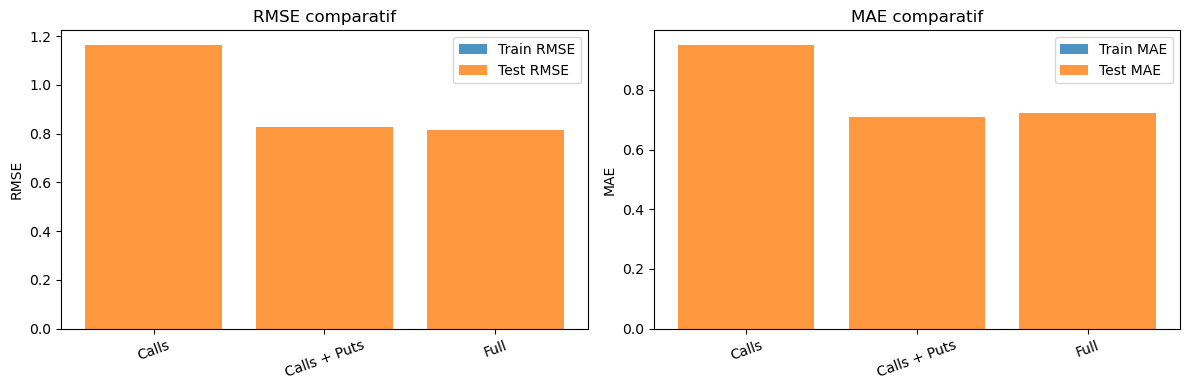

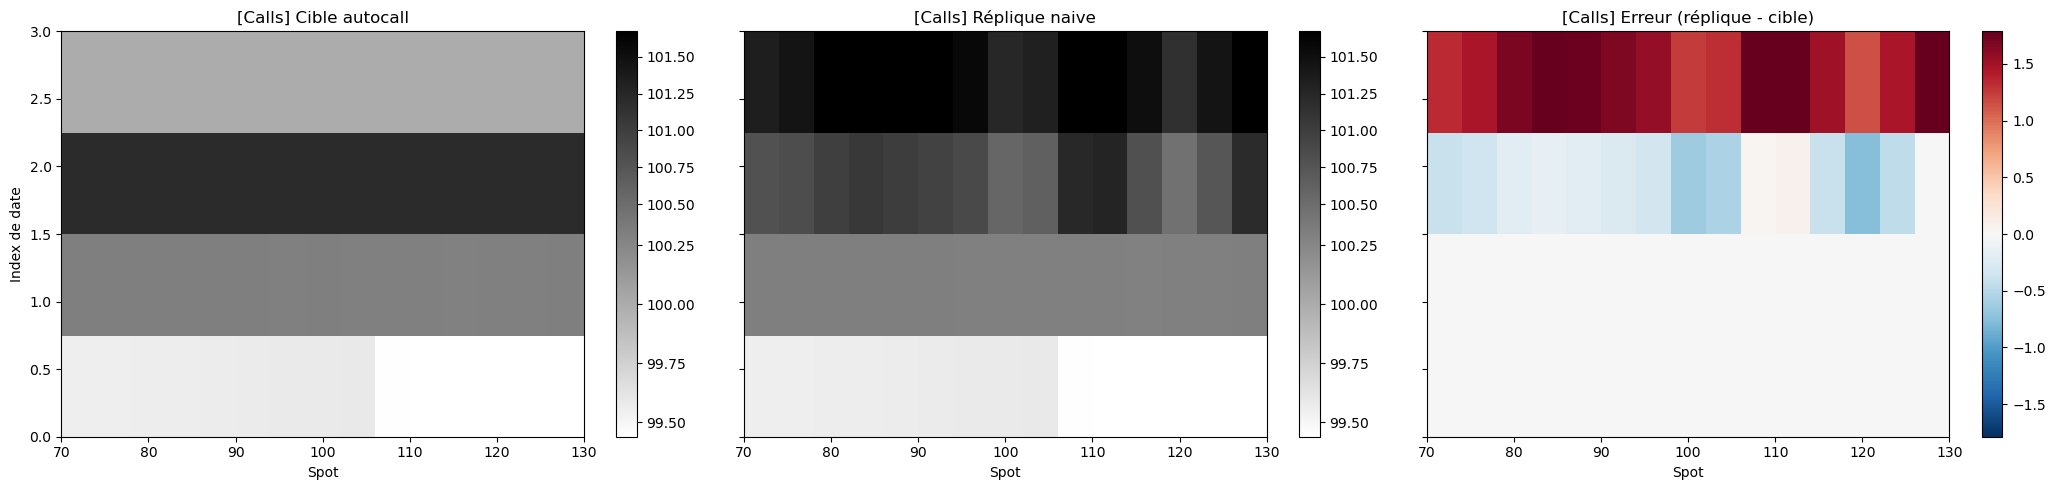

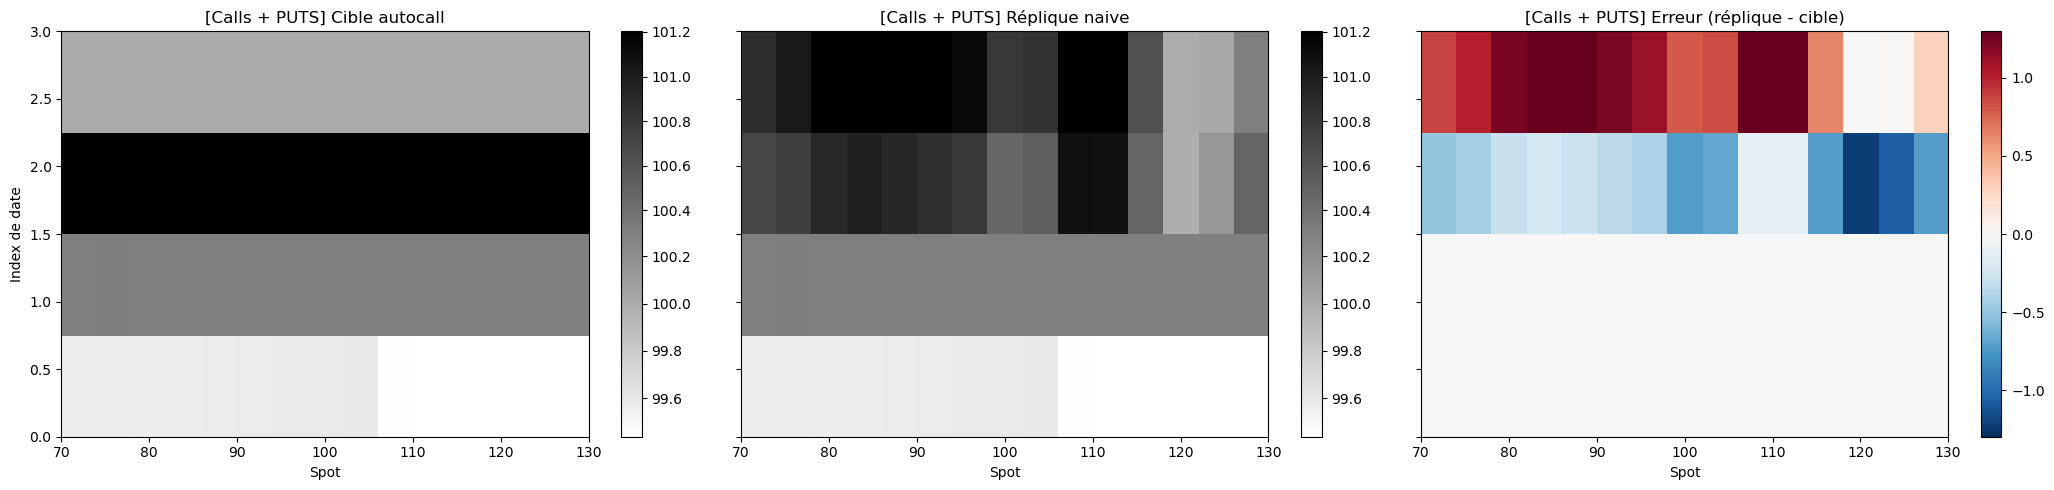

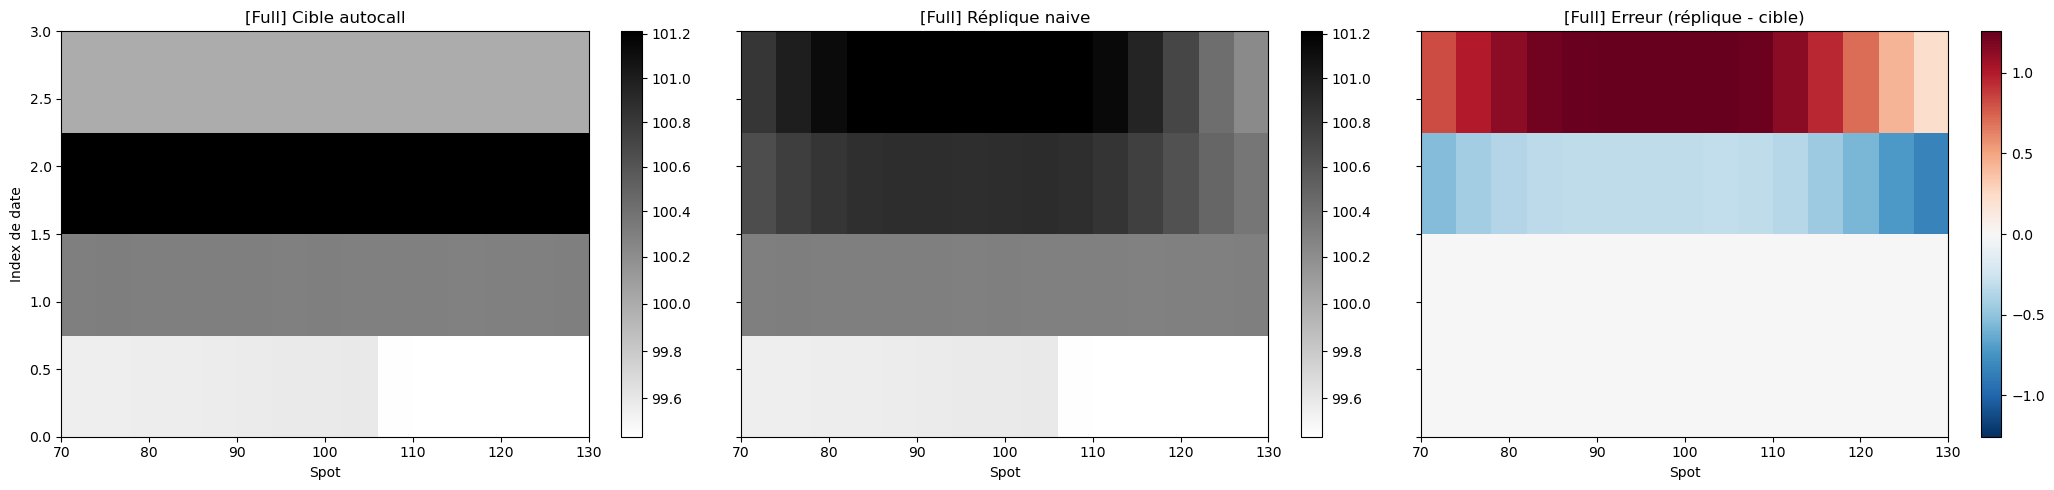

In [51]:
# ============================================================
# EXEMPLES D'UTILISATION
# ============================================================
for penalty in ["l1","l2","huber", "elastic_net", "l1_2"] :
    res_calls =         run_naive_benchmark_price(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls",n_spots=15,n_paths=200, penalty=penalty)
    res_calls_puts =    run_naive_benchmark_price(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls_puts",n_spots=15,n_paths=200, penalty=penalty)
    res_full =          run_naive_benchmark_price(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="full",n_spots=15,n_paths=200, penalty=penalty)

    print(f"=== CALLS - {penalty} ===")
    print("Train:", res_calls["metrics_train"])
    print("Test :", res_calls["metrics_test"])
    display(res_calls["weights"].head(20))

    print(f"=== CALLS + PUTS - {penalty} ===")
    print("Train:", res_calls_puts["metrics_train"])
    print("Test :", res_calls_puts["metrics_test"])
    display(res_calls_puts["weights"].head(20))

    print(f"=== FULL - {penalty} ===")
    print("Train:", res_full["metrics_train"])
    print("Test :", res_full["metrics_test"])
    display(res_full["weights"].head(20))
    

    
    comparative_table = pd.DataFrame([
    {
            "family": "calls",
            "train_mae": res_calls["metrics_train"]["mae"],
            "train_rmse": res_calls["metrics_train"]["rmse"],
            "train_max_abs_error": res_calls["metrics_train"]["max_abs_error"],
            "train_mean_error": res_calls["metrics_train"]["mean_error"],
            "test_mae": res_calls["metrics_test"].get("mae", np.nan),
            "test_rmse": res_calls["metrics_test"].get("rmse", np.nan),
            "test_max_abs_error": res_calls["metrics_test"].get("max_abs_error", np.nan),
            "test_mean_error": res_calls["metrics_test"].get("mean_error", np.nan),
        },
        {
            "family": "calls_puts",
            "train_mae": res_calls_puts["metrics_train"]["mae"],
            "train_rmse": res_calls_puts["metrics_train"]["rmse"],
            "train_max_abs_error": res_calls_puts["metrics_train"]["max_abs_error"],
            "train_mean_error": res_calls_puts["metrics_train"]["mean_error"],
            "test_mae": res_calls_puts["metrics_test"].get("mae", np.nan),
            "test_rmse": res_calls_puts["metrics_test"].get("rmse", np.nan),
            "test_max_abs_error": res_calls_puts["metrics_test"].get("max_abs_error", np.nan),
            "test_mean_error": res_calls_puts["metrics_test"].get("mean_error", np.nan),
        },
        {
            "family": "full",
            "train_mae": res_full["metrics_train"]["mae"],
            "train_rmse": res_full["metrics_train"]["rmse"],
            "train_max_abs_error": res_full["metrics_train"]["max_abs_error"],
            "train_mean_error": res_full["metrics_train"]["mean_error"],
            "test_mae": res_full["metrics_test"].get("mae", np.nan),
            "test_rmse": res_full["metrics_test"].get("rmse", np.nan),
            "test_max_abs_error": res_full["metrics_test"].get("max_abs_error", np.nan),
            "test_mean_error": res_full["metrics_test"].get("mean_error", np.nan),
        },
    ])
    pd.reset_option("display.float_format")
    display(comparative_table)

    metrics_plot = comparative_table.copy()
    metrics_plot["family"] = ["Calls", "Calls + Puts", "Full"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    # Train RMSE / Test RMSE
    axes[0].bar(metrics_plot["family"], metrics_plot["train_rmse"], label="Train RMSE", alpha=0.8)
    axes[0].bar(metrics_plot["family"], metrics_plot["test_rmse"], label="Test RMSE", alpha=0.8)
    axes[0].set_title("RMSE comparatif")
    axes[0].set_ylabel("RMSE")
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].legend()

    # Train MAE / Test MAE
    axes[1].bar(metrics_plot["family"], metrics_plot["train_mae"], label="Train MAE", alpha=0.8)
    axes[1].bar(metrics_plot["family"], metrics_plot["test_mae"], label="Test MAE", alpha=0.8)
    axes[1].set_title("MAE comparatif")
    axes[1].set_ylabel("MAE")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    plot_benchmark_surface(res_calls["dates"],res_calls["spots"],res_calls["target_tensor"],res_calls["fitted_tensor"], title_prefix="[Calls] ")
    plot_benchmark_surface(res_calls_puts["dates"],res_calls_puts["spots"],res_calls_puts["target_tensor"],res_calls_puts["fitted_tensor"], title_prefix="[Calls + PUTS] ")
    plot_benchmark_surface(res_full["dates"],res_full["spots"],res_full["target_tensor"],res_full["fitted_tensor"], title_prefix="[Full] ")

### Pourquoi utiliser `price_bs` ici plutôt que `payoff` ?

Dans cette fonction, on ne cherche pas le payoff d’une vanille à maturité, mais **l’espérance de son payoff brut au point de grille** \((t, S_t)\).

- `payoff(S_T)` donne la valeur finale de l’option **si l’on connaît le spot terminal** \(S_T\).
- `price_bs(...)` donne la **valeur actualisée** aujourd’hui :

$$
\text{price} = e^{-r\tau}\,\mathbb{E}^Q[\text{payoff}]
$$

d’où :

$$
\mathbb{E}^Q[\text{payoff}] = \text{price} \cdot e^{r\tau}
$$

Donc :

- si \(\tau \le 0\), on est à maturité ou après, et on peut utiliser directement `payoff(s)`;
- si \(\tau > 0\), `payoff(s)` ne suffit pas, car il faudrait le **spot terminal** \(S_T\), pas le spot courant \(s\).

C’est pour cela qu’on utilise `price_bs(...)` puis qu’on reconvertit en **espérance brute du payoff** avec `* exp(r * tau)`.  
C’est une façon propre et exacte de construire la matrice de régression pour les vanilles européennes.

In [52]:
# ============================================================
# BENCHMARK PAYOFF : autocall vs portefeuille de vanilles
# ============================================================

import benchmark_mean_payoff
importlib.reload(benchmark_mean_payoff)

# ------------------------------------------------------------
# 0) Helper : moyenne MC du payoff brut d'un autocall
# ------------------------------------------------------------
from benchmark_mean_payoff import mean_undiscounted_payoff_mc

# ------------------------------------------------------------
# 1) Cible : espérance du payoff brut de l'autocall sur une grille
# ------------------------------------------------------------
from benchmark_mean_payoff import autocall_meanpayoff_on_grid_mc

# ------------------------------------------------------------
# 2) Réplique : espérance de payoff brut du portefeuille de vanilles
# ------------------------------------------------------------
from benchmark_mean_payoff import vanilla_basis_expected_payoff_on_grid

# ------------------------------------------------------------
# 3) Pipeline complet : fit sur payoff brut
# ------------------------------------------------------------
from benchmark_mean_payoff import run_naive_benchmark_payoff



=== CALLS ===
Train: {'mae': 1.805133997407893e-05, 'rmse': 3.346370187955921e-05, 'max_abs_error': 9.903470127881064e-05, 'mean_error': -1.8474111129762605e-14}
Test : {'mae': 1.1118665860629653, 'rmse': 1.3531397136891374, 'max_abs_error': 2.6558429247438795, 'mean_error': 0.743260312899794}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,1.016471
48,C_20261020_110.00,EuropeanCall,2026-10-20,110.0,-0.710641
50,C_20261020_120.00,EuropeanCall,2026-10-20,120.0,0.624687
87,C_20270120_110.00,EuropeanCall,2027-01-20,110.0,-0.379267
74,C_20261220_110.00,EuropeanCall,2026-12-20,110.0,0.368666
89,C_20270120_120.00,EuropeanCall,2027-01-20,120.0,0.363121
76,C_20261220_120.00,EuropeanCall,2026-12-20,120.0,-0.341678
47,C_20261020_105.00,EuropeanCall,2026-10-20,105.0,0.290718
49,C_20261020_115.00,EuropeanCall,2026-10-20,115.0,-0.290109
46,C_20261020_100.00,EuropeanCall,2026-10-20,100.0,0.267902


=== CALLS + PUTS ===
Train: {'mae': 9.090459387077015e-06, 'rmse': 1.6860308195036292e-05, 'max_abs_error': 4.9905874035971465e-05, 'mean_error': -9.663381206337362e-14}
Test : {'mae': 1.1344959300156034, 'rmse': 1.4032478044075232, 'max_abs_error': 2.738401467032432, 'mean_error': 0.8095502558708981}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,1.061460
96,P_20261020_110.00,EuropeanPut,2026-10-20,110.0,-0.359457
95,C_20261020_110.00,EuropeanCall,2026-10-20,110.0,-0.355364
99,C_20261020_120.00,EuropeanCall,2026-10-20,120.0,0.317083
100,P_20261020_120.00,EuropeanPut,2026-10-20,120.0,0.312991
173,C_20270120_110.00,EuropeanCall,2027-01-20,110.0,-0.192658
174,P_20270120_110.00,EuropeanPut,2027-01-20,110.0,-0.190400
148,P_20261220_110.00,EuropeanPut,2026-12-20,110.0,0.186299
147,C_20261220_110.00,EuropeanCall,2026-12-20,110.0,0.184065
178,P_20270120_120.00,EuropeanPut,2027-01-20,120.0,0.183260


=== FULL ===
Train: {'mae': 3.240517780038014e-09, 'rmse': 4.7889662363035475e-09, 'max_abs_error': 1.4741203813173342e-08, 'mean_error': 1.1226575225009583e-13}
Test : {'mae': 1.0718287921312106, 'rmse': 1.4077264209469147, 'max_abs_error': 2.071384876377138, 'mean_error': 0.9112572196683644}


,name,kind,maturity_date,strike,weight
0,CASH_20270620,Cash,2027-06-20,0.0,1.062784
261,C_20261220_70.00,EuropeanCall,2026-12-20,70.0,-0.022127
262,P_20261220_70.00,EuropeanPut,2026-12-20,70.0,-0.019787
109,C_20260920_75.00,EuropeanCall,2026-09-20,75.0,0.019047
57,C_20260820_75.00,EuropeanCall,2026-08-20,75.0,0.019047
5,C_20260720_75.00,EuropeanCall,2026-07-20,75.0,0.019047
9,C_20260720_80.00,EuropeanCall,2026-07-20,80.0,0.015584
61,C_20260820_80.00,EuropeanCall,2026-08-20,80.0,0.015584
113,C_20260920_80.00,EuropeanCall,2026-09-20,80.0,0.015584
210,P_20261120_70.00,EuropeanPut,2026-11-20,70.0,-0.015081


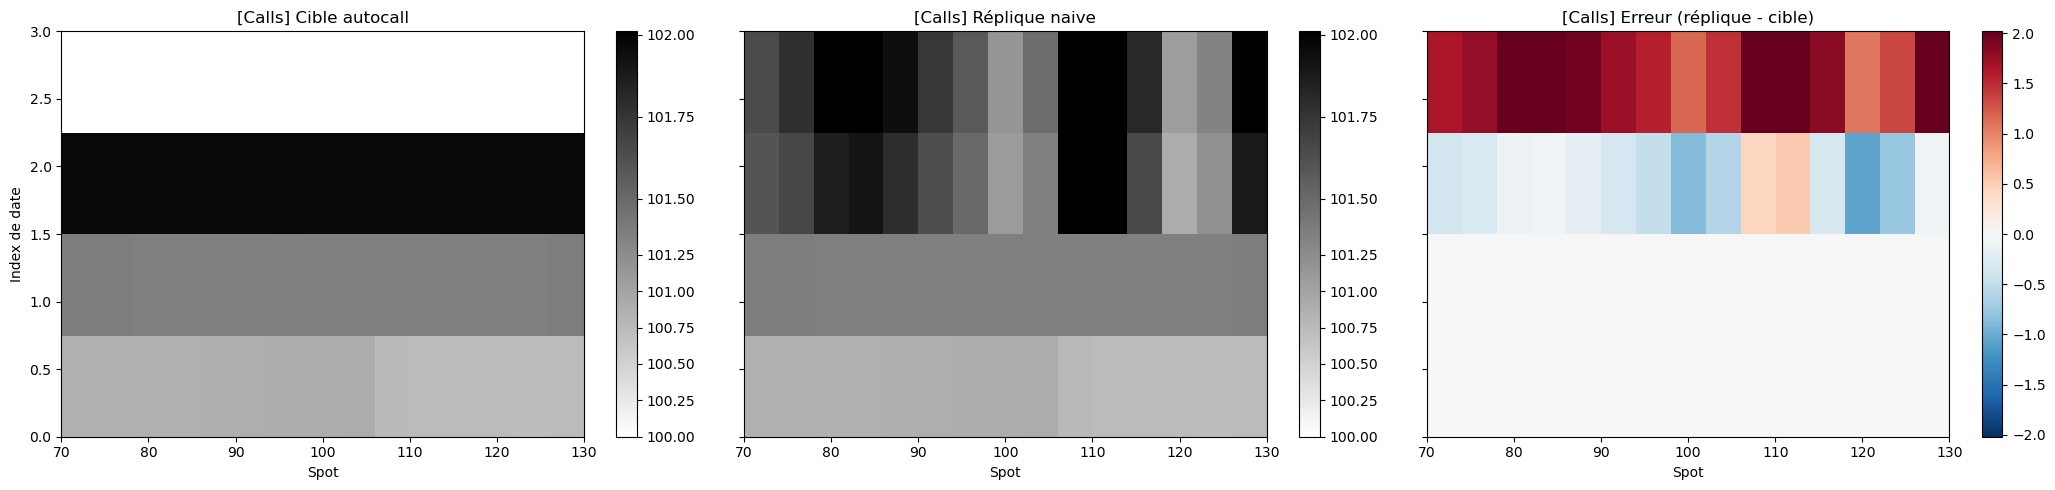

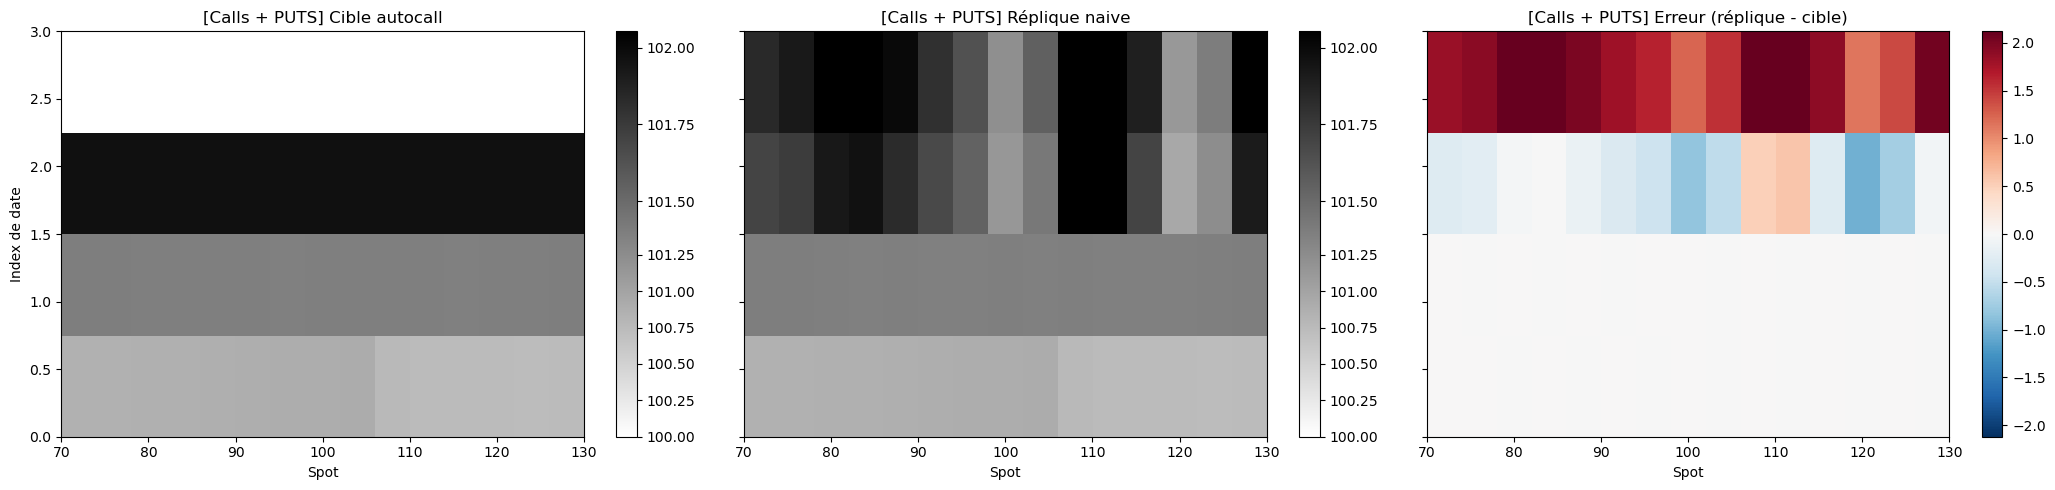

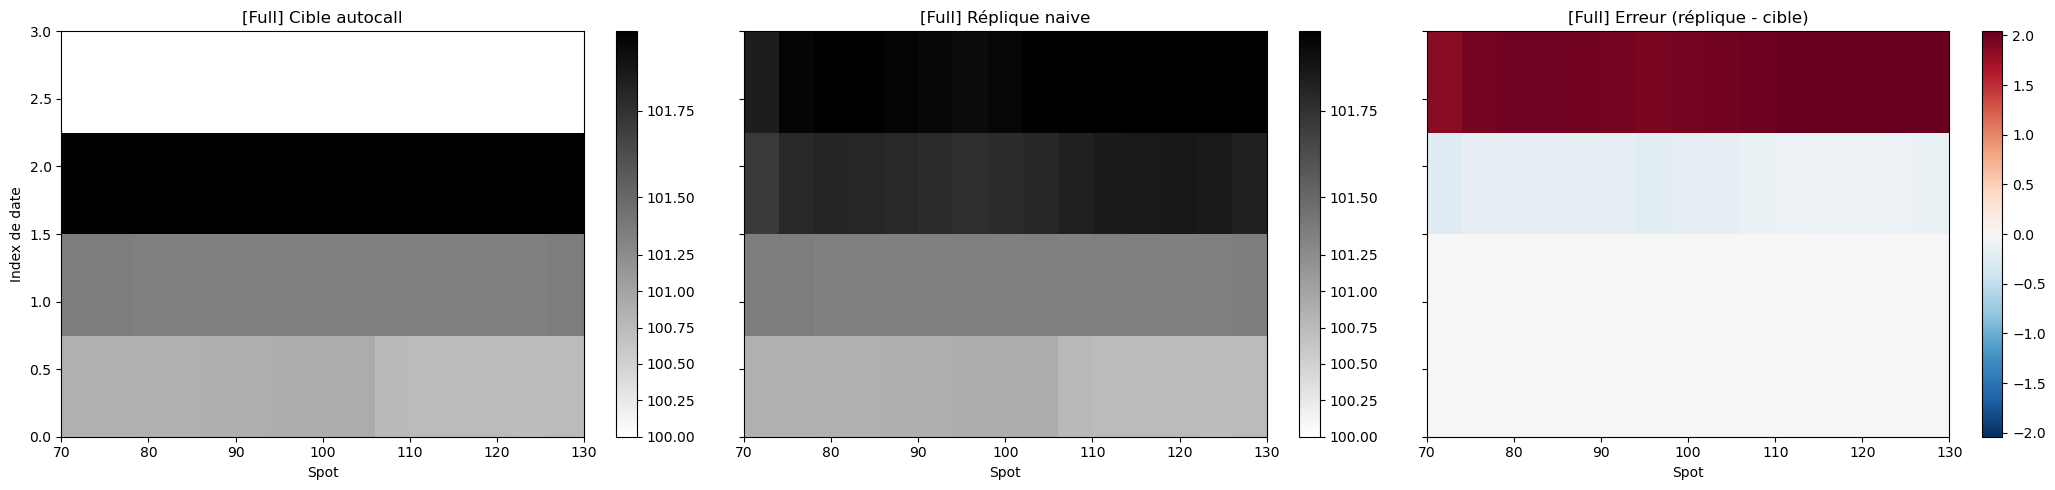

In [53]:
# ------------------------------------------------------------
# 5) Exécution
# ------------------------------------------------------------
res_payoff_calls =      run_naive_benchmark_payoff(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls",n_spots=15,n_paths=200,penalty="l2",alpha=1e-6)
res_payoff_calls_puts = run_naive_benchmark_payoff(product=prod,spot0=spot0,valuation_date=valuation_date, maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls_puts",n_spots= 15,n_paths=200,penalty="l2",alpha=1e-6)
res_payoff_full =       run_naive_benchmark_payoff(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="full",n_spots=15,n_paths=200,penalty="l2",alpha=1e-6)

print("=== CALLS ===")
print("Train:", res_payoff_calls["metrics_train"])
print("Test :", res_payoff_calls["metrics_test"])
display(res_payoff_calls["weights"].head(10))

print("=== CALLS + PUTS ===")
print("Train:", res_payoff_calls_puts["metrics_train"])
print("Test :", res_payoff_calls_puts["metrics_test"])
display(res_payoff_calls_puts["weights"].head(10))

print("=== FULL ===")
print("Train:", res_payoff_full["metrics_train"])
print("Test :", res_payoff_full["metrics_test"])
display(res_payoff_full["weights"].head(10))

plot_benchmark_surface(res_payoff_calls["dates"],res_payoff_calls["spots"],res_payoff_calls["target_tensor"],res_payoff_calls["fitted_tensor"],title_prefix="[Calls] ")
plot_benchmark_surface(res_payoff_calls_puts["dates"],res_payoff_calls_puts["spots"],res_payoff_calls_puts["target_tensor"],res_payoff_calls_puts["fitted_tensor"],title_prefix="[Calls + PUTS] ")
plot_benchmark_surface(res_payoff_full["dates"],res_payoff_full["spots"],res_payoff_full["target_tensor"],res_payoff_full["fitted_tensor"],title_prefix="[Full] ")

,family,train_mae,train_rmse,train_max_abs_error,train_mean_error,test_mae,test_rmse,test_max_abs_error,test_mean_error
0,calls,1.805134e-05,3.346370e-05,9.903470e-05,-1.847411e-14,1.111867,1.353140,2.655843,0.743260
1,calls_puts,9.090459e-06,1.686031e-05,4.990587e-05,-9.663381e-14,1.134496,1.403248,2.738401,0.809550
2,full,3.240518e-09,4.788966e-09,1.474120e-08,1.122658e-13,1.071829,1.407726,2.071385,0.911257


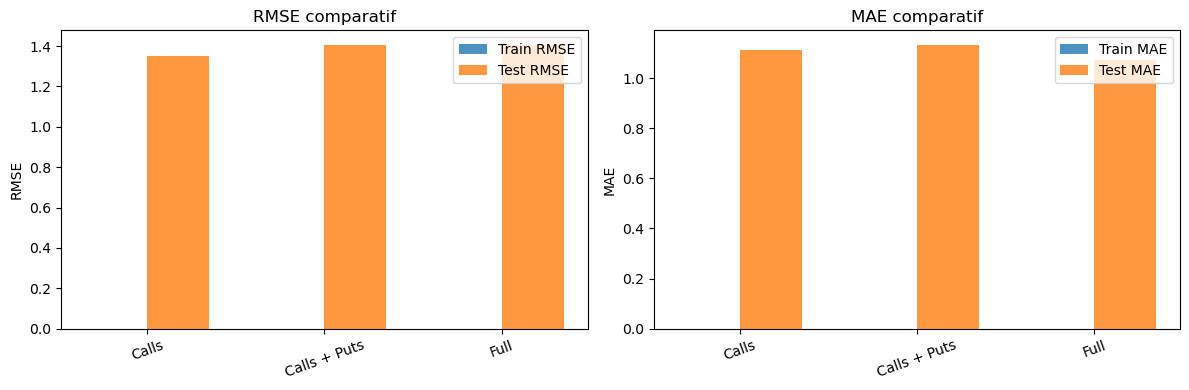

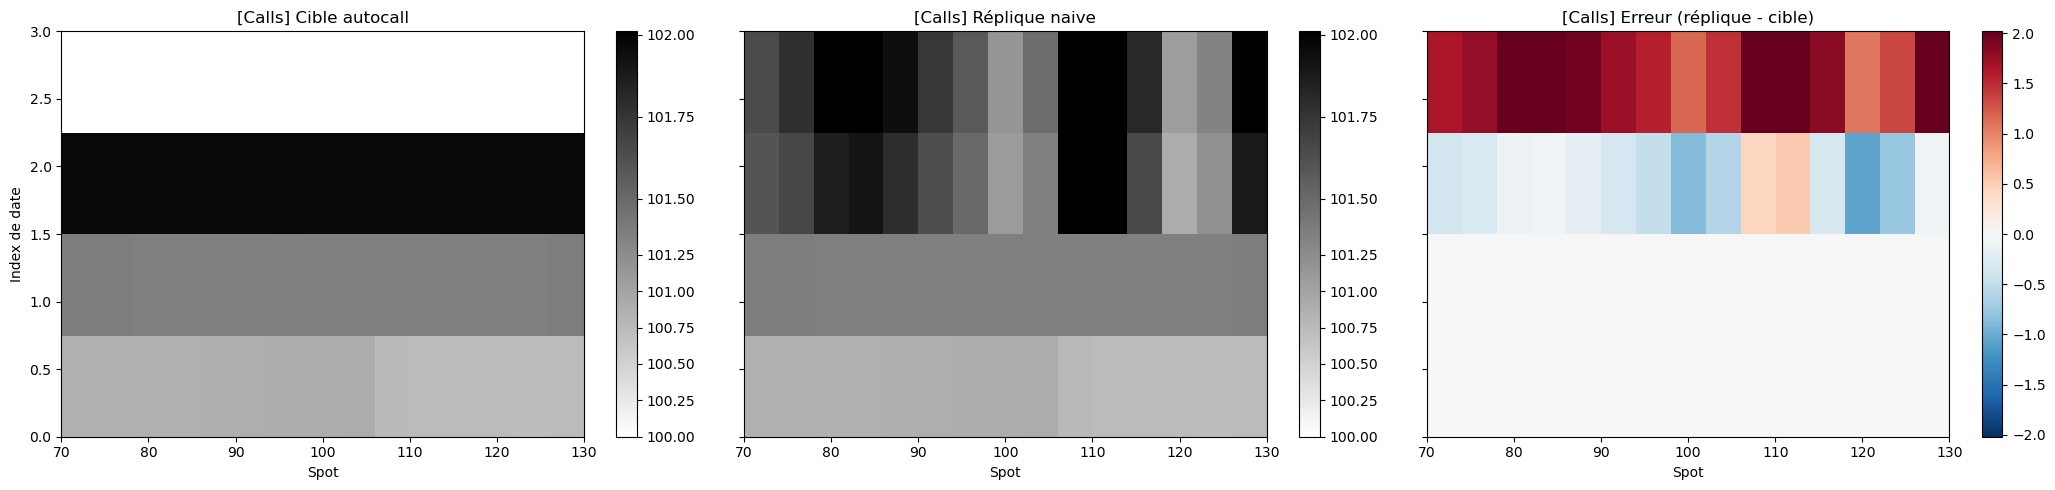

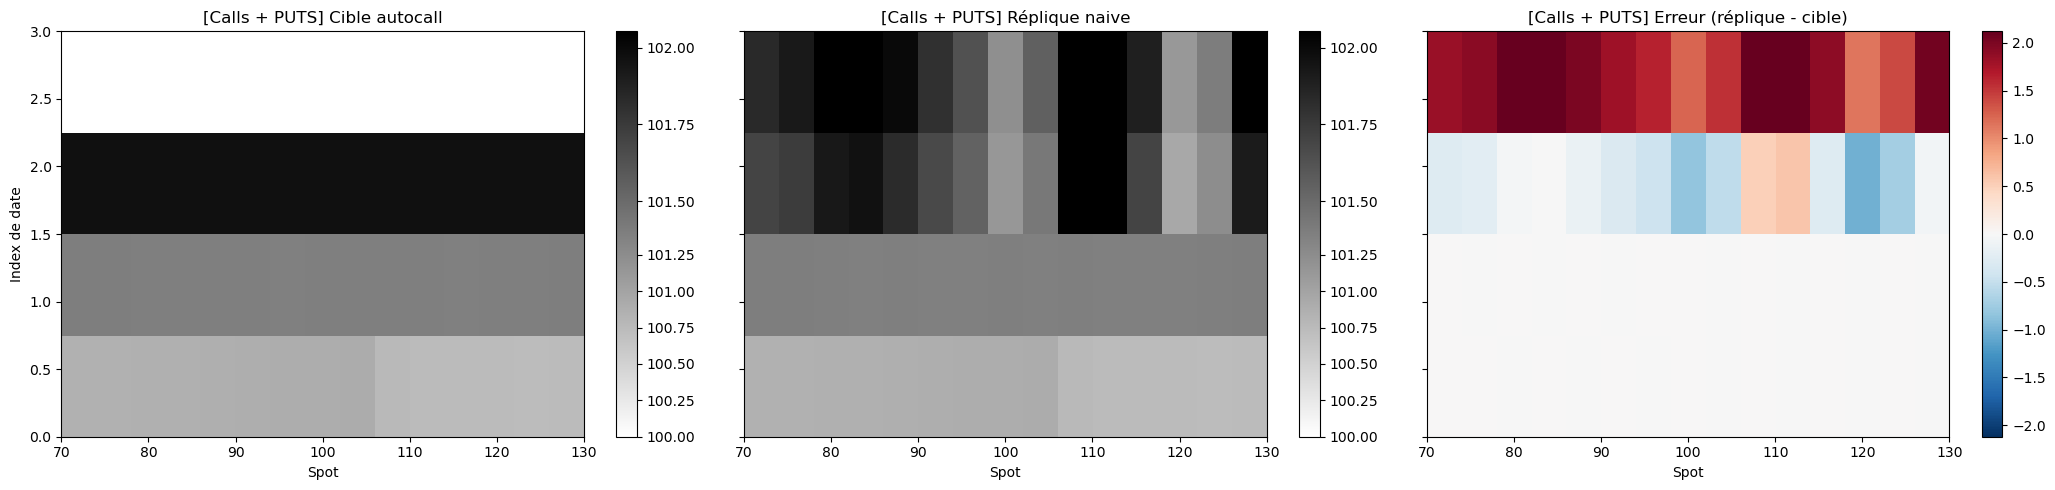

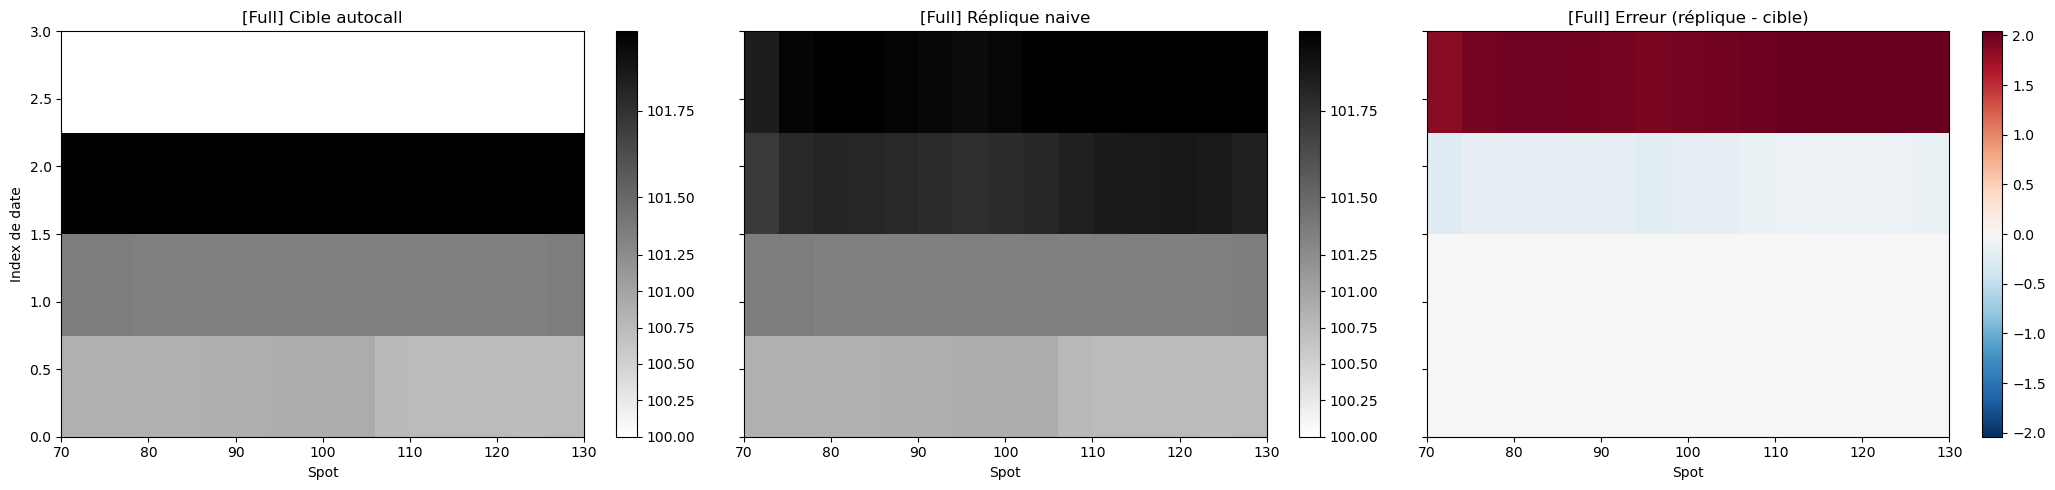

In [54]:
comparative_payoff_table = pd.DataFrame([
    {
        "family": "calls",
        "train_mae": res_payoff_calls["metrics_train"]["mae"],
        "train_rmse": res_payoff_calls["metrics_train"]["rmse"],
        "train_max_abs_error": res_payoff_calls["metrics_train"]["max_abs_error"],
        "train_mean_error": res_payoff_calls["metrics_train"]["mean_error"],
        "test_mae": res_payoff_calls["metrics_test"].get("mae", np.nan),
        "test_rmse": res_payoff_calls["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_payoff_calls["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_payoff_calls["metrics_test"].get("mean_error", np.nan),
    },
    {
        "family": "calls_puts",
        "train_mae": res_payoff_calls_puts["metrics_train"]["mae"],
        "train_rmse": res_payoff_calls_puts["metrics_train"]["rmse"],
        "train_max_abs_error": res_payoff_calls_puts["metrics_train"]["max_abs_error"],
        "train_mean_error": res_payoff_calls_puts["metrics_train"]["mean_error"],
        "test_mae": res_payoff_calls_puts["metrics_test"].get("mae", np.nan),
        "test_rmse": res_payoff_calls_puts["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_payoff_calls_puts["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_payoff_calls_puts["metrics_test"].get("mean_error", np.nan),
    },
    {
        "family": "full",
        "train_mae": res_payoff_full["metrics_train"]["mae"],
        "train_rmse": res_payoff_full["metrics_train"]["rmse"],
        "train_max_abs_error": res_payoff_full["metrics_train"]["max_abs_error"],
        "train_mean_error": res_payoff_full["metrics_train"]["mean_error"],
        "test_mae": res_payoff_full["metrics_test"].get("mae", np.nan),
        "test_rmse": res_payoff_full["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_payoff_full["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_payoff_full["metrics_test"].get("mean_error", np.nan),
    },
])

display(comparative_payoff_table)

metrics_plot = comparative_payoff_table.copy()
metrics_plot["family"] = ["Calls", "Calls + Puts", "Full"]

x = np.arange(len(metrics_plot))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].bar(x - width/2, metrics_plot["train_rmse"], width, label="Train RMSE", alpha=0.8)
axes[0].bar(x + width/2, metrics_plot["test_rmse"], width, label="Test RMSE", alpha=0.8)
axes[0].set_title("RMSE comparatif")
axes[0].set_ylabel("RMSE")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_plot["family"], rotation=20)
axes[0].legend()

axes[1].bar(x - width/2, metrics_plot["train_mae"], width, label="Train MAE", alpha=0.8)
axes[1].bar(x + width/2, metrics_plot["test_mae"], width, label="Test MAE", alpha=0.8)
axes[1].set_title("MAE comparatif")
axes[1].set_ylabel("MAE")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_plot["family"], rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()

plot_benchmark_surface(res_payoff_calls["dates"],res_payoff_calls["spots"],res_payoff_calls["target_tensor"],res_payoff_calls["fitted_tensor"],title_prefix="[Calls] ")
plot_benchmark_surface(res_payoff_calls_puts["dates"],res_payoff_calls_puts["spots"],res_payoff_calls_puts["target_tensor"],res_payoff_calls_puts["fitted_tensor"],title_prefix="[Calls + PUTS] ")
plot_benchmark_surface(res_payoff_full["dates"],res_payoff_full["spots"],res_payoff_full["target_tensor"],res_payoff_full["fitted_tensor"],title_prefix="[Full] ")

In [55]:
# ============================================================
# BENCHMARK PAYOFF PATHWISE : mêmes trajectoires pour tout
# ============================================================

# ------------------------------------------------------------
# 0) Payoff actualisé de l'autocall sur une trajectoire donnée
# ------------------------------------------------------------
from monte_carlo import autocall_discounted_payoff_from_path

# ------------------------------------------------------------
# 1) Payoff actualisé d'une vanille sur une trajectoire donnée
# ------------------------------------------------------------
from benchmark_payoff import vanilla_discounted_payoff_from_path

# ------------------------------------------------------------
# 2) Construction du dataset pathwise
# ------------------------------------------------------------
from benchmark_payoff import build_pathwise_payoff_dataset

# ------------------------------------------------------------
# 3) Pipeline complet : benchmark payoff pathwise
# ------------------------------------------------------------
from benchmark_payoff import run_naive_benchmark_payoff_pathwise

# ------------------------------------------------------------
# 4) Affichage : version lisible et interprétable
# ------------------------------------------------------------
from benchmark_payoff import plot_pathwise_benchmark

Train: {'mae': 1.1541445062293447, 'rmse': 1.8214689077367001, 'max_abs_error': 11.450750208502342, 'mean_error': 7.479984885451683e-13}
Test : {'mae': 5.5731701245525755, 'rmse': 9.841220210266775, 'max_abs_error': 53.376212920383566, 'mean_error': -0.21432669757301165}


,name,kind,maturity_date,strike,weight
27,C_20260920_70.00,EuropeanCall,2026-09-20,70.0,-20.069880
28,C_20260920_75.00,EuropeanCall,2026-09-20,75.0,17.388826
119,C_20270420_75.00,EuropeanCall,2027-04-20,75.0,11.403098
16,C_20260820_80.00,EuropeanCall,2026-08-20,80.0,-10.517757
54,C_20261120_75.00,EuropeanCall,2026-11-20,75.0,10.448557
14,C_20260820_70.00,EuropeanCall,2026-08-20,70.0,9.024259
120,C_20270420_80.00,EuropeanCall,2027-04-20,80.0,-8.998804
40,C_20261020_70.00,EuropeanCall,2026-10-20,70.0,8.452304
41,C_20261020_75.00,EuropeanCall,2026-10-20,75.0,-8.396614
80,C_20270120_75.00,EuropeanCall,2027-01-20,75.0,6.380287


Train: {'mae': 0.8642544550393758, 'rmse': 1.325770146121486, 'max_abs_error': 8.44965374690672, 'mean_error': -1.5106206232996468e-11}
Test : {'mae': 40.20523705690309, 'rmse': 202.24157406476348, 'max_abs_error': 1679.2807533757361, 'mean_error': -4.4332727762269775}


,name,kind,maturity_date,strike,weight
56,P_20260920_75.00,EuropeanPut,2026-09-20,75.0,-509.784828
55,C_20260920_75.00,EuropeanCall,2026-09-20,75.0,-441.656586
32,P_20260820_80.00,EuropeanPut,2026-08-20,80.0,297.173532
80,P_20261020_70.00,EuropeanPut,2026-10-20,70.0,252.065390
31,C_20260820_80.00,EuropeanCall,2026-08-20,80.0,250.751118
79,C_20261020_70.00,EuropeanCall,2026-10-20,70.0,215.831720
132,P_20261220_70.00,EuropeanPut,2026-12-20,70.0,-122.309452
131,C_20261220_70.00,EuropeanCall,2026-12-20,70.0,-105.951401
30,P_20260820_75.00,EuropeanPut,2026-08-20,75.0,98.470633
53,C_20260920_70.00,EuropeanCall,2026-09-20,70.0,68.150189


Train: {'mae': 1.3827618575067478e-06, 'rmse': 1.922114408740157e-06, 'max_abs_error': 7.134716767609461e-06, 'mean_error': 5.030642569181509e-13}
Test : {'mae': 5.465380592041737, 'rmse': 7.991889989970175, 'max_abs_error': 32.766361906816385, 'mean_error': -1.5971825372427153}


,name,kind,maturity_date,strike,weight
474,P_20270420_75.00,EuropeanPut,2027-04-20,75.0,4.894169
473,C_20270420_75.00,EuropeanCall,2027-04-20,75.0,4.838401
328,BP_20270120_85.00,BinaryPut,2027-01-20,85.0,-3.942574
327,BC_20270120_85.00,BinaryCall,2027-01-20,85.0,3.942373
427,BC_20270320_80.00,BinaryCall,2027-03-20,80.0,-3.803911
428,BP_20270320_80.00,BinaryPut,2027-03-20,80.0,3.803838
32,BP_20260720_105.00,BinaryPut,2026-07-20,105.0,-3.304030
31,BC_20260720_105.00,BinaryCall,2026-07-20,105.0,3.303860
528,BP_20270520_75.00,BinaryPut,2027-05-20,75.0,-3.088776
527,BC_20270520_75.00,BinaryCall,2027-05-20,75.0,3.088729


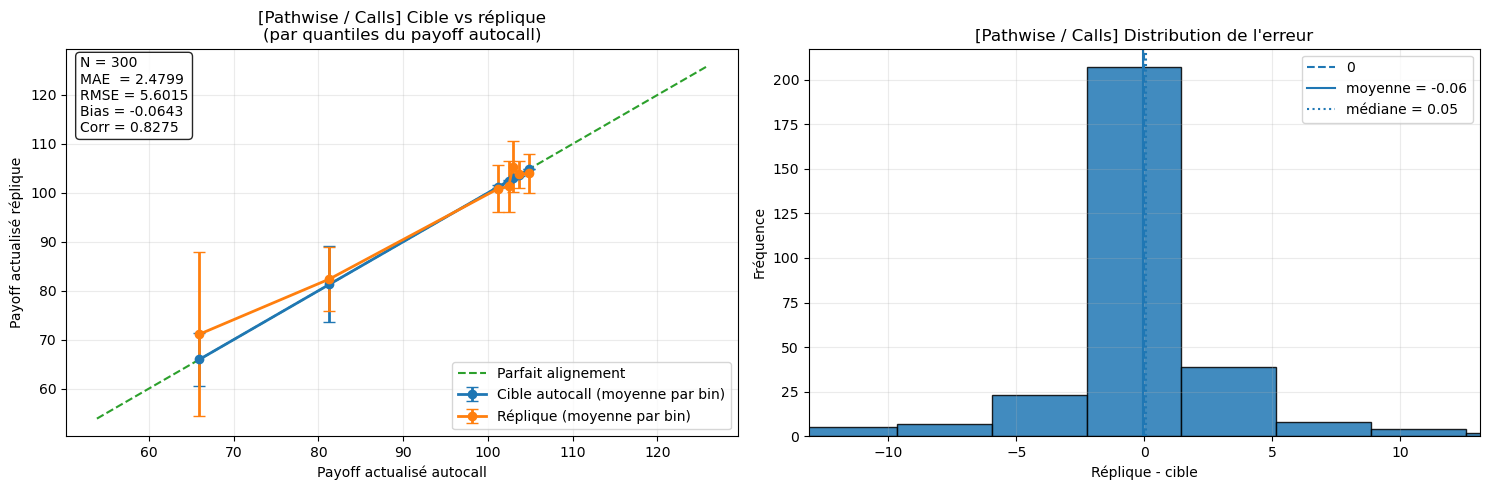

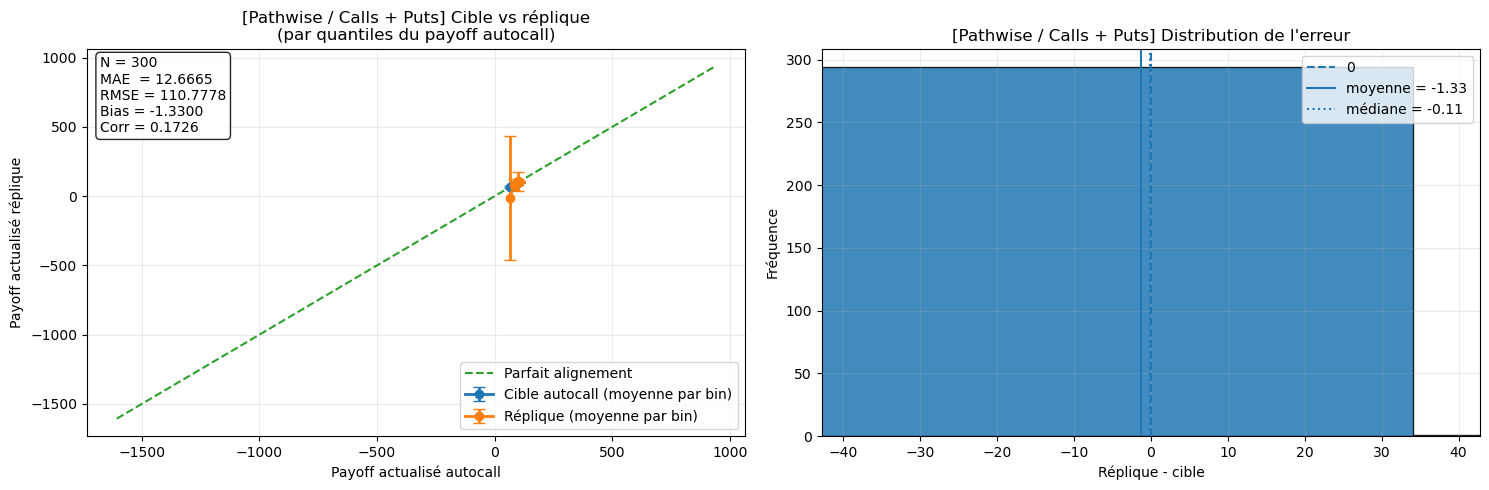

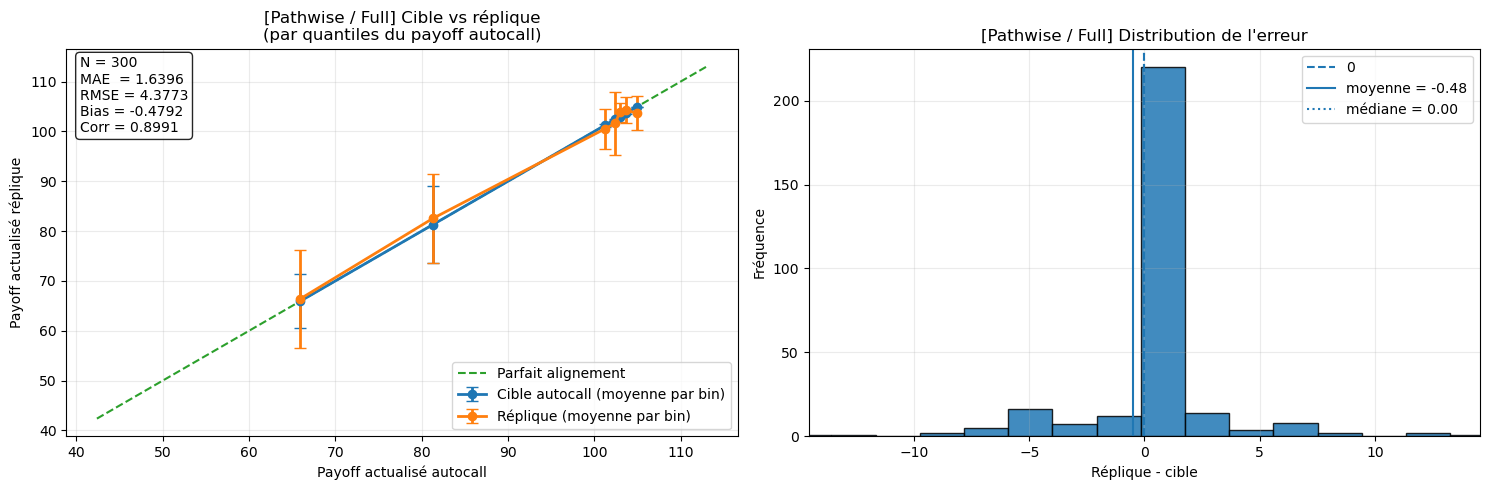

In [56]:
# ------------------------------------------------------------
# 5) Exécution
# ------------------------------------------------------------

res_path_calls = run_naive_benchmark_payoff_pathwise(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls",n_paths=300,penalty="l2",alpha=1e-6)
res_path_calls_puts = run_naive_benchmark_payoff_pathwise(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls_puts",n_paths=300,penalty="l2",alpha=1e-6)
res_path_full = run_naive_benchmark_payoff_pathwise(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="full",n_paths=300,penalty="l2",alpha=1e-6)

print("Train:", res_path_calls["metrics_train"])
print("Test :", res_path_calls["metrics_test"])
display(res_path_calls["weights"].head(10))

print("Train:", res_path_calls_puts["metrics_train"])
print("Test :", res_path_calls_puts["metrics_test"])
display(res_path_calls_puts["weights"].head(10))

print("Train:", res_path_full["metrics_train"])
print("Test :", res_path_full["metrics_test"])
display(res_path_full["weights"].head(10))

plot_pathwise_benchmark(res_path_calls["y"],res_path_calls["replica"],title_prefix="[Pathwise / Calls] ")
plot_pathwise_benchmark(res_path_calls_puts["y"],res_path_calls_puts["replica"],title_prefix="[Pathwise / Calls + Puts] ")
plot_pathwise_benchmark(res_path_full["y"],res_path_full["replica"],title_prefix="[Pathwise / Full] ")


In [ ]:
# ============================================================
# BENCHMARK COURBE PATHWISE :
# cashflows de l'autocall et du réplica le long d'une trajectoire
# ============================================================-

# ------------------------------------------------------------
# Fonction utilitaire :
# date réellement disponible sur le path pour une date contractuelle
# ------------------------------------------------------------
def effective_date_on_path(path: pd.Series,contractual_date: str | pd.Timestamp) -> pd.Timestamp:
    contractual_date = pd.Timestamp(contractual_date)
    position = path.index.searchsorted(contractual_date, side="left")
    if position >= len(path):       raise ValueError(f"La trajectoire ne couvre pas la date {contractual_date}.")
    return pd.Timestamp(path.index[position])

# ------------------------------------------------------------
# 0) Courbe cible :
# cashflows actualisés de l'autocall sur un path
# ------------------------------------------------------------
def autocall_value_curve_on_path(
    product: AutocallProduct,
    path: pd.Series,
    valuation_date: str | pd.Timestamp,
    rate: float, curve_dates=None) -> pd.Series:
    """Retourne les vrais cashflows actualisés de l'autocall sur une trajectoire.
    Chaque date contient uniquement le cashflow payé à cette date.
    Les dates postérieures à un autocall anticipé restent présentes avec un cashflow nul."""
    valuation_date = pd.Timestamp(valuation_date)
    path = path.sort_index().dropna()
    path = path.loc[path.index >= valuation_date]

    if path.empty:      raise ValueError("La trajectoire ne contient aucune date après valuation_date.")

    fixing_date = pd.Timestamp(path.index[0])

    if curve_dates is None:                    # on construit la courbe à partir des dates d'observation du produit, mais on ne garde que celles qui sont couvertes par le path
        contractual_dates = [pd.Timestamp(d) for d in product.build_observation_dates(fixing_date) if pd.Timestamp(d) <= pd.Timestamp(path.index[-1])]
        curve_dates = pd.DatetimeIndex([effective_date_on_path(path=path,contractual_date=d) for d in contractual_dates])
        curve_dates = pd.DatetimeIndex(sorted(set(curve_dates)))
    else:
        curve_dates = pd.DatetimeIndex(curve_dates)

    values = np.zeros(len(curve_dates), dtype=float)
    date_to_index = {pd.Timestamp(d): i for i, d in enumerate(curve_dates)}

    # Cashflows complets du produit sur cette trajectoire
    full_res = product.compute_autocall_payoff(path,start_date=valuation_date)
    cashflows = full_res["cashflows"].copy()
    cashflows["date"] = pd.to_datetime(cashflows["date"])

    # Coupon et remboursement peuvent avoir lieu à la même date.
    # On les additionne dans la même observation temporelle.
    for _, cashflow in cashflows.iterrows():
        cashflow_date = pd.Timestamp(cashflow["date"])

        if cashflow_date not in date_to_index:      raise ValueError(f"Le cashflow autocall du {cashflow_date} ne correspond à aucune date de la courbe.")

        i = date_to_index[cashflow_date]
        tau = _year_fraction(valuation_date, cashflow_date)

        values[i] += (float(cashflow["amount"])* np.exp(-rate * tau))

    return pd.Series(values,index=curve_dates,name="autocall_cashflow")


# ------------------------------------------------------------
# 1) Courbe réplique :
# cashflows actualisés du portefeuille de vanilles sur un path
# ------------------------------------------------------------
def vanilla_portfolio_value_curve_on_path(
    vanillas: list[VanillaProduct],
    weights: np.ndarray,
    path: pd.Series,
    valuation_date: str | pd.Timestamp,
    rate: float,
    curve_dates=None) -> pd.Series:
    """Retourne les vrais cashflows actualisés du portefeuille de vanilles.
    Une vanille contribue uniquement à sa propre date de maturité."""
    valuation_date = pd.Timestamp(valuation_date)
    path = path.sort_index().dropna()
    path = path.loc[path.index >= valuation_date]

    if curve_dates is None:
        curve_dates = pd.DatetimeIndex(
            sorted(set(
                effective_date_on_path(
                    path=path,
                    contractual_date=v.maturity_date)
                for v in vanillas
            ))
        )
    else:
        curve_dates = pd.DatetimeIndex(curve_dates)

    date_to_index = {
        pd.Timestamp(d): i
        for i, d in enumerate(curve_dates)
    }

    values = np.zeros(len(curve_dates), dtype=float)
    weights = np.asarray(weights, dtype=float).reshape(-1)

    if len(weights) != len(vanillas):
        raise ValueError(
            "Le nombre de poids doit être égal au nombre de vanilles."
        )

    for weight, vanilla in zip(weights, vanillas):
        payment_date = effective_date_on_path(
            path=path,
            contractual_date=vanilla.maturity_date)

        if payment_date not in date_to_index:
            raise ValueError(
                f"La maturité {payment_date} de {vanilla.name} "
                "ne correspond à aucune date de la courbe."
            )

        i = date_to_index[payment_date]

        unit_pv = vanilla_discounted_payoff_from_path(
            vanilla=vanilla,
            path=path,
            valuation_date=valuation_date,
            rate=rate)

        values[i] += float(weight) * float(unit_pv)

    return pd.Series(
        values,
        index=curve_dates,
        name="replica_cashflow")


# ------------------------------------------------------------
# 1.1) Affichage du panier retenu sur un path
# ------------------------------------------------------------
def replication_basket_on_path(
    result,
    path,
    valuation_date,
    rate,
    weight_tol=1e-8):
    """Retourne un DataFrame avec les vanilles, leurs poids et leurs contributions.
    On ne garde que les vanilles avec un poids significatif (> weight_tol)."""
    valuation_date = pd.Timestamp(valuation_date)
    path = path.sort_index().dropna()

    vanillas = result["vanillas"]
    weights = np.asarray(result["w"], dtype=float)

    unit_pv = np.array([
        vanilla_discounted_payoff_from_path(
            vanilla=v,
            path=path,
            valuation_date=valuation_date,
            rate=rate)
        for v in vanillas
    ])

    payment_dates = [
        effective_date_on_path(
            path=path,
            contractual_date=v.maturity_date)
        for v in vanillas
    ]

    basket = pd.DataFrame({
        "name": [v.name for v in vanillas],
        "type": [v.__class__.__name__ for v in vanillas],
        "maturite": [pd.Timestamp(v.maturity_date) for v in vanillas],
        "date_paiement": payment_dates,
        "strike": [float(v.strike) for v in vanillas],
        "quantite": weights,
        "payoff_actualise_unitaire": unit_pv,
        "contribution": weights * unit_pv})

    basket["contribution_absolue"] = basket["contribution"].abs()

    return (
        basket.loc[basket["quantite"].abs() > weight_tol]
        .sort_values("contribution_absolue", ascending=False)
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 2) Dataset pathwise temporel :
#    chaque observation = (path, date de cashflow)
# ------------------------------------------------------------
def build_timewise_curve_dataset(
    product: AutocallProduct, vanillas: list[VanillaProduct],spot0: float,
    valuation_date: str | pd.Timestamp, maturity_date: str | pd.Timestamp,
    rate: float,dividend_yield: float,vol: float,
    n_paths: int = 2000,seed: int = 42) -> list[dict[str, object]]:
    """Construit une liste de trajectoires.
    Pour chaque trajectoire, on stocke :
    - le path simulé ;
    - les cashflows actualisés de l'autocall par date ;
    - les payoffs actualisés des vanilles à leurs propres maturités."""
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(maturity_date)

    data = []
    common_dates = None

    for p in range(n_paths):
        seed_p = None if seed is None else seed + p

        path = simulate_gbm_path(spot0=spot0,start_date=valuation_date,end_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,seed=seed_p)
        y_curve = autocall_value_curve_on_path(product=product,path=path,valuation_date=valuation_date,rate=rate,curve_dates=common_dates)

        curve_dates = y_curve.index

        if common_dates is None:                            common_dates = curve_dates
        elif not common_dates.equals(curve_dates):          raise ValueError("Les dates de cashflows diffèrent entre les trajectoires.")

        X_curve = np.zeros((len(curve_dates), len(vanillas)),dtype=float)
        date_to_index = {pd.Timestamp(d): i for i, d in enumerate(curve_dates)}

        # Chaque vanille contribue uniquement à sa propre maturité.
        for j, vanilla in enumerate(vanillas):
            payment_date = effective_date_on_path(path=path,contractual_date=vanilla.maturity_date)
            if payment_date not in date_to_index:           raise ValueError(f"La maturité {payment_date} de {vanilla.name} ne correspond à aucune date d'observation.")

            i = date_to_index[payment_date]
            X_curve[i, j] = vanilla_discounted_payoff_from_path(vanilla=vanilla,path=path,valuation_date=valuation_date,rate=rate)

        data.append({
            "path": path,
            "dates": curve_dates,
            "X_curve": X_curve,
            "y_curve": y_curve.to_numpy(dtype=float)})

    return data


# ------------------------------------------------------------
# 3) Pipeline complet : fit sur les cashflows pathwise temporels
# ------------------------------------------------------------
def run_naive_benchmark_curve(
    product: AutocallProduct, spot0: float,
    valuation_date: str | pd.Timestamp, maturity_date: str | pd.Timestamp,
    rate: float, dividend_yield: float, vol: float,
    family: str,
    n_paths: int = 2000,
    spot_min_mult: float = 0.70, spot_max_mult: float = 1.30,
    penalty: str = "l2",alpha: float = 1e-6,
    train_frac: float = 0.7,seed: int = 42) -> dict[str, object]:
    """Réplique les cashflows d'un autocall avec un panier fixe de vanilles.
    On apprend les poids sur des observations (path, date de cashflow) puis on teste ces mêmes poids sur des trajectoires jamais utilisées."""
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(maturity_date)

    # Construction de la base actuelle.
    vanilla_basis = build_naive_vanilla_basis(spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,product=product,strike_step=5.0,strike_min_mult=spot_min_mult,strike_max_mult=spot_max_mult,family=family)

    # On conserve uniquement les dates auxquelles l'autocall peut payer.
    observation_dates = sorted(set([pd.Timestamp(d) for d in product.build_observation_dates(valuation_date) if valuation_date < pd.Timestamp(d) <= maturity_date] + [maturity_date]))
    vanillas = [v for v in vanilla_basis if (isinstance(v, Cash) or pd.Timestamp(v.maturity_date) in observation_dates)]
    if len(vanillas) == 0:          raise ValueError("La base de réplication ne contient aucune vanille.")

    dataset = build_timewise_curve_dataset(product=product,vanillas=vanillas,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,n_paths=n_paths,seed=seed)
    split = int(train_frac * n_paths)
    split = max(1,min(split,n_paths - 1 if n_paths > 1 else 1))
    train_set = dataset[:split]
    test_set = dataset[split:]

    # Flatten train
    X_train = np.vstack([d["X_curve"] for d in train_set])              # X_train = 
    y_train = np.concatenate([d["y_curve"] for d in train_set])         # y_train représente les cashflows actualisés de l'autocall sur toutes les trajectoires et toutes les dates de cashflow.

    # Flatten test
    if len(test_set) > 0:
        X_test = np.vstack([d["X_curve"] for d in test_set])
        y_test = np.concatenate([d["y_curve"] for d in test_set])
    else:
        X_test = np.empty((0, len(vanillas)))
        y_test = np.empty((0,))

    ###################################################################
    # Normaliser avant d'appliquer la régression linéaire pour éviter que les colonnes avec des valeurs très grandes dominent le fit.
    ###################################################################
    column_scale = np.sqrt(np.mean(X_train**2, axis=0))
    # Colonnes toujours nulles.
    column_scale[column_scale < 1e-12] = 1.0
    # On conserve la convention particulière du cash.
    column_scale[0] = 1.0

    X_train_scaled = X_train / column_scale

    scaled_weights = fit_linear(X_train_scaled,y_train,penalty=penalty,alpha=alpha)

    w = scaled_weights / column_scale

    pred_train = X_train @ w
    pred_test = X_test @ w

    metrics_train = benchmark_metrics(y_train,pred_train)
    metrics_test = (benchmark_metrics(y_test, pred_test) if len(X_test) > 0 else {})
    metrics_by_date = []
    if len(test_set) > 0:
        dates = dataset[0]["dates"]
        for i, d in enumerate(dates):
            y_date = np.array([path_data["y_curve"][i] for path_data in test_set])
            pred_date = np.array([path_data["X_curve"][i] @ w for path_data in test_set])
            metrics_by_date.append({
                "date": pd.Timestamp(d),
                **benchmark_metrics(y_date, pred_date)})
    metrics_by_date = pd.DataFrame(metrics_by_date)

    weights = pd.DataFrame({
        "name": [v.name for v in vanillas],
        "kind": [v.__class__.__name__ for v in vanillas],
        "maturity_date": [
            pd.Timestamp(v.maturity_date)
            for v in vanillas
        ],
        "strike": [float(v.strike) for v in vanillas],
        "weight": w}).sort_values("weight",key=lambda s: s.abs(),ascending=False)

    return {
        "vanillas": vanillas,
        "weights": weights,
        "w": w,
        "dates": dataset[0]["dates"],
        "train_set": train_set,
        "test_set": test_set,
        "metrics_train": metrics_train,
        "metrics_test": metrics_test,
        "metrics_by_date": metrics_by_date,
        "family": family,
        "split": split}


# ------------------------------------------------------------
# 4) Plot lisible :
#    cashflows ponctuels et cashflows cumulés
# ------------------------------------------------------------
def plot_timewise_curve_benchmark(
    dates: pd.DatetimeIndex,
    target_curve: np.ndarray,
    replica_curve: np.ndarray,
    title_prefix: str = ""):
    """Affiche :
    - les vrais cashflows par date ;
    - les cashflows cumulés ;
    - l'erreur de réplication par date."""
    dates = pd.to_datetime(dates)
    target_curve = np.asarray(
        target_curve,
        dtype=float).reshape(-1)

    replica_curve = np.asarray(
        replica_curve,
        dtype=float).reshape(-1)

    if len(dates) != len(target_curve):
        raise ValueError(
            "dates et target_curve doivent avoir la même longueur."
        )

    if len(target_curve) != len(replica_curve):
        raise ValueError(
            "target_curve et replica_curve doivent avoir la même longueur."
        )

    err = replica_curve - target_curve
    x = np.arange(len(dates))
    width = 0.35

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(14, 10),
        sharex=True)

    axes[0].bar(
        x - width / 2,
        target_curve,
        width=width,
        label="Cashflows autocall",
        alpha=0.80)

    axes[0].bar(
        x + width / 2,
        replica_curve,
        width=width,
        label="Cashflows réplique",
        alpha=0.80)

    axes[0].set_title(
        f"{title_prefix}Cashflows actualisés par date")

    axes[0].set_ylabel("Cashflow actualisé")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].step(
        x,
        np.cumsum(target_curve),
        where="mid",
        label="Autocall cumulé",
        linewidth=2)

    axes[1].step(
        x,
        np.cumsum(replica_curve),
        where="mid",
        label="Réplique cumulée",
        linewidth=2)

    axes[1].set_ylabel("Cashflow cumulé")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    axes[2].bar(
        x,
        err,
        width=0.50,
        label="Erreur")

    axes[2].axhline(
        0.0,
        linestyle="--",
        linewidth=1)

    axes[2].set_ylabel("Réplique - cible")
    axes[2].set_xlabel("Date")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(
        [d.strftime("%Y-%m-%d") for d in dates],
        rotation=30,
        ha="right")

    axes[2].legend()
    axes[2].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

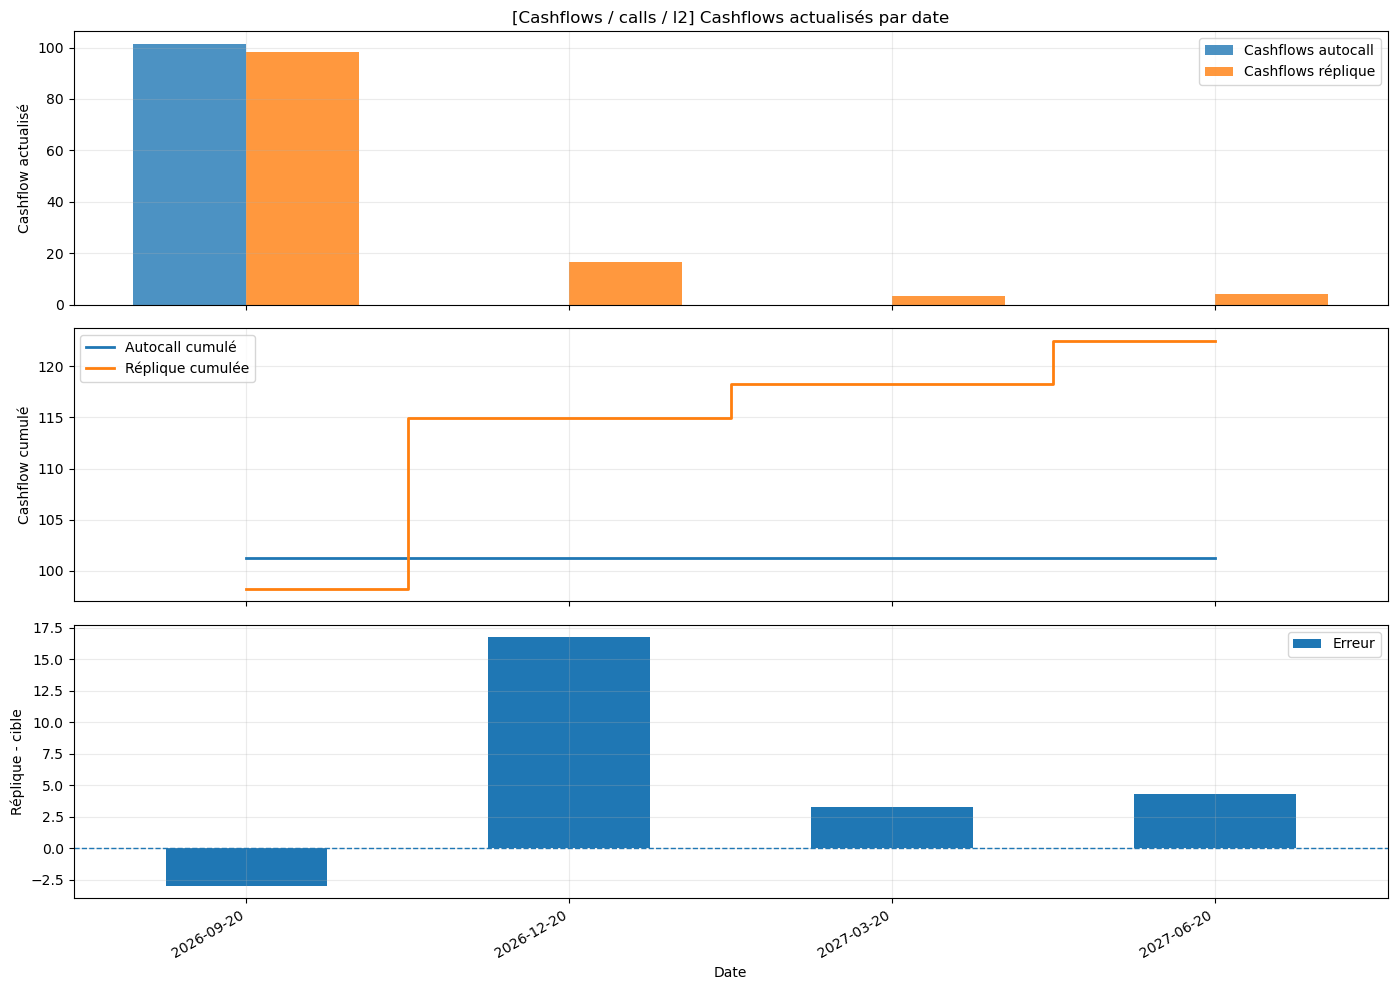

=== CALLS / l2 ===
Métriques train :


mae              15.942237
rmse             26.583697
max_abs_error    98.225640
mean_error       -0.000999
dtype: float64

Métriques test :


mae              17.083726
rmse             28.116501
max_abs_error    97.107555
mean_error       -0.896994
dtype: float64

Métriques test par date :


,date,mae,rmse,max_abs_error,mean_error
0,2026-09-20,9.248778,15.369242,50.823362,-0.449963
1,2026-12-20,18.814605,30.610179,95.557666,-2.271198
2,2027-03-20,13.364942,26.098345,95.044246,-1.028598
3,2027-06-20,26.906581,36.163935,97.107555,0.161784


Panier de réplication :


,name,type,maturite,date_paiement,strike,quantite,payoff_actualise_unitaire,contribution,contribution_absolue
0,C_20270620_75.00,EuropeanCall,2027-06-20,2027-06-20,75.0,-6.711188,42.678810,-286.425508,286.425508
1,C_20260920_95.00,EuropeanCall,2026-09-20,2026-09-20,95.0,17.052848,16.359650,278.978629,278.978629
2,C_20270320_95.00,EuropeanCall,2027-03-20,2027-03-20,95.0,5.667124,28.125342,159.389791,159.389791
3,C_20270620_70.00,EuropeanCall,2027-06-20,2027-06-20,70.0,3.247068,47.531037,154.336502,154.336502
4,C_20270620_80.00,EuropeanCall,2027-06-20,2027-06-20,80.0,3.399892,37.826582,128.606277,128.606277
5,C_20260920_90.00,EuropeanCall,2026-09-20,2026-09-20,90.0,-5.404705,21.321985,-115.239033,115.239033
6,C_20260920_105.00,EuropeanCall,2026-09-20,2026-09-20,105.0,-17.366049,6.434981,-111.750201,111.750201
7,C_20261220_95.00,EuropeanCall,2026-12-20,2026-12-20,95.0,6.463575,14.450811,93.403903,93.403903
8,C_20270620_100.00,EuropeanCall,2027-06-20,2027-06-20,100.0,4.989278,18.417671,91.890874,91.890874
9,C_20270320_105.00,EuropeanCall,2027-03-20,2027-03-20,105.0,-4.450813,18.347227,-81.660068,81.660068


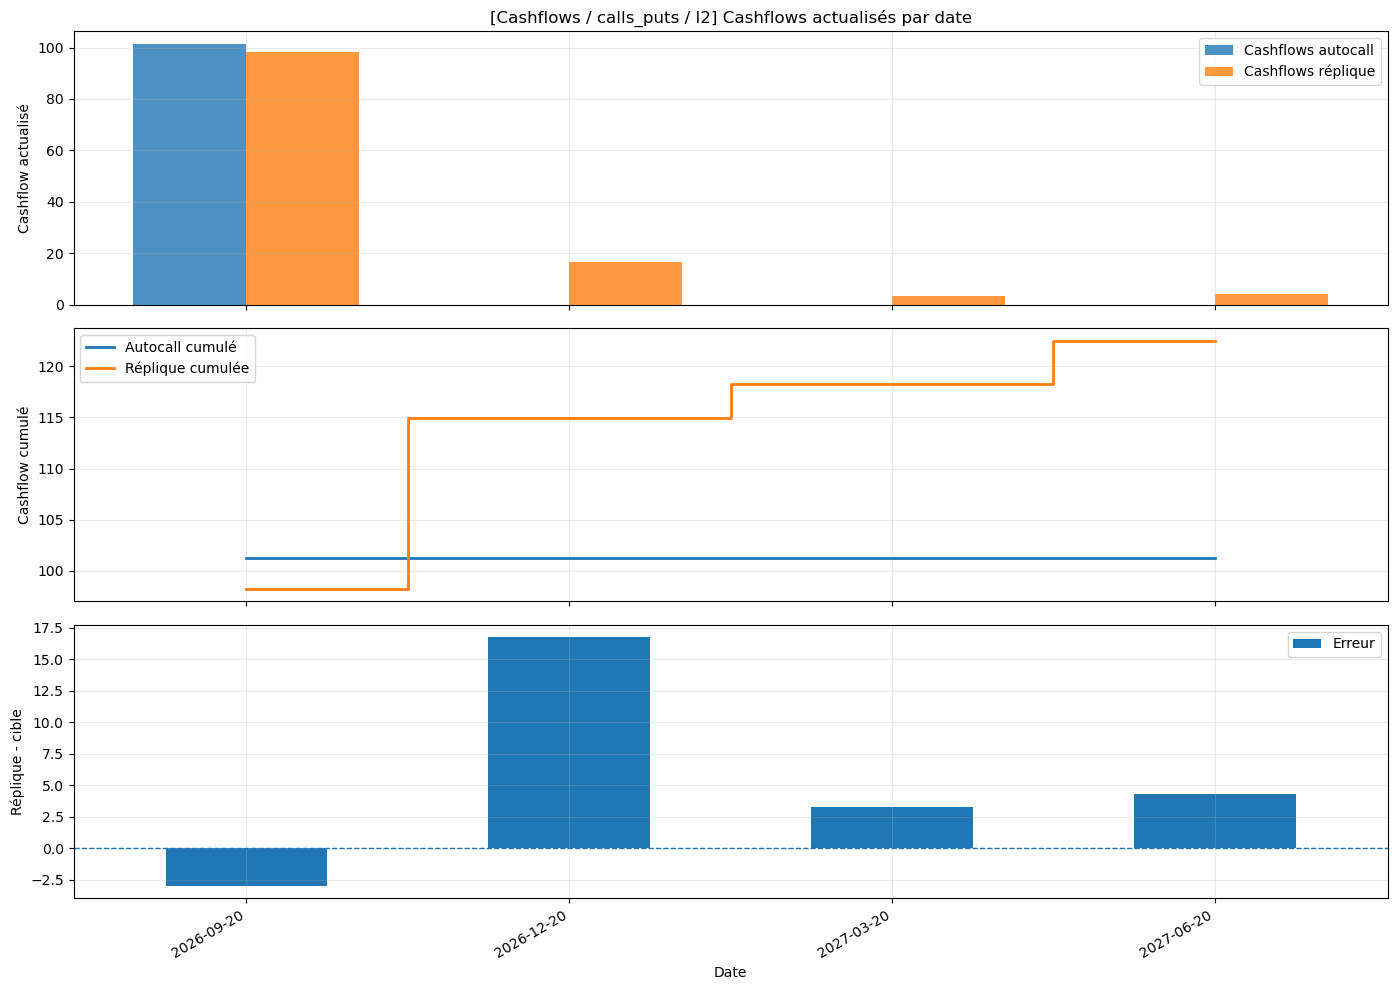

=== CALLS_PUTS / l2 ===
Métriques train :


mae              1.594230e+01
rmse             2.658222e+01
max_abs_error    9.822564e+01
mean_error      -8.537759e-08
dtype: float64

Métriques test :


mae              17.082751
rmse             28.124168
max_abs_error    97.107562
mean_error       -0.884886
dtype: float64

Métriques test par date :


,date,mae,rmse,max_abs_error,mean_error
0,2026-09-20,9.249143,15.369234,50.823171,-0.448474
1,2026-12-20,18.814670,30.610173,95.557667,-2.269820
2,2027-03-20,13.365821,26.098355,95.044249,-1.027546
3,2027-06-20,26.901370,36.187776,97.107562,0.206294


Panier de réplication :


,name,type,maturite,date_paiement,strike,quantite,payoff_actualise_unitaire,contribution,contribution_absolue
0,C_20260920_105.00,EuropeanCall,2026-09-20,2026-09-20,105.0,-11.064174,6.434981,-71.197758,71.197758
1,C_20260920_95.00,EuropeanCall,2026-09-20,2026-09-20,95.0,3.398780,16.359650,55.602857,55.602857
2,C_20270320_105.00,EuropeanCall,2027-03-20,2027-03-20,105.0,-2.202542,18.347227,-40.410537,40.410537
3,C_20270620_105.00,EuropeanCall,2027-06-20,2027-06-20,105.0,-2.223639,13.565444,-30.164646,30.164646
4,C_20261220_105.00,EuropeanCall,2026-12-20,2026-12-20,105.0,-6.455502,4.600096,-29.695929,29.695929
5,C_20270320_95.00,EuropeanCall,2027-03-20,2027-03-20,95.0,1.027175,28.125342,28.889647,28.889647
6,C_20270620_100.00,EuropeanCall,2027-06-20,2027-06-20,100.0,1.320378,18.417671,24.318283,24.318283
7,C_20260920_85.00,EuropeanCall,2026-09-20,2026-09-20,85.0,0.754107,26.284319,19.821193,19.821193
8,C_20270320_100.00,EuropeanCall,2027-03-20,2027-03-20,100.0,-0.843346,23.236284,-19.596216,19.596216
9,CASH_20270620,Cash,2027-06-20,2027-06-20,0.0,0.199689,97.044553,19.378738,19.378738


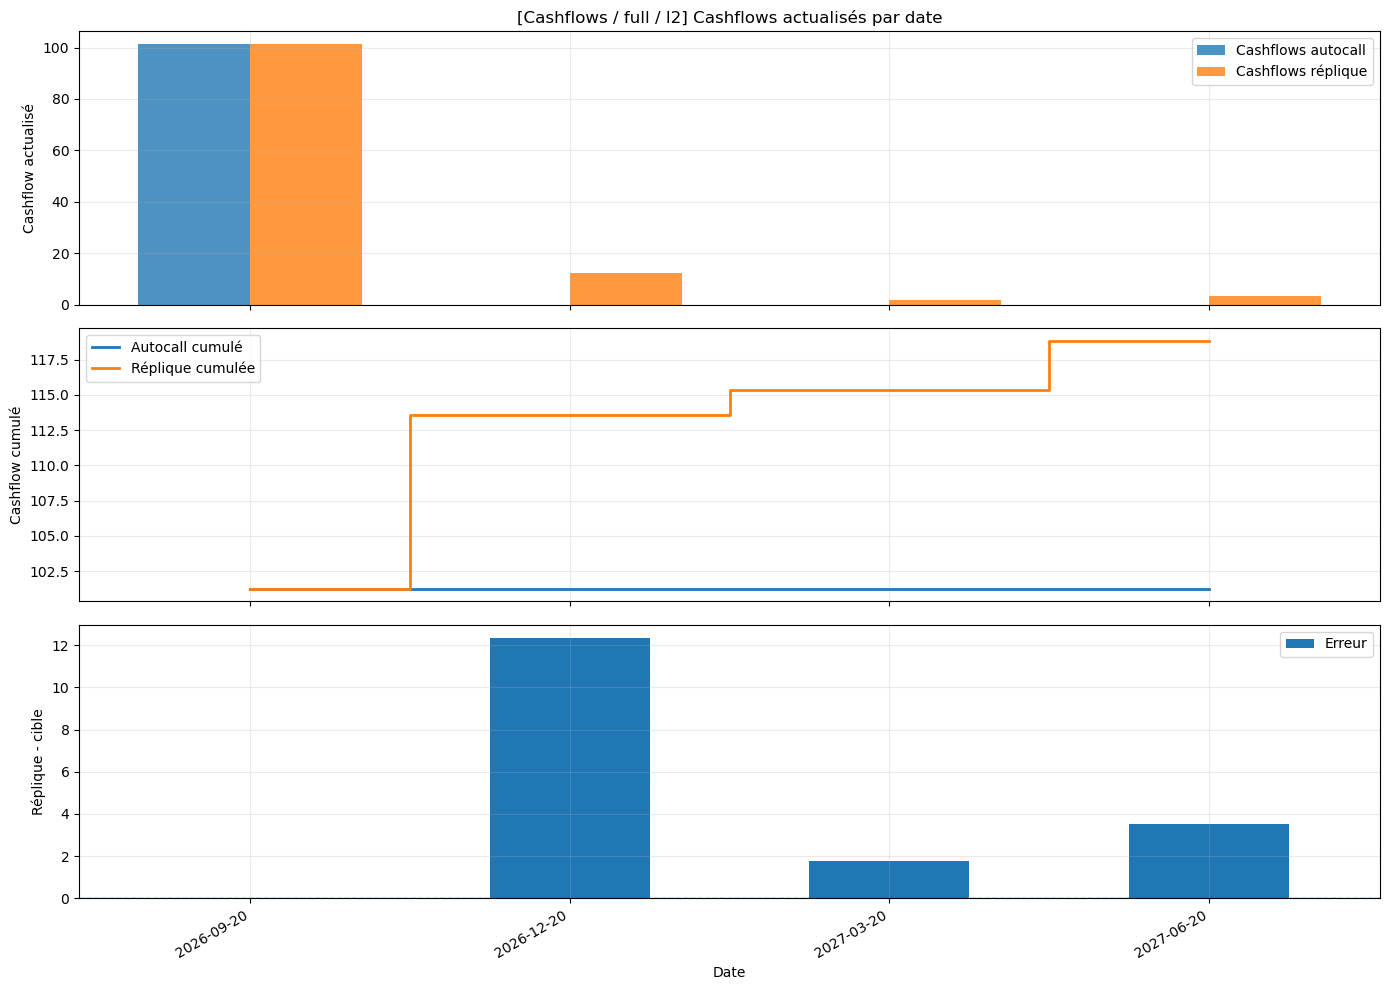

=== FULL / l2 ===
Métriques train :


mae              1.309270e+01
rmse             2.513607e+01
max_abs_error    9.816725e+01
mean_error      -2.232253e-08
dtype: float64

Métriques test :


mae              14.320979
rmse             26.921414
max_abs_error    97.051933
mean_error       -0.868320
dtype: float64

Métriques test par date :


,date,mae,rmse,max_abs_error,mean_error
0,2026-09-20,0.000002,0.000003,0.000011,-8.566649e-08
1,2026-12-20,17.554436,29.910569,94.252019,-2.513150e+00
2,2027-03-20,12.843371,26.123906,96.195355,-1.035610e+00
3,2027-06-20,26.886107,36.358623,97.051933,7.547954e-02


Panier de réplication :


,name,type,maturite,date_paiement,strike,quantite,payoff_actualise_unitaire,contribution,contribution_absolue
0,BC_20260920_100.00,BinaryCall,2026-09-20,2026-09-20,100.0,50.218837,0.992467,49.840532,49.840532
1,C_20270320_105.00,EuropeanCall,2027-03-20,2027-03-20,105.0,2.019413,18.347227,37.050634,37.050634
2,C_20270320_110.00,EuropeanCall,2027-03-20,2027-03-20,110.0,-2.385312,13.458169,-32.101931,32.101931
3,C_20270620_110.00,EuropeanCall,2027-06-20,2027-06-20,110.0,2.461432,8.713216,21.446989,21.446989
4,BC_20261220_100.00,BinaryCall,2026-12-20,2026-12-20,100.0,20.274857,0.985071,19.972183,19.972183
5,C_20261220_105.00,EuropeanCall,2026-12-20,2026-12-20,105.0,-4.186954,4.600096,-19.260390,19.260390
6,BC_20270320_100.00,BinaryCall,2027-03-20,2027-03-20,100.0,18.386954,0.977812,17.978975,17.978975
7,C_20270620_105.00,EuropeanCall,2027-06-20,2027-06-20,105.0,-1.273127,13.565444,-17.270531,17.270531
8,CASH_20270620,Cash,2027-06-20,2027-06-20,0.0,0.127469,97.044553,12.370191,12.370191
9,C_20270320_100.00,EuropeanCall,2027-03-20,2027-03-20,100.0,-0.520086,23.236284,-12.084871,12.084871


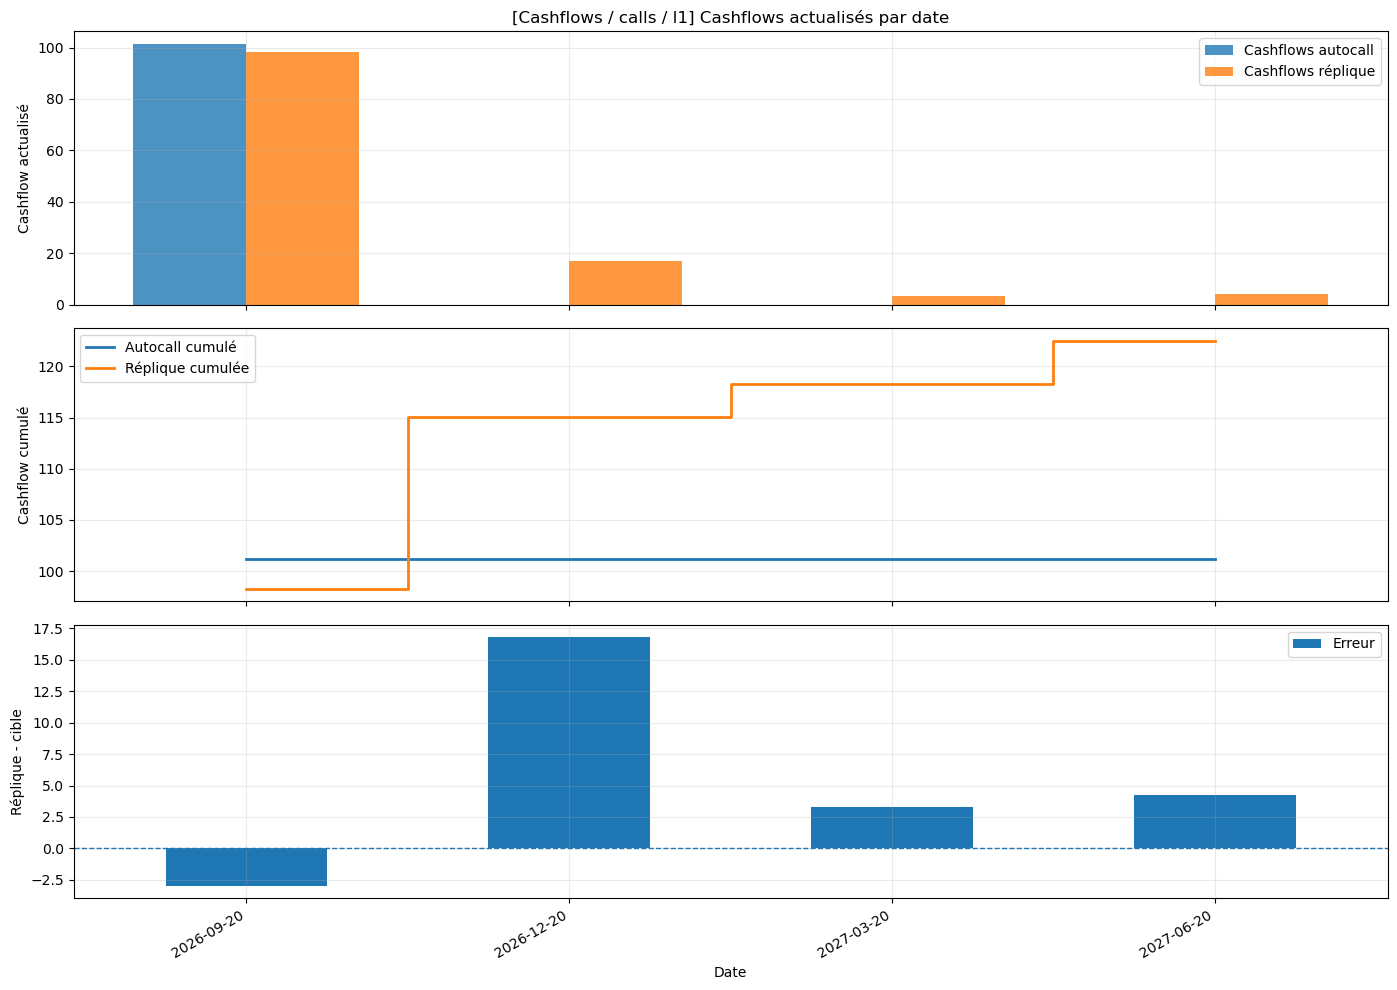

=== CALLS / l1 ===
Métriques train :


mae              15.938214
rmse             26.583714
max_abs_error    98.219071
mean_error       -0.000469
dtype: float64

Métriques test :


mae              17.079252
rmse             28.115636
max_abs_error    97.109502
mean_error       -0.896292
dtype: float64

Métriques test par date :


,date,mae,rmse,max_abs_error,mean_error
0,2026-09-20,9.236722,15.369232,50.800387,-0.451741
1,2026-12-20,18.813256,30.609879,95.536058,-2.271493
2,2027-03-20,13.361508,26.094508,95.053569,-1.023754
3,2027-06-20,26.905524,36.164273,97.109502,0.161820


Panier de réplication :


,name,type,maturite,date_paiement,strike,quantite,payoff_actualise_unitaire,contribution,contribution_absolue
0,C_20270620_75.00,EuropeanCall,2027-06-20,2027-06-20,75.0,-6.696250,42.678810,-285.787975,285.787975
1,C_20260920_95.00,EuropeanCall,2026-09-20,2026-09-20,95.0,17.040481,16.359650,278.776302,278.776302
2,C_20270320_95.00,EuropeanCall,2027-03-20,2027-03-20,95.0,5.642673,28.125342,158.702105,158.702105
3,C_20270620_70.00,EuropeanCall,2027-06-20,2027-06-20,70.0,3.242992,47.531037,154.142752,154.142752
4,C_20270620_80.00,EuropeanCall,2027-06-20,2027-06-20,80.0,3.392953,37.826582,128.343807,128.343807
5,C_20260920_90.00,EuropeanCall,2026-09-20,2026-09-20,90.0,-5.374535,21.321985,-114.595753,114.595753
6,C_20260920_105.00,EuropeanCall,2026-09-20,2026-09-20,105.0,-17.324325,6.434981,-111.481714,111.481714
7,C_20261220_95.00,EuropeanCall,2026-12-20,2026-12-20,95.0,6.450572,14.450811,93.215990,93.215990
8,C_20270620_100.00,EuropeanCall,2027-06-20,2027-06-20,100.0,4.963278,18.417671,91.412031,91.412031
9,C_20270320_105.00,EuropeanCall,2027-03-20,2027-03-20,105.0,-4.432129,18.347227,-81.317274,81.317274


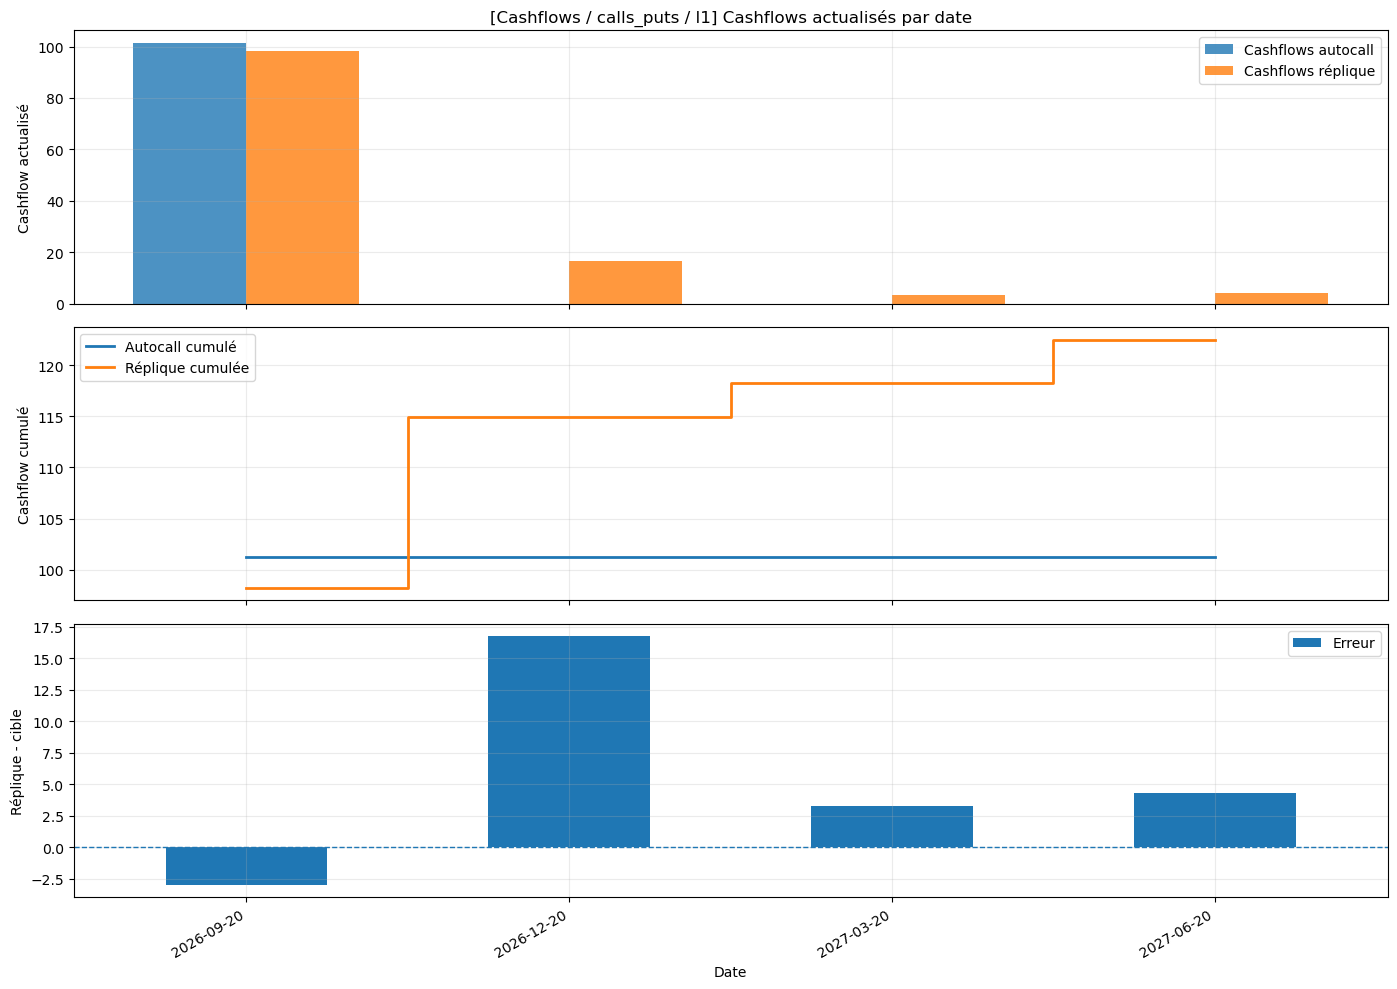

=== CALLS_PUTS / l1 ===
Métriques train :


mae              15.942220
rmse             26.582217
max_abs_error    98.225628
mean_error       -0.000590
dtype: float64

Métriques test :


mae              17.082676
rmse             28.124184
max_abs_error    97.107087
mean_error       -0.885466
dtype: float64

Métriques test par date :


,date,mae,rmse,max_abs_error,mean_error
0,2026-09-20,9.249142,15.369253,50.824017,-0.449306
1,2026-12-20,18.814308,30.610219,95.559176,-2.270687
2,2027-03-20,13.365694,26.098379,95.044679,-1.028136
3,2027-06-20,26.901560,36.187761,97.107087,0.206264


Panier de réplication :


,name,type,maturite,date_paiement,strike,quantite,payoff_actualise_unitaire,contribution,contribution_absolue
0,C_20260920_105.00,EuropeanCall,2026-09-20,2026-09-20,105.0,-11.064188,6.434981,-71.197843,71.197843
1,C_20260920_95.00,EuropeanCall,2026-09-20,2026-09-20,95.0,3.398773,16.359650,55.602733,55.602733
2,C_20270320_105.00,EuropeanCall,2027-03-20,2027-03-20,105.0,-2.202560,18.347227,-40.410861,40.410861
3,C_20270620_105.00,EuropeanCall,2027-06-20,2027-06-20,105.0,-2.223776,13.565444,-30.166511,30.166511
4,C_20261220_105.00,EuropeanCall,2026-12-20,2026-12-20,105.0,-6.455562,4.600096,-29.696205,29.696205
5,C_20270320_95.00,EuropeanCall,2027-03-20,2027-03-20,95.0,1.027178,28.125342,28.889722,28.889722
6,C_20270620_100.00,EuropeanCall,2027-06-20,2027-06-20,100.0,1.320451,18.417671,24.319635,24.319635
7,C_20260920_85.00,EuropeanCall,2026-09-20,2026-09-20,85.0,0.754101,26.284319,19.821034,19.821034
8,C_20270320_100.00,EuropeanCall,2027-03-20,2027-03-20,100.0,-0.843342,23.236284,-19.596123,19.596123
9,CASH_20270620,Cash,2027-06-20,2027-06-20,0.0,0.199367,97.044553,19.347471,19.347471


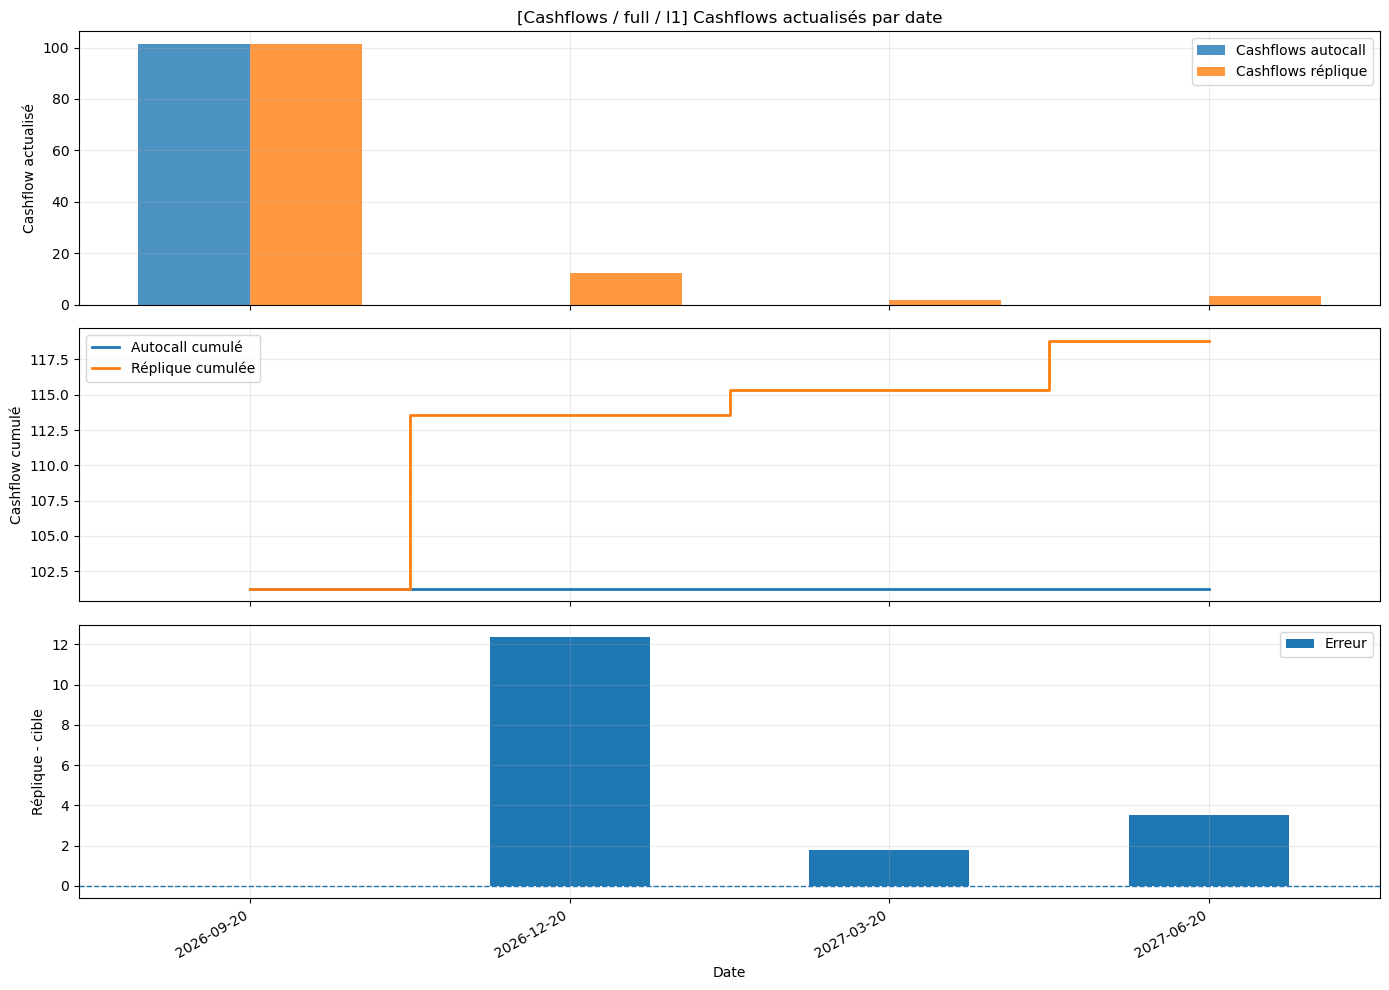

=== FULL / l1 ===
Métriques train :


mae              13.092953
rmse             25.136065
max_abs_error    98.167906
mean_error       -0.000577
dtype: float64

Métriques test :


mae              14.321239
rmse             26.921420
max_abs_error    97.052276
mean_error       -0.868889
dtype: float64

Métriques test par date :


,date,mae,rmse,max_abs_error,mean_error
0,2026-09-20,0.001136,0.001149,0.002547,-0.001128
1,2026-12-20,17.554536,29.910591,94.252882,-2.513758
2,2027-03-20,12.843292,26.123899,96.195617,-1.036059
3,2027-06-20,26.885993,36.358628,97.052276,0.075387


Panier de réplication :


,name,type,maturite,date_paiement,strike,quantite,payoff_actualise_unitaire,contribution,contribution_absolue
0,BC_20260920_100.00,BinaryCall,2026-09-20,2026-09-20,100.0,50.218822,0.992467,49.840517,49.840517
1,C_20270320_105.00,EuropeanCall,2027-03-20,2027-03-20,105.0,2.019495,18.347227,37.052131,37.052131
2,C_20270320_110.00,EuropeanCall,2027-03-20,2027-03-20,110.0,-2.385403,13.458169,-32.103153,32.103153
3,C_20270620_110.00,EuropeanCall,2027-06-20,2027-06-20,110.0,2.461510,8.713216,21.447666,21.447666
4,BC_20261220_100.00,BinaryCall,2026-12-20,2026-12-20,100.0,20.274749,0.985071,19.972076,19.972076
5,C_20261220_105.00,EuropeanCall,2026-12-20,2026-12-20,105.0,-4.187020,4.600096,-19.260694,19.260694
6,BC_20270320_100.00,BinaryCall,2027-03-20,2027-03-20,100.0,18.386952,0.977812,17.978974,17.978974
7,C_20270620_105.00,EuropeanCall,2027-06-20,2027-06-20,105.0,-1.273245,13.565444,-17.272137,17.272137
8,CASH_20270620,Cash,2027-06-20,2027-06-20,0.0,0.126562,97.044553,12.282136,12.282136
9,C_20270320_100.00,EuropeanCall,2027-03-20,2027-03-20,100.0,-0.520108,23.236284,-12.085386,12.085386


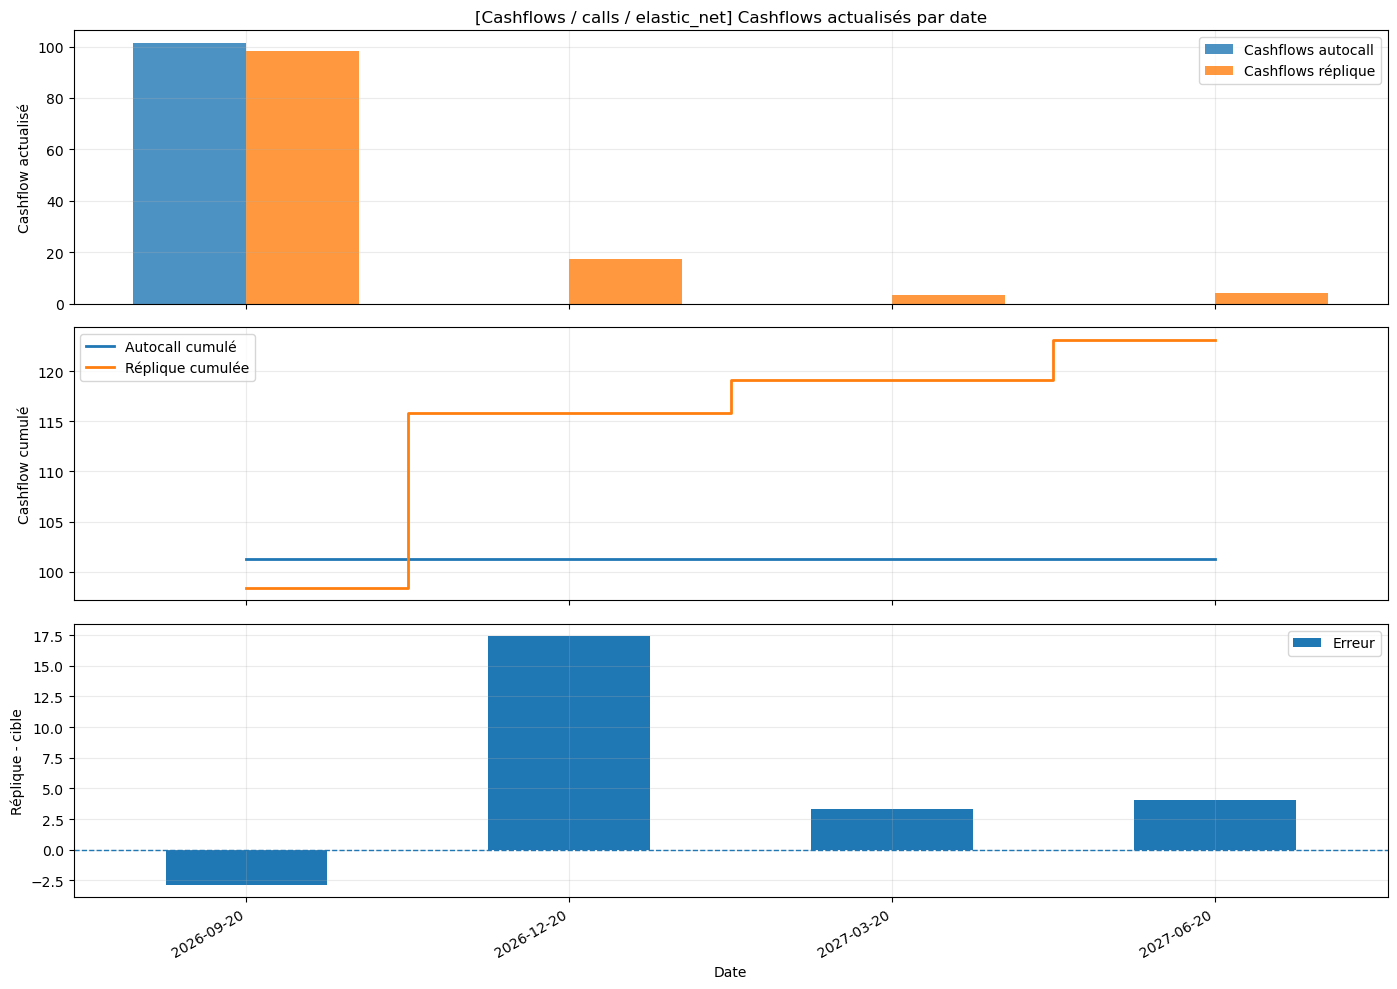

=== CALLS / elastic_net ===
Métriques train :


mae              15.898888
rmse             26.591566
max_abs_error    98.227566
mean_error        0.002669
dtype: float64

Métriques test :


mae              17.016727
rmse             28.095270
max_abs_error    97.090880
mean_error       -0.882996
dtype: float64

Métriques test par date :


,date,mae,rmse,max_abs_error,mean_error
0,2026-09-20,9.133143,15.358447,51.190078,-0.429745
1,2026-12-20,18.779438,30.618385,95.517403,-2.276246
2,2027-03-20,13.281891,26.057661,94.997867,-1.026547
3,2027-06-20,26.872435,36.124891,97.090880,0.200553


Panier de réplication :


,name,type,maturite,date_paiement,strike,quantite,payoff_actualise_unitaire,contribution,contribution_absolue
0,C_20260920_95.00,EuropeanCall,2026-09-20,2026-09-20,95.0,16.310035,16.359650,266.826475,266.826475
1,C_20270620_75.00,EuropeanCall,2027-06-20,2027-06-20,75.0,-3.527065,42.678810,-150.530944,150.530944
2,C_20270320_95.00,EuropeanCall,2027-03-20,2027-03-20,95.0,4.875413,28.125342,137.122653,137.122653
3,C_20260920_105.00,EuropeanCall,2026-09-20,2026-09-20,105.0,-17.318582,6.434981,-111.444757,111.444757
4,C_20260920_90.00,EuropeanCall,2026-09-20,2026-09-20,90.0,-4.547265,21.321985,-96.956707,96.956707
5,C_20261220_95.00,EuropeanCall,2026-12-20,2026-12-20,95.0,6.076541,14.450811,87.810947,87.810947
6,C_20270620_70.00,EuropeanCall,2027-06-20,2027-06-20,70.0,1.763865,47.531037,83.838322,83.838322
7,C_20270320_105.00,EuropeanCall,2027-03-20,2027-03-20,105.0,-4.364043,18.347227,-80.068079,80.068079
8,C_20270620_90.00,EuropeanCall,2027-06-20,2027-06-20,90.0,-2.613396,28.122127,-73.494244,73.494244
9,C_20270620_100.00,EuropeanCall,2027-06-20,2027-06-20,100.0,3.899018,18.417671,71.810839,71.810839


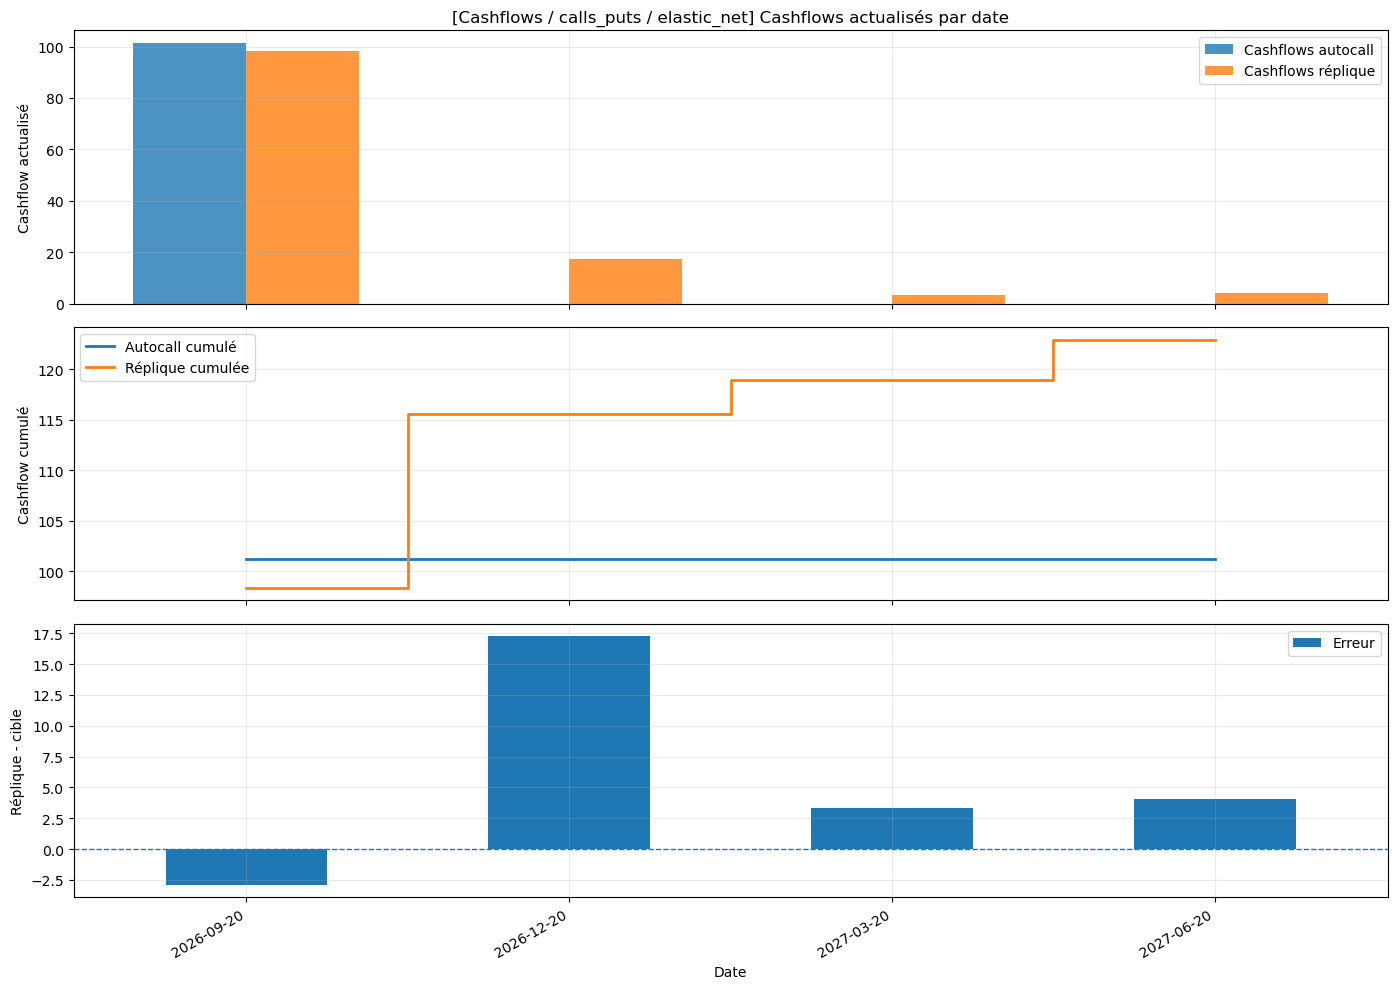

=== CALLS_PUTS / elastic_net ===
Métriques train :


mae              15.936645
rmse             26.582660
max_abs_error    98.229296
mean_error       -0.000245
dtype: float64

Métriques test :


mae              17.073234
rmse             28.117914
max_abs_error    97.086012
mean_error       -0.886459
dtype: float64

Métriques test par date :


,date,mae,rmse,max_abs_error,mean_error
0,2026-09-20,9.221235,15.368069,50.787649,-0.445810
1,2026-12-20,18.826721,30.606909,95.490309,-2.271234
2,2027-03-20,13.346574,26.080935,95.013248,-1.028311
3,2027-06-20,26.898404,36.184152,97.086012,0.199519


Panier de réplication :


,name,type,maturite,date_paiement,strike,quantite,payoff_actualise_unitaire,contribution,contribution_absolue
0,C_20260920_105.00,EuropeanCall,2026-09-20,2026-09-20,105.0,-10.986070,6.434981,-70.695154,70.695154
1,C_20260920_95.00,EuropeanCall,2026-09-20,2026-09-20,95.0,3.401150,16.359650,55.641626,55.641626
2,C_20270320_105.00,EuropeanCall,2027-03-20,2027-03-20,105.0,-2.133099,18.347227,-39.136459,39.136459
3,C_20261220_105.00,EuropeanCall,2026-12-20,2026-12-20,105.0,-6.239705,4.600096,-28.703241,28.703241
4,C_20270320_95.00,EuropeanCall,2027-03-20,2027-03-20,95.0,0.999371,28.125342,28.107656,28.107656
5,C_20270620_105.00,EuropeanCall,2027-06-20,2027-06-20,105.0,-1.986892,13.565444,-26.953068,26.953068
6,C_20270620_100.00,EuropeanCall,2027-06-20,2027-06-20,100.0,1.160620,18.417671,21.375915,21.375915
7,C_20260920_85.00,EuropeanCall,2026-09-20,2026-09-20,85.0,0.757284,26.284319,19.904692,19.904692
8,C_20270320_100.00,EuropeanCall,2027-03-20,2027-03-20,100.0,-0.824759,23.236284,-19.164337,19.164337
9,CASH_20270620,Cash,2027-06-20,2027-06-20,0.0,0.192553,97.044553,18.686189,18.686189


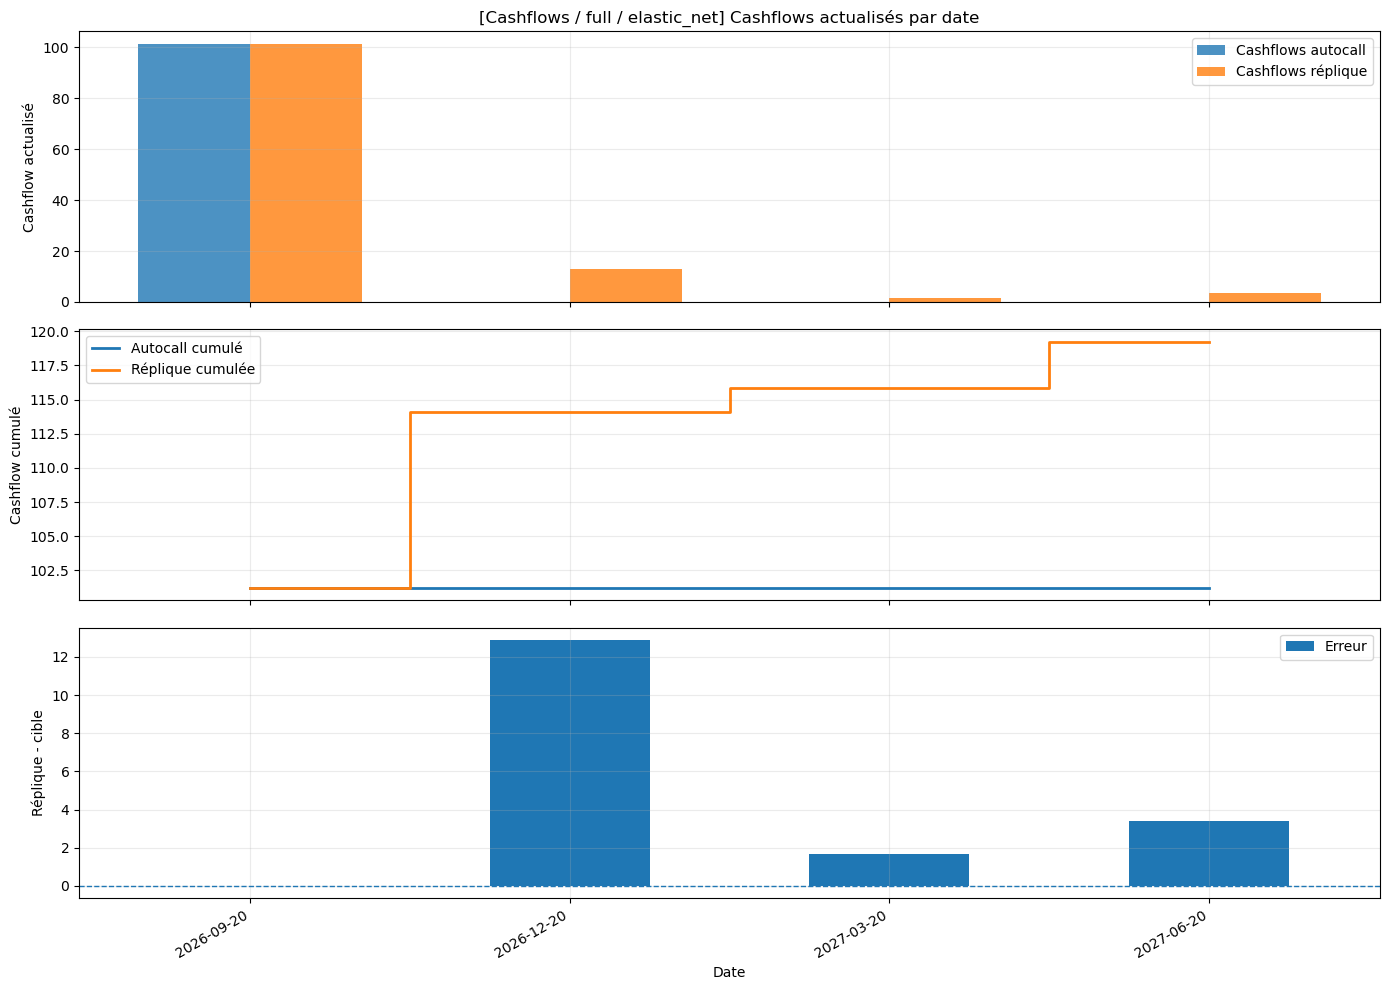

=== FULL / elastic_net ===
Métriques train :


mae              13.099392
rmse             25.136492
max_abs_error    98.165591
mean_error        0.000103
dtype: float64

Métriques test :


mae              14.323363
rmse             26.916665
max_abs_error    96.988728
mean_error       -0.868295
dtype: float64

Métriques test par date :


,date,mae,rmse,max_abs_error,mean_error
0,2026-09-20,0.006768,0.009551,0.034000,0.000087
1,2026-12-20,17.560200,29.903620,94.250373,-2.510091
2,2027-03-20,12.845020,26.126766,96.211402,-1.038368
3,2027-06-20,26.881464,36.348217,96.988728,0.075194


Panier de réplication :


,name,type,maturite,date_paiement,strike,quantite,payoff_actualise_unitaire,contribution,contribution_absolue
0,BC_20260920_100.00,BinaryCall,2026-09-20,2026-09-20,100.0,50.911300,0.992467,50.527779,50.527779
1,C_20270320_105.00,EuropeanCall,2027-03-20,2027-03-20,105.0,1.754505,18.347227,32.190303,32.190303
2,C_20270320_110.00,EuropeanCall,2027-03-20,2027-03-20,110.0,-2.117911,13.458169,-28.503209,28.503209
3,BC_20261220_100.00,BinaryCall,2026-12-20,2026-12-20,100.0,20.699060,0.985071,20.390054,20.390054
4,C_20261220_105.00,EuropeanCall,2026-12-20,2026-12-20,105.0,-4.026586,4.600096,-18.522685,18.522685
5,BC_20270320_100.00,BinaryCall,2027-03-20,2027-03-20,100.0,18.625378,0.977812,18.212109,18.212109
6,C_20270620_110.00,EuropeanCall,2027-06-20,2027-06-20,110.0,2.065337,8.713216,17.995726,17.995726
7,C_20270620_105.00,EuropeanCall,2027-06-20,2027-06-20,105.0,-1.035672,13.565444,-14.049346,14.049346
8,CASH_20270620,Cash,2027-06-20,2027-06-20,0.0,0.128601,97.044553,12.480004,12.480004
9,C_20270320_100.00,EuropeanCall,2027-03-20,2027-03-20,100.0,-0.433305,23.236284,-10.068404,10.068404


In [78]:
test_path = simulate_gbm_path(spot0=spot0,start_date=pd.Timestamp(valuation_date),end_date=pd.Timestamp(maturity_date),rate=rate,dividend_yield=dividend_yield,vol=vol,seed=10500)

for penalty in ["l2", "l1", "elastic_net"]:
    for family in ["calls", "calls_puts", "full"]:
        res_curve = run_naive_benchmark_curve(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family=family,n_paths=2000,penalty=penalty,alpha=1e-4)

        target_curve = autocall_value_curve_on_path(product=prod,path=test_path,valuation_date=valuation_date,rate=rate,curve_dates=res_curve["dates"])

        replica_curve = vanilla_portfolio_value_curve_on_path(vanillas=res_curve["vanillas"],weights=res_curve["w"],path=test_path,valuation_date=valuation_date,rate=rate,curve_dates=target_curve.index)

        plot_timewise_curve_benchmark(target_curve.index,target_curve.to_numpy(),replica_curve.to_numpy(),title_prefix=f"[Cashflows / {family} / {penalty}] ")

        basket = replication_basket_on_path(result=res_curve,path=test_path,valuation_date=valuation_date,rate=rate)

        print(f"=== {family.upper()} / {penalty} ===")

        print("Métriques train :")
        display(pd.Series(res_curve["metrics_train"]))

        print("Métriques test :")
        display(pd.Series(res_curve["metrics_test"]))

        print("Métriques test par date :")
        display(res_curve["metrics_by_date"])

        print("Panier de réplication :")
        display(basket.head(10))

In [80]:
# ============================================================
# BENCHMARK CONDITIONNEL SEMI-STATIQUE :
# un panier par date et par état observable du produit
# ============================================================

# ------------------------------------------------------------
# 0) Construction de la base conditionnelle :
#    une jambe cash et des vanilles à chaque date d'observation
# ------------------------------------------------------------
def build_conditional_vanilla_basis(
    product: AutocallProduct,
    spot0: float,
    valuation_date: str | pd.Timestamp,
    maturity_date: str | pd.Timestamp,
    family: str,
    spot_min_mult: float = 0.70,
    spot_max_mult: float = 1.30) -> list[VanillaProduct]:
    """Construit une base de vanilles organisée par date d'observation.
    Chaque date contient :
    - une jambe cash ;
    - les calls ;
    - éventuellement les puts et les binaires."""
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(maturity_date)

    vanilla_basis = build_naive_vanilla_basis(
        spot0=spot0,
        valuation_date=valuation_date,
        maturity_date=maturity_date,
        product=product,
        strike_step=5.0,
        strike_min_mult=spot_min_mult,
        strike_max_mult=spot_max_mult,
        family=family)

    observation_dates = sorted(set(
        [
            pd.Timestamp(d)
            for d in product.build_observation_dates(valuation_date)
            if valuation_date < pd.Timestamp(d) <= maturity_date
        ]
        + [maturity_date]
    ))

    vanillas = []

    for observation_date in observation_dates:
        # Une jambe cash par date.
        # Le panier n'est détenu que si l'autocall est encore vivant.
        cash = Cash(
            name=f"CASH_{observation_date.strftime('%Y%m%d')}",
            strike=0.0,
            maturity_date=observation_date,
            notional=float(product.notional))

        vanillas.append(cash)

        date_vanillas = [
            v for v in vanilla_basis
            if (
                not isinstance(v, Cash)
                and pd.Timestamp(v.maturity_date) == observation_date
            )
        ]

        vanillas.extend(date_vanillas)

    return vanillas


# ------------------------------------------------------------
# 1) États observables du produit le long d'un path
# ------------------------------------------------------------
def autocall_state_curve_on_path(
    product: AutocallProduct,
    path: pd.Series,
    valuation_date: str | pd.Timestamp,
    curve_dates: pd.DatetimeIndex) -> pd.DataFrame:
    """Retourne les états observables du produit à chaque date :
    - alive_before : le produit est vivant juste avant l'observation ;
    - barrier_hit  : la barrière basse a déjà été touchée jusqu'à cette date."""
    valuation_date = pd.Timestamp(valuation_date)
    curve_dates = pd.DatetimeIndex(curve_dates)

    path = path.sort_index().dropna()
    path = path.loc[path.index >= valuation_date]

    full_res = product.compute_autocall_payoff(
        path,
        start_date=valuation_date)

    call_date = full_res["call_date"]

    if call_date is not None:
        call_date = pd.Timestamp(call_date)

    spot_initial = float(full_res["spot_initial"])
    barrier_level = float(product.down_barrier) * spot_initial

    alive_before = np.zeros(
        len(curve_dates),
        dtype=bool)

    barrier_hit = np.zeros(
        len(curve_dates),
        dtype=bool)

    for i, d in enumerate(curve_dates):
        d = pd.Timestamp(d)

        # À la date de rappel, le produit est encore vivant juste
        # avant l'observation et doit produire son cashflow.
        alive_before[i] = (
            call_date is None
            or call_date >= d
        )

        path_until_date = path.loc[
            path.index <= d
        ]

        barrier_hit[i] = bool(
            (path_until_date <= barrier_level).any()
        )

    return pd.DataFrame({
        "date": curve_dates,
        "alive_before": alive_before,
        "barrier_hit": barrier_hit})


# ------------------------------------------------------------
# 2) Dataset conditionnel :
#    on enrichit le dataset actuel avec les états du produit
# ------------------------------------------------------------
def build_conditional_curve_dataset(
    product: AutocallProduct,
    vanillas: list[VanillaProduct],
    spot0: float,
    valuation_date: str | pd.Timestamp,
    maturity_date: str | pd.Timestamp,
    rate: float,
    dividend_yield: float,
    vol: float,
    n_paths: int = 2000,
    seed: int = 42) -> list[dict[str, object]]:
    """Construit le dataset pathwise puis ajoute :
    - alive_before ;
    - barrier_hit."""
    dataset = build_timewise_curve_dataset(
        product=product,
        vanillas=vanillas,
        spot0=spot0,
        valuation_date=valuation_date,
        maturity_date=maturity_date,
        rate=rate,
        dividend_yield=dividend_yield,
        vol=vol,
        n_paths=n_paths,
        seed=seed)

    for path_data in dataset:
        state_curve = autocall_state_curve_on_path(
            product=product,
            path=path_data["path"],
            valuation_date=valuation_date,
            curve_dates=path_data["dates"])

        path_data["alive_before"] = (
            state_curve["alive_before"]
            .to_numpy(dtype=bool)
        )

        path_data["barrier_hit"] = (
            state_curve["barrier_hit"]
            .to_numpy(dtype=bool)
        )

    return dataset


# ------------------------------------------------------------
# 3) Fit d'un panier conditionnel
# ------------------------------------------------------------
def fit_conditional_weights(
    X: np.ndarray,
    y: np.ndarray,
    penalty: str,
    alpha: float) -> tuple[np.ndarray, np.ndarray]:
    """Normalise la matrice, ajuste les poids puis revient
    dans l'échelle initiale."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    if len(X) == 0:
        raise ValueError(
            "Impossible d'ajuster un panier sur un dataset vide."
        )

    column_scale = np.sqrt(
        np.mean(X**2, axis=0)
    )

    column_scale[
        column_scale < 1e-12
    ] = 1.0

    # La première colonne de chaque sous-panier est toujours CASH.
    column_scale[0] = 1.0

    X_scaled = X / column_scale

    scaled_weights = fit_linear(
        X_scaled,
        y,
        penalty=penalty,
        alpha=alpha)

    weights = scaled_weights / column_scale

    return weights, column_scale


# ------------------------------------------------------------
# 4) Prédiction conditionnelle sur un élément du dataset
# ------------------------------------------------------------
def predict_conditional_path_data(
    path_data: dict[str, object],
    models: dict,
    split_final_by_barrier: bool = True) -> np.ndarray:
    """Applique les paniers conditionnels à une trajectoire.
    Si le produit est déjà rappelé, le cashflow répliqué est nul."""
    n_dates = len(path_data["dates"])
    prediction = np.zeros(n_dates, dtype=float)

    for i in range(n_dates):
        alive_before = bool(
            path_data["alive_before"][i]
        )

        if not alive_before:
            prediction[i] = 0.0
            continue

        is_final_date = (
            i == n_dates - 1
        )

        if (
            is_final_date
            and split_final_by_barrier
        ):
            state = bool(
                path_data["barrier_hit"][i]
            )
        else:
            state = None

        model_key = (i, state)

        # Si le sous-état de barrière contient trop peu de paths,
        # on utilise le modèle générique de la date.
        if model_key not in models:
            model_key = (i, None)

        model = models[model_key]
        feature_indices = model["feature_indices"]
        weights = model["weights"]

        X_date = path_data["X_curve"][
            i,
            feature_indices
        ]

        prediction[i] = float(
            X_date @ weights
        )

    return prediction


# ------------------------------------------------------------
# 5) Pipeline complet :
#    un panier par date, conditionnel à l'état du produit
# ------------------------------------------------------------
def run_conditional_benchmark_curve(
    product: AutocallProduct,
    spot0: float,
    valuation_date: str | pd.Timestamp,
    maturity_date: str | pd.Timestamp,
    rate: float,
    dividend_yield: float,
    vol: float,
    family: str = "full",
    n_paths: int = 2000,
    spot_min_mult: float = 0.70,
    spot_max_mult: float = 1.30,
    penalty: str = "l2",
    alpha: float = 1e-4,
    train_frac: float = 0.7,
    seed: int = 42,
    split_final_by_barrier: bool = True,
    min_state_paths: int = 20) -> dict[str, object]:
    """Apprend :
    - un panier par date parmi les paths encore vivants ;
    - deux paniers à maturité selon l'état de la barrière.

    Les poids sont appris uniquement sur les paths d'entraînement."""
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(maturity_date)

    vanillas = build_conditional_vanilla_basis(
        product=product,
        spot0=spot0,
        valuation_date=valuation_date,
        maturity_date=maturity_date,
        family=family,
        spot_min_mult=spot_min_mult,
        spot_max_mult=spot_max_mult)

    dataset = build_conditional_curve_dataset(
        product=product,
        vanillas=vanillas,
        spot0=spot0,
        valuation_date=valuation_date,
        maturity_date=maturity_date,
        rate=rate,
        dividend_yield=dividend_yield,
        vol=vol,
        n_paths=n_paths,
        seed=seed)

    split = int(train_frac * n_paths)
    split = max(
        1,
        min(
            split,
            n_paths - 1 if n_paths > 1 else 1))

    train_set = dataset[:split]
    test_set = dataset[split:]

    dates = pd.DatetimeIndex(
        dataset[0]["dates"]
    )

    first_path = dataset[0]["path"]

    # Colonnes de vanilles associées à chaque date.
    feature_indices_by_date = {}

    for i, d in enumerate(dates):
        d = pd.Timestamp(d)

        feature_indices = []

        for j, vanilla in enumerate(vanillas):
            payment_date = effective_date_on_path(
                path=first_path,
                contractual_date=vanilla.maturity_date)

            if payment_date == d:
                feature_indices.append(j)

        if len(feature_indices) == 0:
            raise ValueError(
                f"Aucune vanille disponible à la date {d}."
            )

        feature_indices_by_date[i] = np.array(
            feature_indices,
            dtype=int)

    models = {}

    for i, d in enumerate(dates):
        feature_indices = (
            feature_indices_by_date[i]
        )

        alive_mask = np.array([
            bool(path_data["alive_before"][i])
            for path_data in train_set
        ])

        X_date = np.vstack([
            path_data["X_curve"][
                i,
                feature_indices
            ]
            for path_data in train_set
        ])

        y_date = np.array([
            path_data["y_curve"][i]
            for path_data in train_set
        ])

        # Modèle générique de la date, ajusté sur tous les paths vivants.
        X_alive = X_date[alive_mask]
        y_alive = y_date[alive_mask]

        if len(X_alive) == 0:
            raise ValueError(
                f"Aucun path vivant pour la date {d}."
            )

        weights, column_scale = fit_conditional_weights(
            X=X_alive,
            y=y_alive,
            penalty=penalty,
            alpha=alpha)

        models[(i, None)] = {
            "date": pd.Timestamp(d),
            "state": None,
            "feature_indices": feature_indices,
            "weights": weights,
            "column_scale": column_scale,
            "n_train_paths": int(len(X_alive))}

        # À maturité, on peut distinguer les deux états de barrière.
        is_final_date = (
            i == len(dates) - 1
        )

        if (
            is_final_date
            and split_final_by_barrier
        ):
            for barrier_state in [False, True]:
                barrier_mask = np.array([
                    bool(path_data["barrier_hit"][i])
                    == barrier_state
                    for path_data in train_set
                ])

                state_mask = (
                    alive_mask
                    & barrier_mask
                )

                if (
                    int(np.sum(state_mask))
                    < min_state_paths
                ):
                    continue

                X_state = X_date[state_mask]
                y_state = y_date[state_mask]

                state_weights, state_scale = (
                    fit_conditional_weights(
                        X=X_state,
                        y=y_state,
                        penalty=penalty,
                        alpha=alpha)
                )

                models[(i, barrier_state)] = {
                    "date": pd.Timestamp(d),
                    "state": barrier_state,
                    "feature_indices": feature_indices,
                    "weights": state_weights,
                    "column_scale": state_scale,
                    "n_train_paths": int(len(X_state))}

    # Prédictions train
    pred_train_matrix = np.vstack([
        predict_conditional_path_data(
            path_data=path_data,
            models=models,
            split_final_by_barrier=split_final_by_barrier)
        for path_data in train_set
    ])

    y_train_matrix = np.vstack([
        path_data["y_curve"]
        for path_data in train_set
    ])

    # Prédictions test
    if len(test_set) > 0:
        pred_test_matrix = np.vstack([
            predict_conditional_path_data(
                path_data=path_data,
                models=models,
                split_final_by_barrier=split_final_by_barrier)
            for path_data in test_set
        ])

        y_test_matrix = np.vstack([
            path_data["y_curve"]
            for path_data in test_set
        ])
    else:
        pred_test_matrix = np.empty(
            (0, len(dates))
        )

        y_test_matrix = np.empty(
            (0, len(dates))
        )

    metrics_train = benchmark_metrics(
        y_train_matrix.reshape(-1),
        pred_train_matrix.reshape(-1))

    metrics_test = (
        benchmark_metrics(
            y_test_matrix.reshape(-1),
            pred_test_matrix.reshape(-1))
        if len(test_set) > 0
        else {}
    )

    # Métriques calculées uniquement sur les observations vivantes.
    train_alive_mask = np.vstack([
        path_data["alive_before"]
        for path_data in train_set
    ]).astype(bool)

    metrics_train_alive = benchmark_metrics(
        y_train_matrix[train_alive_mask],
        pred_train_matrix[train_alive_mask])

    if len(test_set) > 0:
        test_alive_mask = np.vstack([
            path_data["alive_before"]
            for path_data in test_set
        ]).astype(bool)

        metrics_test_alive = benchmark_metrics(
            y_test_matrix[test_alive_mask],
            pred_test_matrix[test_alive_mask])
    else:
        test_alive_mask = np.empty(
            (0, len(dates)),
            dtype=bool)

        metrics_test_alive = {}

    metrics_by_date = []

    if len(test_set) > 0:
        for i, d in enumerate(dates):
            y_date = y_test_matrix[:, i]
            pred_date = pred_test_matrix[:, i]
            alive_date = test_alive_mask[:, i]

            metrics_all = benchmark_metrics(
                y_date,
                pred_date)

            row = {
                "date": pd.Timestamp(d),
                "n_test": int(len(y_date)),
                "n_alive": int(np.sum(alive_date)),
                "mae": metrics_all["mae"],
                "rmse": metrics_all["rmse"],
                "max_abs_error": metrics_all["max_abs_error"],
                "mean_error": metrics_all["mean_error"]}

            if np.any(alive_date):
                metrics_alive = benchmark_metrics(
                    y_date[alive_date],
                    pred_date[alive_date])

                row.update({
                    "mae_alive": metrics_alive["mae"],
                    "rmse_alive": metrics_alive["rmse"],
                    "max_abs_error_alive": metrics_alive["max_abs_error"],
                    "mean_error_alive": metrics_alive["mean_error"]})

            metrics_by_date.append(row)

    metrics_by_date = pd.DataFrame(
        metrics_by_date
    )

    # Tableau lisible de tous les paniers conditionnels.
    weights_rows = []

    for (date_index, state), model in models.items():
        feature_indices = model["feature_indices"]

        if state is None:
            state_name = "alive"
        elif state:
            state_name = "barrier_hit"
        else:
            state_name = "barrier_not_hit"

        for local_index, feature_index in enumerate(feature_indices):
            vanilla = vanillas[feature_index]

            weights_rows.append({
                "date": model["date"],
                "state": state_name,
                "n_train_paths": model["n_train_paths"],
                "name": vanilla.name,
                "kind": vanilla.__class__.__name__,
                "maturity_date": pd.Timestamp(
                    vanilla.maturity_date),
                "strike": float(vanilla.strike),
                "weight": float(
                    model["weights"][local_index])})

    weights = pd.DataFrame(
        weights_rows
    )

    weights["absolute_weight"] = (
        weights["weight"].abs()
    )

    weights = weights.sort_values(
        ["date", "state", "absolute_weight"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    return {
        "vanillas": vanillas,
        "dates": dates,
        "dataset": dataset,
        "train_set": train_set,
        "test_set": test_set,
        "models": models,
        "weights": weights,
        "pred_train_matrix": pred_train_matrix,
        "pred_test_matrix": pred_test_matrix,
        "y_train_matrix": y_train_matrix,
        "y_test_matrix": y_test_matrix,
        "metrics_train": metrics_train,
        "metrics_test": metrics_test,
        "metrics_train_alive": metrics_train_alive,
        "metrics_test_alive": metrics_test_alive,
        "metrics_by_date": metrics_by_date,
        "family": family,
        "split": split,
        "split_final_by_barrier": split_final_by_barrier}


# ------------------------------------------------------------
# 6) Construction des features sur un nouveau path
# ------------------------------------------------------------
def conditional_features_on_path(
    vanillas: list[VanillaProduct],
    path: pd.Series,
    valuation_date: str | pd.Timestamp,
    rate: float,
    curve_dates: pd.DatetimeIndex) -> np.ndarray:
    """Construit la matrice de payoffs des vanilles
    pour une trajectoire donnée."""
    valuation_date = pd.Timestamp(valuation_date)
    curve_dates = pd.DatetimeIndex(curve_dates)

    path = path.sort_index().dropna()
    path = path.loc[
        path.index >= valuation_date
    ]

    X_curve = np.zeros(
        (len(curve_dates), len(vanillas)),
        dtype=float)

    date_to_index = {
        pd.Timestamp(d): i
        for i, d in enumerate(curve_dates)
    }

    for j, vanilla in enumerate(vanillas):
        payment_date = effective_date_on_path(
            path=path,
            contractual_date=vanilla.maturity_date)

        if payment_date not in date_to_index:
            raise ValueError(
                f"La maturité {payment_date} de {vanilla.name} "
                "ne correspond à aucune date de la courbe."
            )

        i = date_to_index[payment_date]

        X_curve[i, j] = (
            vanilla_discounted_payoff_from_path(
                vanilla=vanilla,
                path=path,
                valuation_date=valuation_date,
                rate=rate)
        )

    return X_curve


# ------------------------------------------------------------
# 7) Application des paniers conditionnels sur un nouveau path
# ------------------------------------------------------------
def conditional_portfolio_value_curve_on_path(
    result,
    product: AutocallProduct,
    path: pd.Series,
    valuation_date: str | pd.Timestamp,
    rate: float):
    """Applique la stratégie conditionnelle sur un nouveau path.
    Retourne :
    - les cashflows de l'autocall ;
    - les cashflows répliqués ;
    - les états du produit."""
    curve_dates = pd.DatetimeIndex(
        result["dates"]
    )

    target_curve = autocall_value_curve_on_path(
        product=product,
        path=path,
        valuation_date=valuation_date,
        rate=rate,
        curve_dates=curve_dates)

    X_curve = conditional_features_on_path(
        vanillas=result["vanillas"],
        path=path,
        valuation_date=valuation_date,
        rate=rate,
        curve_dates=curve_dates)

    state_curve = autocall_state_curve_on_path(
        product=product,
        path=path,
        valuation_date=valuation_date,
        curve_dates=curve_dates)

    path_data = {
        "path": path,
        "dates": curve_dates,
        "X_curve": X_curve,
        "y_curve": target_curve.to_numpy(dtype=float),
        "alive_before": state_curve[
            "alive_before"
        ].to_numpy(dtype=bool),
        "barrier_hit": state_curve[
            "barrier_hit"
        ].to_numpy(dtype=bool)}

    replica_values = predict_conditional_path_data(
        path_data=path_data,
        models=result["models"],
        split_final_by_barrier=result[
            "split_final_by_barrier"])

    replica_curve = pd.Series(
        replica_values,
        index=curve_dates,
        name="conditional_replica_cashflow")

    return (
        target_curve,
        replica_curve,
        state_curve)

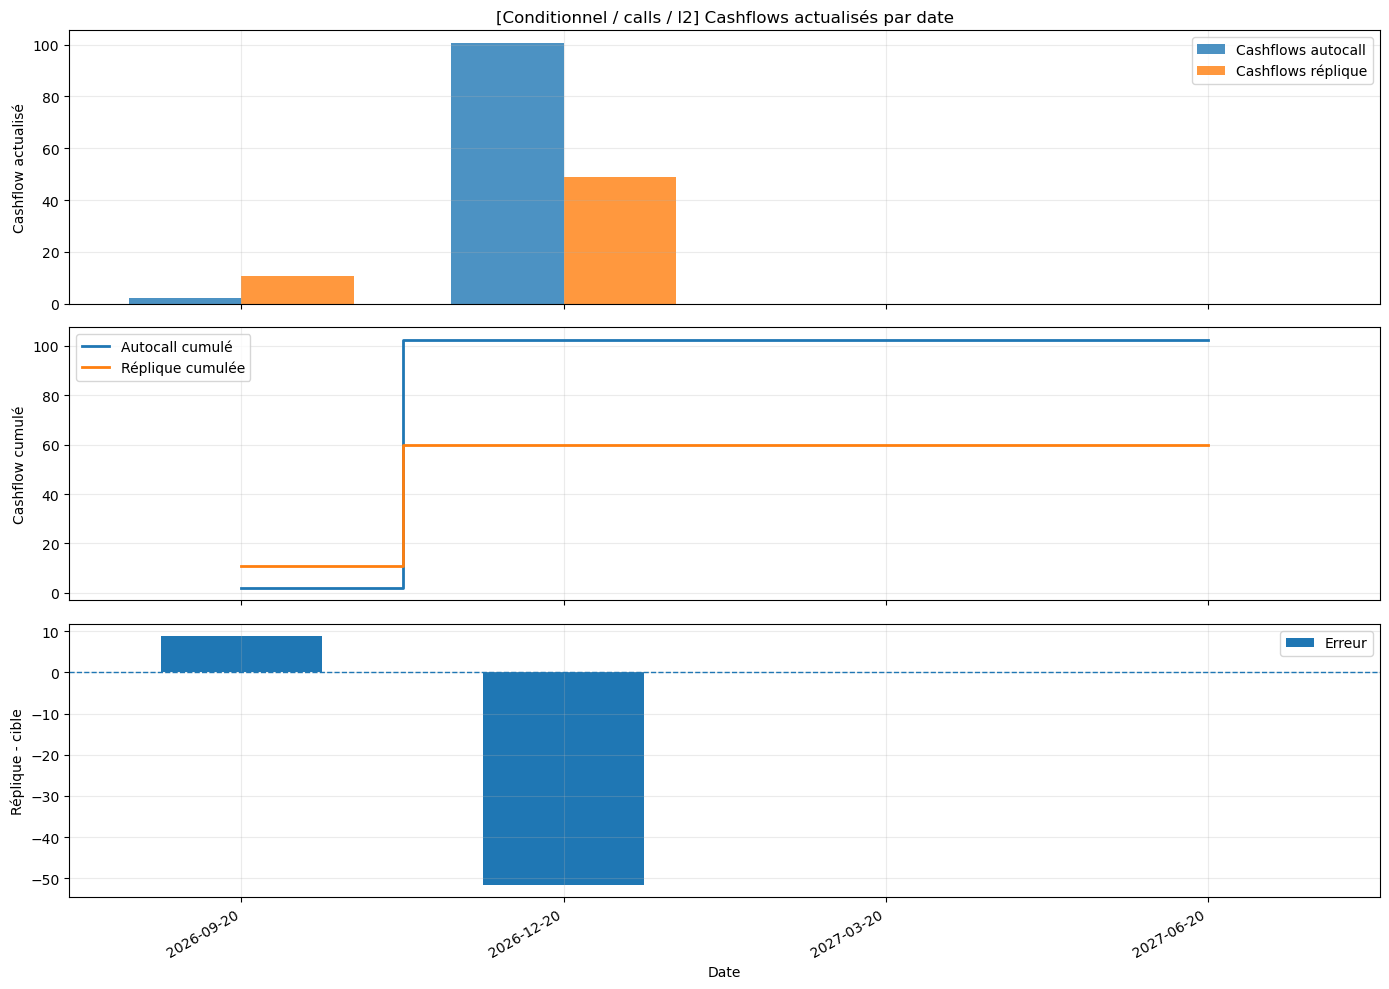

Métriques globales train :


mae              3.656759e+00
rmse             9.538552e+00
max_abs_error    5.519158e+01
mean_error      -1.949069e-13
dtype: float64

Métriques globales test :


mae               3.731311
rmse              9.533668
max_abs_error    52.706131
mean_error       -0.059120
dtype: float64

Métriques train sur les paths vivants :


...

,date,n_test,n_alive,mae,rmse,max_abs_error,mean_error,mae_alive,rmse_alive,max_abs_error_alive,mean_error_alive
0,2026-09-20,600,600,9.248873,15.369216,50.823807,-0.448292,9.248873,15.369216,50.823807,-0.448292
1,2026-12-20,600,312,3.512975,8.956315,52.706131,-0.440731,6.755721,12.420174,52.706131,-0.847559
2,2027-03-20,600,226,1.834369,6.745778,49.385229,0.604132,4.870006,10.991411,49.385229,1.603890
3,2027-06-20,600,176,0.329029,1.276499,12.861969,0.048413,1.121691,2.356892,12.861969,0.165043


États du path affiché :


,date,alive_before,barrier_hit
0,2026-09-20,True,False
1,2026-12-20,True,False
2,2027-03-20,False,False
3,2027-06-20,False,False


Paniers conditionnels :


,date,state,n_train_paths,name,kind,maturity_date,strike,weight,absolute_weight
0,2026-09-20,alive,1400,C_20260920_105.00,EuropeanCall,2026-09-20,105.0,-17.366032,17.366032
1,2026-09-20,alive,1400,C_20260920_95.00,EuropeanCall,2026-09-20,95.0,17.051977,17.051977
2,2026-09-20,alive,1400,C_20260920_90.00,EuropeanCall,2026-09-20,90.0,-5.403792,5.403792
3,2026-09-20,alive,1400,C_20260920_110.00,EuropeanCall,2026-09-20,110.0,5.340268,5.340268
4,2026-09-20,alive,1400,C_20260920_115.00,EuropeanCall,2026-09-20,115.0,-1.758125,1.758125
5,2026-09-20,alive,1400,C_20260920_85.00,EuropeanCall,2026-09-20,85.0,1.483460,1.483460
6,2026-09-20,alive,1400,C_20260920_80.00,EuropeanCall,2026-09-20,80.0,-0.720613,0.720613
7,2026-09-20,alive,1400,C_20260920_75.00,EuropeanCall,2026-09-20,75.0,0.684436,0.684436
8,2026-09-20,alive,1400,C_20260920_120.00,EuropeanCall,2026-09-20,120.0,0.634692,0.634692
9,2026-09-20,alive,1400,C_20260920_100.00,EuropeanCall,2026-09-20,100.0,0.434291,0.434291


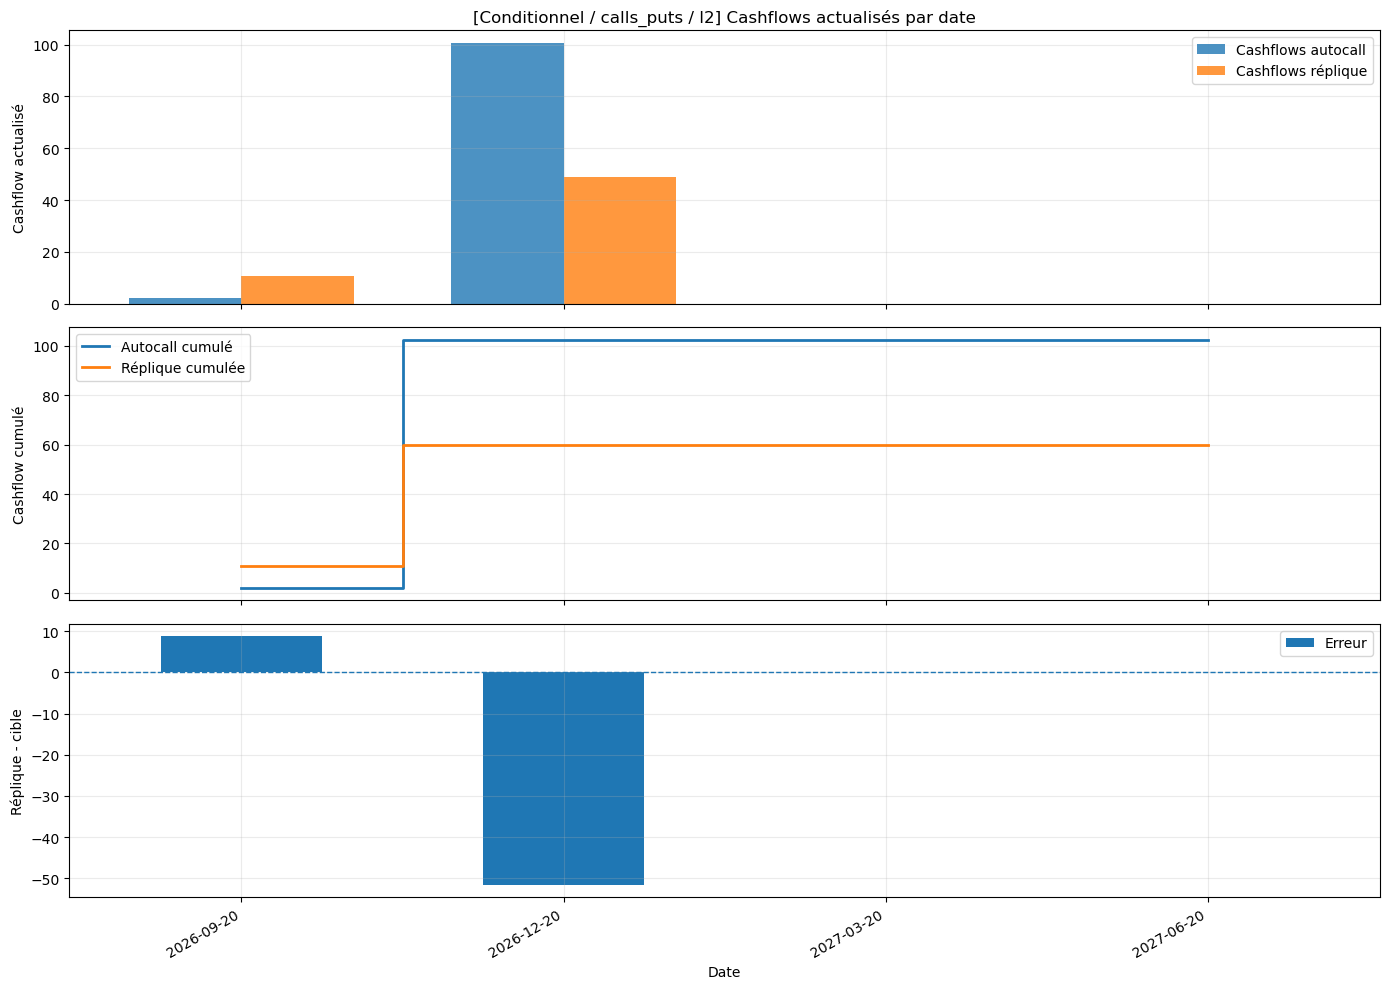

Métriques globales train :


mae              3.589561e+00
rmse             9.516477e+00
max_abs_error    5.519130e+01
mean_error      -3.577126e-13
dtype: float64

Métriques globales test :


mae               3.659742
rmse              9.512599
max_abs_error    52.705862
mean_error       -0.070116
dtype: float64

Métriques train sur les paths vivants :


...

,date,n_test,n_alive,mae,rmse,max_abs_error,mean_error,mae_alive,rmse_alive,max_abs_error_alive,mean_error_alive
0,2026-09-20,600,600,9.249115,15.369233,50.823118,-0.448471,9.249115,15.369233,50.823118,-0.448471
1,2026-12-20,600,312,3.512736,8.956300,52.705862,-0.440508,6.755261,12.420154,52.705862,-0.847131
2,2027-03-20,600,226,1.834395,6.745788,49.385397,0.603411,4.870075,10.991428,49.385397,1.601975
3,2027-06-20,600,176,0.042725,0.154510,1.103614,0.005106,0.145652,0.285283,1.103614,0.017408


États du path affiché :


,date,alive_before,barrier_hit
0,2026-09-20,True,False
1,2026-12-20,True,False
2,2027-03-20,False,False
3,2027-06-20,False,False


Paniers conditionnels :


,date,state,n_train_paths,name,kind,maturity_date,strike,weight,absolute_weight
0,2026-09-20,alive,1400,P_20260920_95.00,EuropeanPut,2026-09-20,95.0,13.957163,13.957163
1,2026-09-20,alive,1400,C_20260920_105.00,EuropeanCall,2026-09-20,105.0,-10.825358,10.825358
2,2026-09-20,alive,1400,P_20260920_105.00,EuropeanPut,2026-09-20,105.0,-6.540505,6.540505
3,2026-09-20,alive,1400,P_20260920_90.00,EuropeanPut,2026-09-20,90.0,-5.767014,5.767014
4,2026-09-20,alive,1400,C_20260920_110.00,EuropeanCall,2026-09-20,110.0,5.351769,5.351769
5,2026-09-20,alive,1400,C_20260920_95.00,EuropeanCall,2026-09-20,95.0,3.096028,3.096028
6,2026-09-20,alive,1400,C_20260920_115.00,EuropeanCall,2026-09-20,115.0,-1.229265,1.229265
7,2026-09-20,alive,1400,C_20260920_100.00,EuropeanCall,2026-09-20,100.0,1.162578,1.162578
8,2026-09-20,alive,1400,P_20260920_85.00,EuropeanPut,2026-09-20,85.0,1.105552,1.105552
9,2026-09-20,alive,1400,P_20260920_80.00,EuropeanPut,2026-09-20,80.0,-0.983839,0.983839


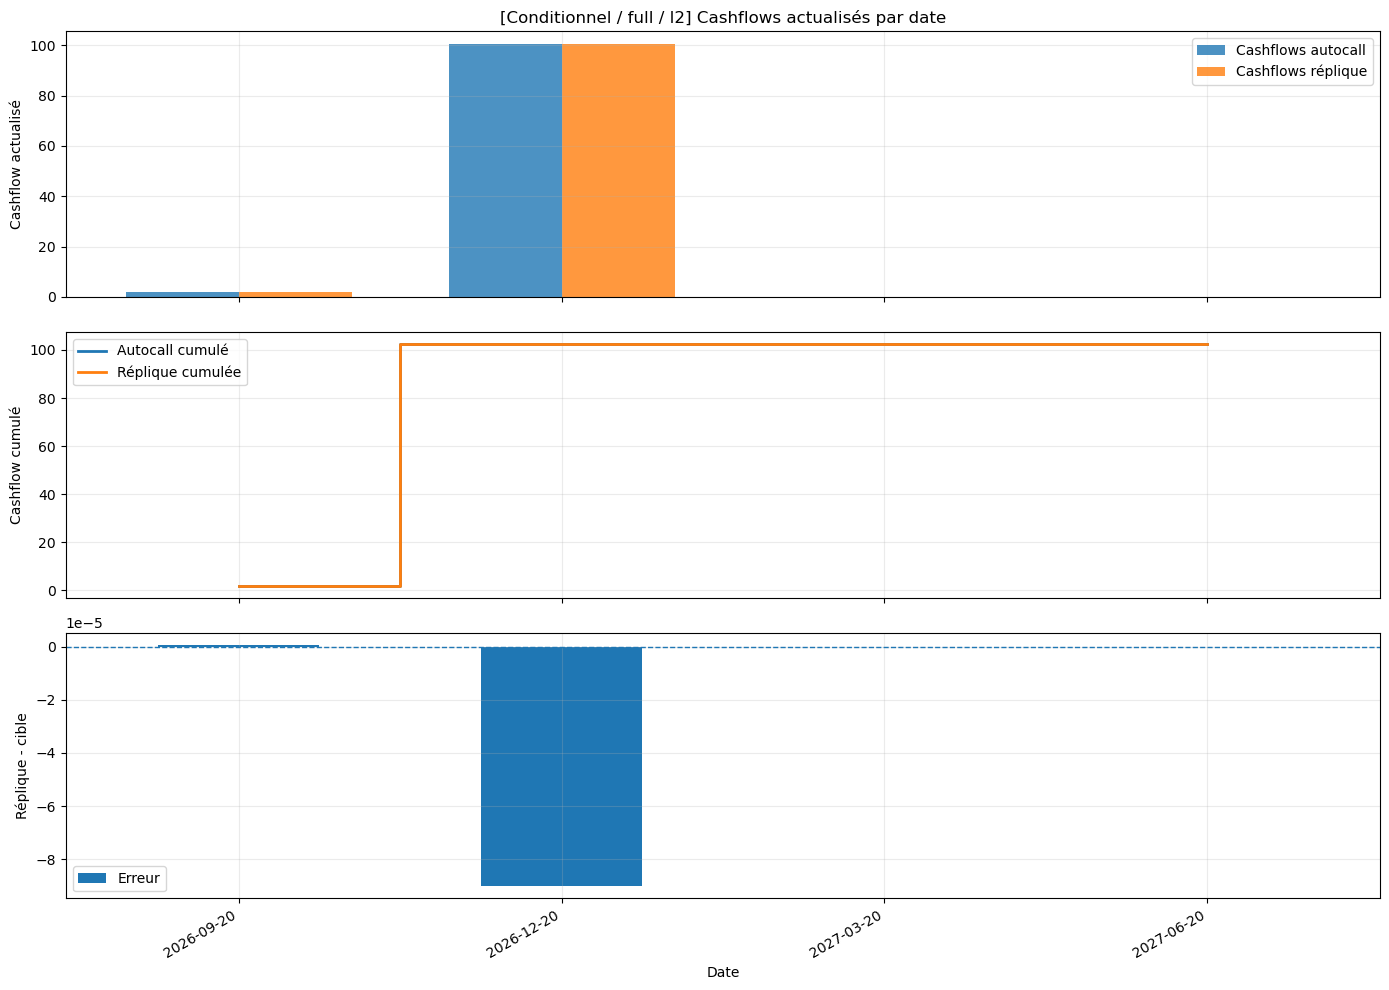

Métriques globales train :


mae              3.620293e-06
rmse             1.261972e-05
max_abs_error    1.297664e-04
mean_error      -2.452856e-13
dtype: float64

Métriques globales test :


mae              3.806039e-06
rmse             1.307121e-05
max_abs_error    1.306781e-04
mean_error       8.786680e-08
dtype: float64

Métriques train sur les paths vivants :


...

,date,n_test,n_alive,mae,rmse,max_abs_error,mean_error,mae_alive,rmse_alive,max_abs_error_alive,mean_error_alive
0,2026-09-20,600,600,0.000006,0.000012,0.000043,-1.941295e-07,0.000006,0.000012,0.000043,-1.941295e-07
1,2026-12-20,600,312,0.000005,0.000015,0.000092,-5.754647e-07,0.000009,0.000020,0.000092,-1.106663e-06
2,2027-03-20,600,226,0.000004,0.000017,0.000131,8.830350e-07,0.000010,0.000028,0.000131,2.344341e-06
3,2027-06-20,600,176,0.000001,0.000006,0.000051,2.380264e-07,0.000004,0.000010,0.000051,8.114537e-07


États du path affiché :


,date,alive_before,barrier_hit
0,2026-09-20,True,False
1,2026-12-20,True,False
2,2027-03-20,False,False
3,2027-06-20,False,False


Paniers conditionnels :


,date,state,n_train_paths,name,kind,maturity_date,strike,weight,absolute_weight
0,2026-09-20,alive,1400,BP_20260920_100.00,BinaryPut,2026-09-20,100.0,-5.249995e+01,5.249995e+01
1,2026-09-20,alive,1400,BC_20260920_100.00,BinaryCall,2026-09-20,100.0,4.749996e+01,4.749996e+01
2,2026-09-20,alive,1400,BP_20260920_80.00,BinaryPut,2026-09-20,80.0,-1.935707e+00,1.935707e+00
3,2026-09-20,alive,1400,CASH_20260920,Cash,2026-09-20,0.0,5.443549e-01,5.443549e-01
4,2026-09-20,alive,1400,BC_20260920_80.00,BinaryCall,2026-09-20,80.0,6.429223e-02,6.429223e-02
5,2026-09-20,alive,1400,BP_20260920_105.00,BinaryPut,2026-09-20,105.0,3.873612e-05,3.873612e-05
6,2026-09-20,alive,1400,BP_20260920_125.00,BinaryPut,2026-09-20,125.0,3.585363e-05,3.585363e-05
7,2026-09-20,alive,1400,BC_20260920_125.00,BinaryCall,2026-09-20,125.0,3.585359e-05,3.585359e-05
8,2026-09-20,alive,1400,BP_20260920_95.00,BinaryPut,2026-09-20,95.0,3.555194e-05,3.555194e-05
9,2026-09-20,alive,1400,BP_20260920_110.00,BinaryPut,2026-09-20,110.0,3.023485e-05,3.023485e-05


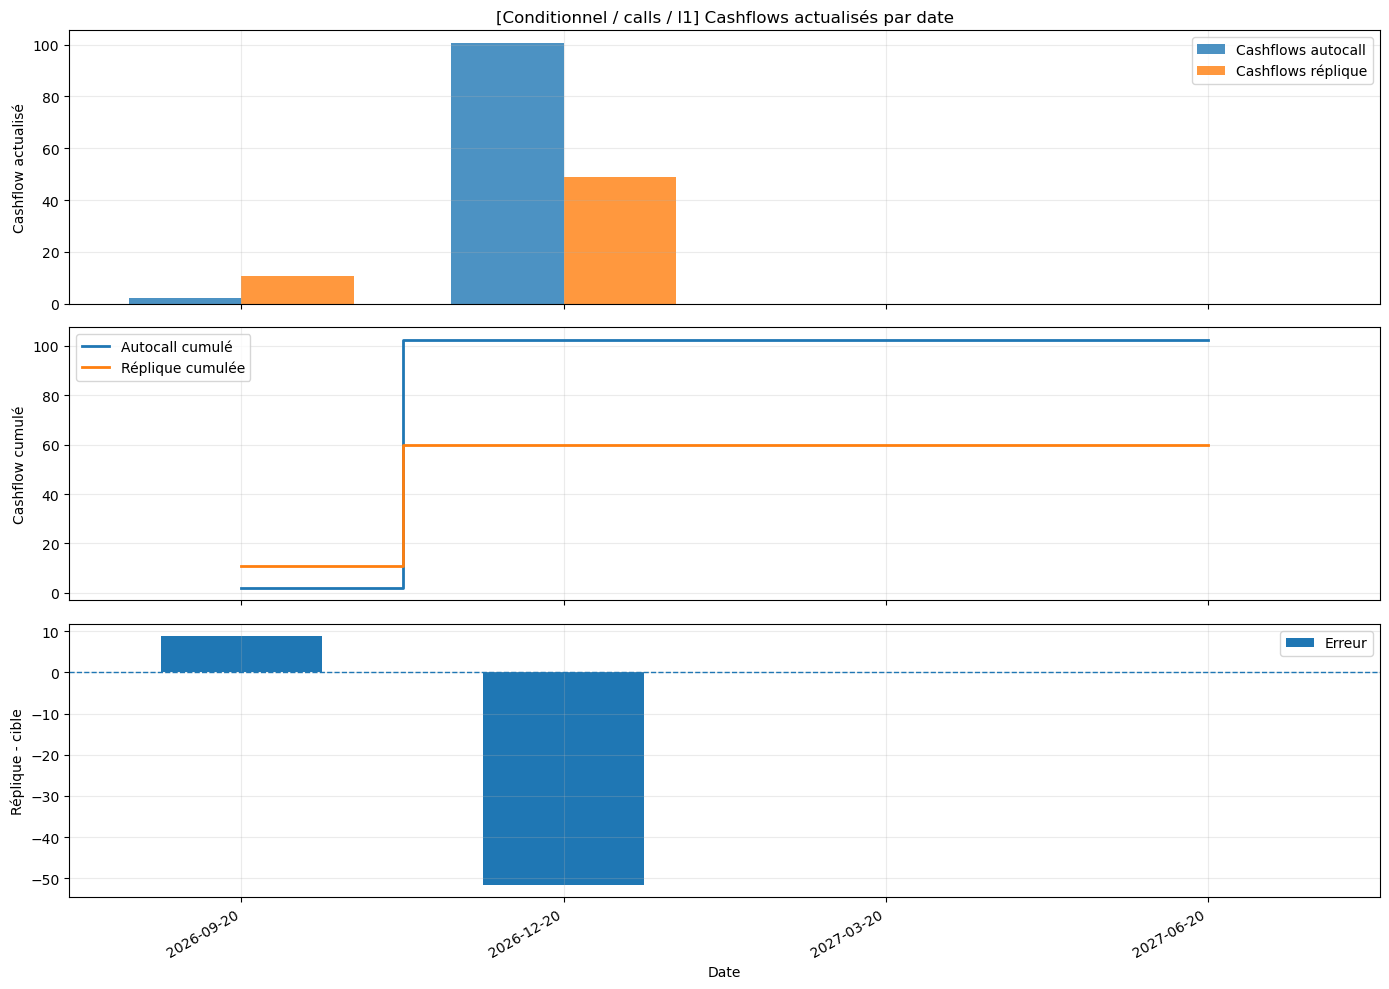

Métriques globales train :


mae               3.656501
rmse              9.538552
max_abs_error    55.188520
mean_error        0.000028
dtype: float64

Métriques globales test :


mae               3.731050
rmse              9.533628
max_abs_error    52.703261
mean_error       -0.059130
dtype: float64

Métriques train sur les paths vivants :


...

,date,n_test,n_alive,mae,rmse,max_abs_error,mean_error,mae_alive,rmse_alive,max_abs_error_alive,mean_error_alive
0,2026-09-20,600,600,9.248084,15.369150,50.818913,-0.448175,9.248084,15.369150,50.818913,-0.448175
1,2026-12-20,600,312,3.512884,8.956211,52.703261,-0.440710,6.755546,12.420030,52.703261,-0.847520
2,2027-03-20,600,226,1.834451,6.745832,49.385953,0.604103,4.870225,10.991499,49.385953,1.603814
3,2027-06-20,600,176,0.328778,1.276524,12.862595,0.048263,1.120835,2.356938,12.862595,0.164532


États du path affiché :


,date,alive_before,barrier_hit
0,2026-09-20,True,False
1,2026-12-20,True,False
2,2027-03-20,False,False
3,2027-06-20,False,False


Paniers conditionnels :


,date,state,n_train_paths,name,kind,maturity_date,strike,weight,absolute_weight
0,2026-09-20,alive,1400,C_20260920_105.00,EuropeanCall,2026-09-20,105.0,-17.363190,17.363190
1,2026-09-20,alive,1400,C_20260920_95.00,EuropeanCall,2026-09-20,95.0,17.051961,17.051961
2,2026-09-20,alive,1400,C_20260920_90.00,EuropeanCall,2026-09-20,90.0,-5.404077,5.404077
3,2026-09-20,alive,1400,C_20260920_110.00,EuropeanCall,2026-09-20,110.0,5.337060,5.337060
4,2026-09-20,alive,1400,C_20260920_115.00,EuropeanCall,2026-09-20,115.0,-1.753228,1.753228
5,2026-09-20,alive,1400,C_20260920_85.00,EuropeanCall,2026-09-20,85.0,1.484233,1.484233
6,2026-09-20,alive,1400,C_20260920_80.00,EuropeanCall,2026-09-20,80.0,-0.721918,0.721918
7,2026-09-20,alive,1400,C_20260920_75.00,EuropeanCall,2026-09-20,75.0,0.687300,0.687300
8,2026-09-20,alive,1400,C_20260920_120.00,EuropeanCall,2026-09-20,120.0,0.627861,0.627861
9,2026-09-20,alive,1400,C_20260920_100.00,EuropeanCall,2026-09-20,100.0,0.432097,0.432097


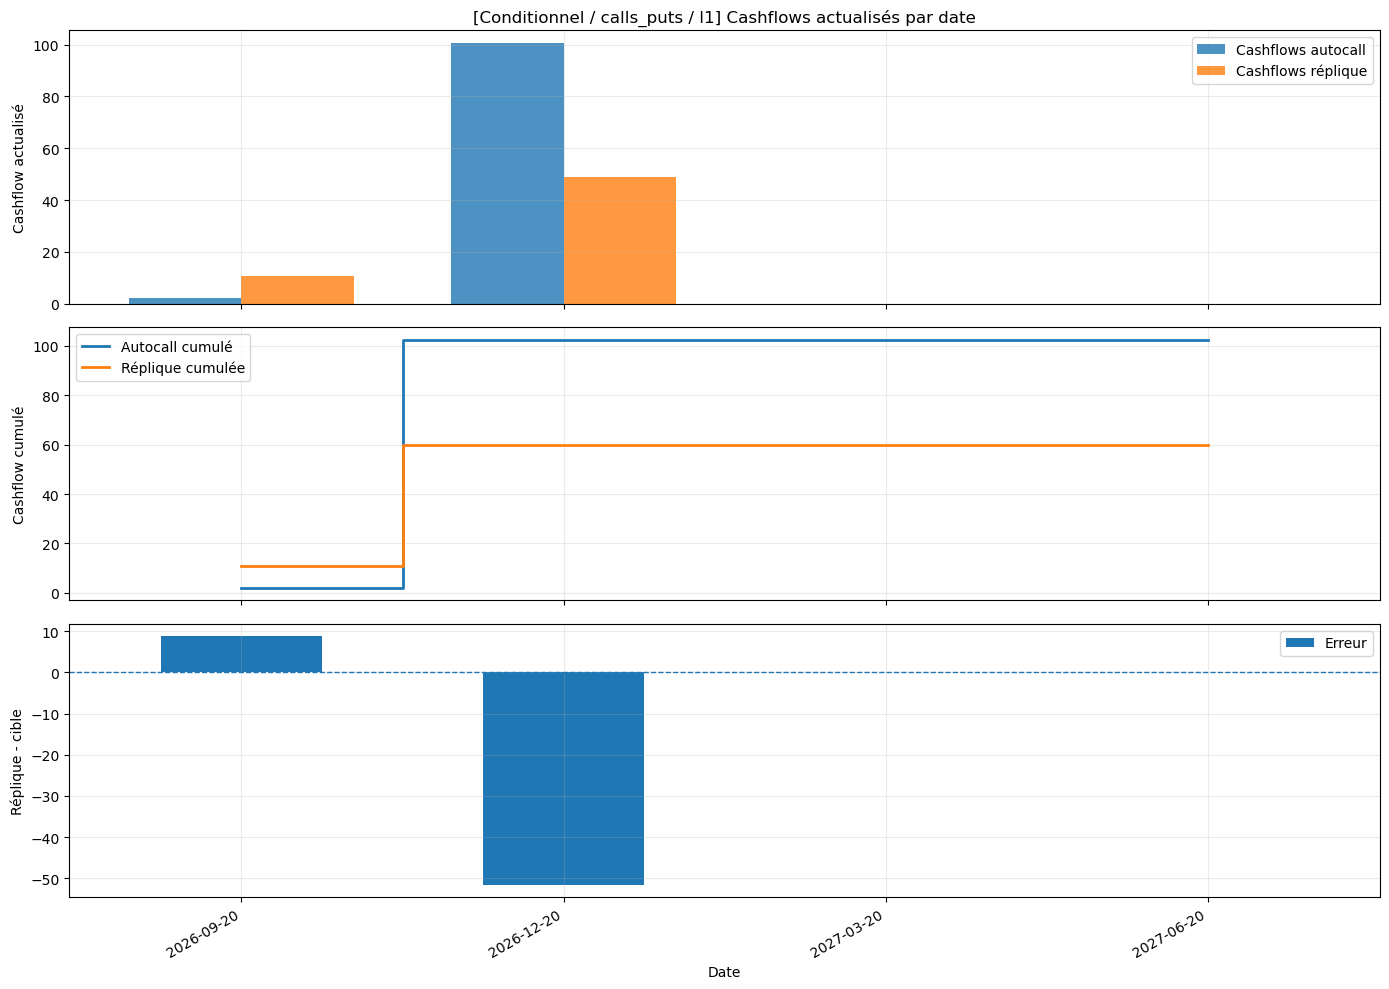

Métriques globales train :


mae               3.589221
rmse              9.516478
max_abs_error    55.191498
mean_error       -0.000016
dtype: float64

Métriques globales test :


mae               3.659308
rmse              9.512592
max_abs_error    52.706050
mean_error       -0.070148
dtype: float64

Métriques train sur les paths vivants :


...

,date,n_test,n_alive,mae,rmse,max_abs_error,mean_error,mae_alive,rmse_alive,max_abs_error_alive,mean_error_alive
0,2026-09-20,600,600,9.249129,15.369228,50.823142,-0.448430,9.249129,15.369228,50.823142,-0.448430
1,2026-12-20,600,312,3.512771,8.956309,52.706050,-0.440506,6.755329,12.420166,52.706050,-0.847128
2,2027-03-20,600,226,1.832821,6.745746,49.391178,0.603265,4.865897,10.991359,49.391178,1.601588
3,2027-06-20,600,176,0.042511,0.154586,1.099362,0.005079,0.144923,0.285423,1.099362,0.017315


États du path affiché :


,date,alive_before,barrier_hit
0,2026-09-20,True,False
1,2026-12-20,True,False
2,2027-03-20,False,False
3,2027-06-20,False,False


Paniers conditionnels :


,date,state,n_train_paths,name,kind,maturity_date,strike,weight,absolute_weight
0,2026-09-20,alive,1400,P_20260920_95.00,EuropeanPut,2026-09-20,95.0,13.956997,13.956997
1,2026-09-20,alive,1400,C_20260920_105.00,EuropeanCall,2026-09-20,105.0,-10.825644,10.825644
2,2026-09-20,alive,1400,P_20260920_105.00,EuropeanPut,2026-09-20,105.0,-6.540390,6.540390
3,2026-09-20,alive,1400,P_20260920_90.00,EuropeanPut,2026-09-20,90.0,-5.767364,5.767364
4,2026-09-20,alive,1400,C_20260920_110.00,EuropeanCall,2026-09-20,110.0,5.351660,5.351660
5,2026-09-20,alive,1400,C_20260920_95.00,EuropeanCall,2026-09-20,95.0,3.096249,3.096249
6,2026-09-20,alive,1400,C_20260920_115.00,EuropeanCall,2026-09-20,115.0,-1.229672,1.229672
7,2026-09-20,alive,1400,C_20260920_100.00,EuropeanCall,2026-09-20,100.0,1.162637,1.162637
8,2026-09-20,alive,1400,P_20260920_85.00,EuropeanPut,2026-09-20,85.0,1.105317,1.105317
9,2026-09-20,alive,1400,P_20260920_80.00,EuropeanPut,2026-09-20,80.0,-0.984043,0.984043


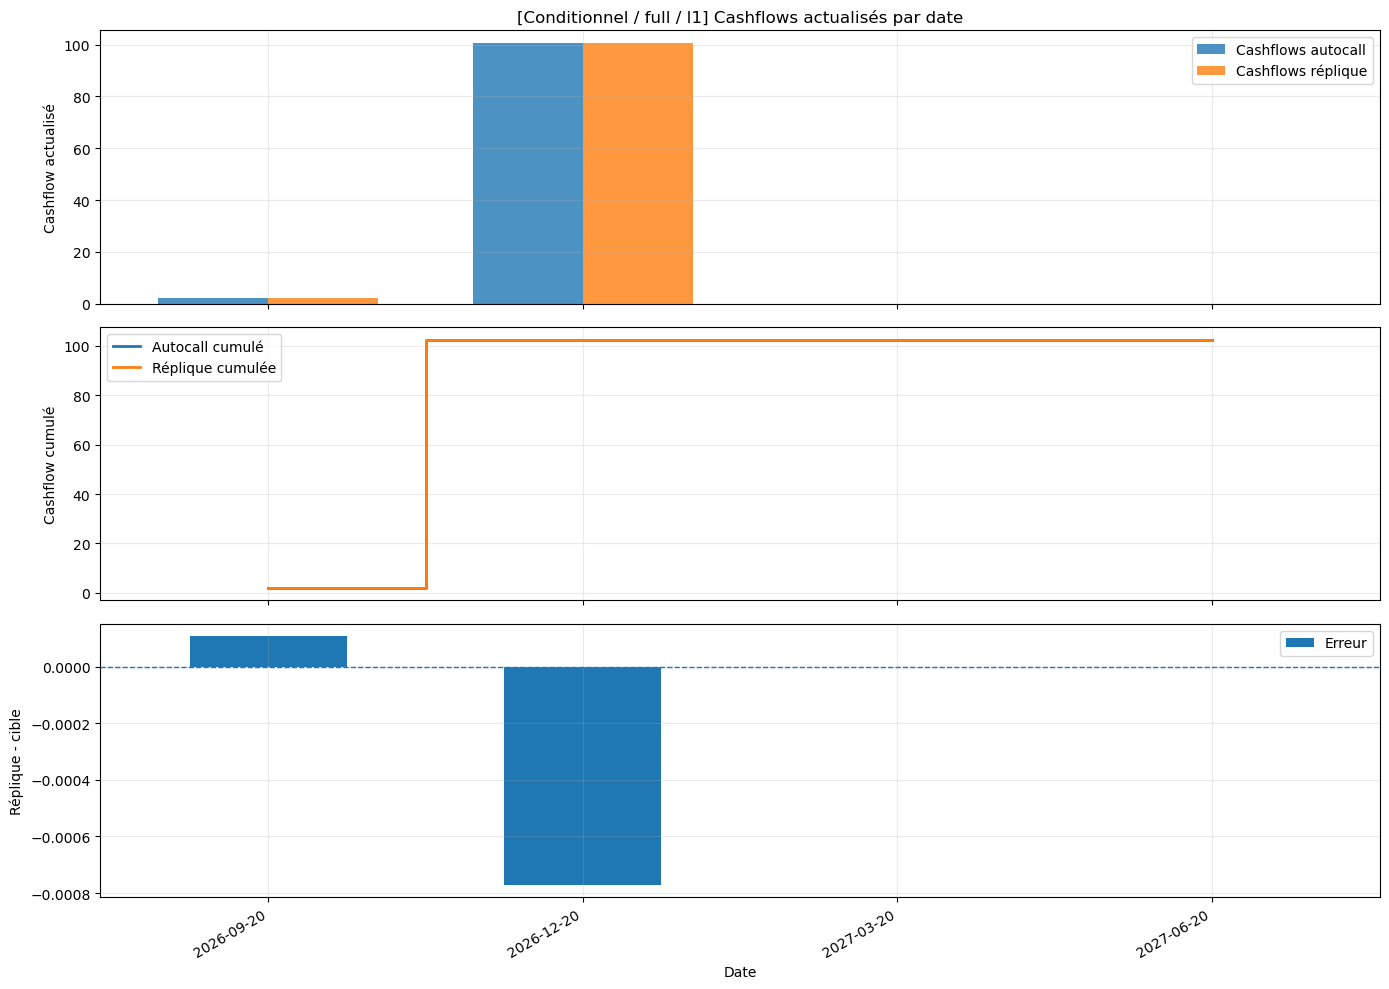

Métriques globales train :


mae              0.000099
rmse             0.000354
max_abs_error    0.013742
mean_error       0.000004
dtype: float64

Métriques globales test :


mae              0.000112
rmse             0.000560
max_abs_error    0.022690
mean_error      -0.000020
dtype: float64

Métriques train sur les paths vivants :


...

,date,n_test,n_alive,mae,rmse,max_abs_error,mean_error,mae_alive,rmse_alive,max_abs_error_alive,mean_error_alive
0,2026-09-20,600,600,0.000076,0.000128,0.000821,0.000007,0.000076,0.000128,0.000821,0.000007
1,2026-12-20,600,312,0.000149,0.000264,0.000774,-0.000038,0.000287,0.000367,0.000774,-0.000074
2,2027-03-20,600,226,0.000047,0.000106,0.000437,-0.000005,0.000125,0.000173,0.000437,-0.000014
3,2027-06-20,600,176,0.000176,0.001076,0.022690,-0.000044,0.000601,0.001986,0.022690,-0.000151


États du path affiché :


,date,alive_before,barrier_hit
0,2026-09-20,True,False
1,2026-12-20,True,False
2,2027-03-20,False,False
3,2027-06-20,False,False


Paniers conditionnels :


,date,state,n_train_paths,name,kind,maturity_date,strike,weight,absolute_weight
0,2026-09-20,alive,1400,BP_20260920_100.00,BinaryPut,2026-09-20,100.0,-5.249455e+01,5.249455e+01
1,2026-09-20,alive,1400,BC_20260920_100.00,BinaryCall,2026-09-20,100.0,4.750515e+01,4.750515e+01
2,2026-09-20,alive,1400,BP_20260920_80.00,BinaryPut,2026-09-20,80.0,-1.934557e+00,1.934557e+00
3,2026-09-20,alive,1400,CASH_20260920,Cash,2026-09-20,0.0,5.443037e-01,5.443037e-01
4,2026-09-20,alive,1400,BC_20260920_80.00,BinaryCall,2026-09-20,80.0,6.442172e-02,6.442172e-02
5,2026-09-20,alive,1400,BP_20260920_75.00,BinaryPut,2026-09-20,75.0,-4.816804e-05,4.816804e-05
6,2026-09-20,alive,1400,P_20260920_80.00,EuropeanPut,2026-09-20,80.0,-1.863185e-05,1.863185e-05
7,2026-09-20,alive,1400,P_20260920_105.00,EuropeanPut,2026-09-20,105.0,-1.653588e-05,1.653588e-05
8,2026-09-20,alive,1400,BP_20260920_70.00,BinaryPut,2026-09-20,70.0,1.333647e-05,1.333647e-05
9,2026-09-20,alive,1400,P_20260920_70.00,EuropeanPut,2026-09-20,70.0,6.033241e-06,6.033241e-06


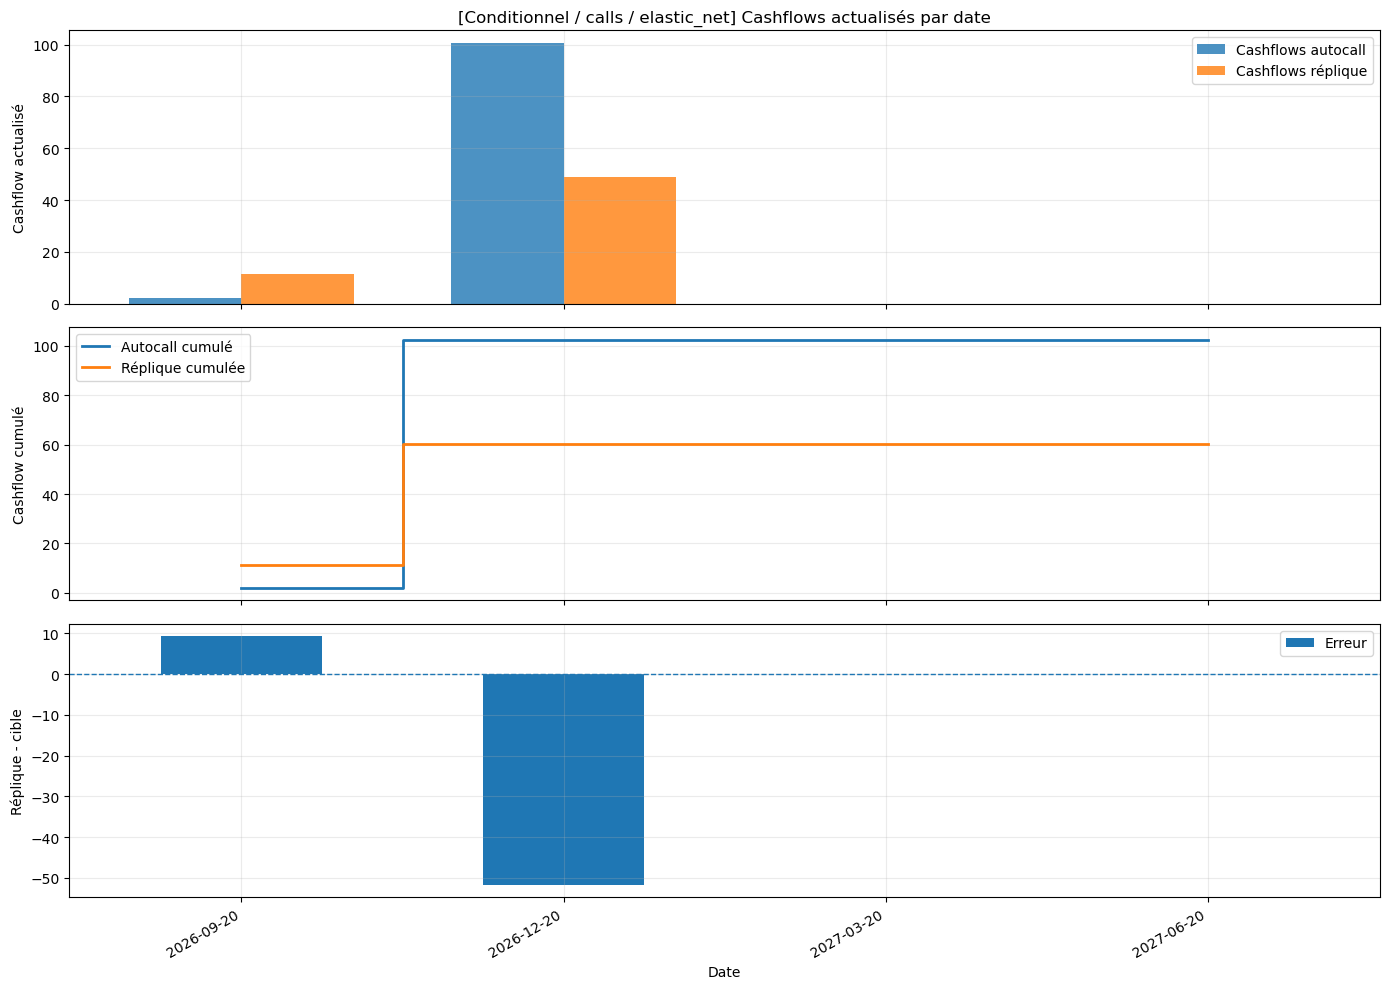

Métriques globales train :


mae               3.623914
rmse              9.540962
max_abs_error    55.285506
mean_error        0.000020
dtype: float64

Métriques globales test :


mae               3.691868
rmse              9.528702
max_abs_error    52.804571
mean_error       -0.054437
dtype: float64

Métriques train sur les paths vivants :


...

,date,n_test,n_alive,mae,rmse,max_abs_error,mean_error,mae_alive,rmse_alive,max_abs_error_alive,mean_error_alive
0,2026-09-20,600,600,9.135637,15.358162,51.205998,-0.428275,9.135637,15.358162,51.205998,-0.428275
1,2026-12-20,600,312,3.490171,8.961520,52.804571,-0.444115,6.711867,12.427392,52.804571,-0.854067
2,2027-03-20,600,226,1.812940,6.735907,49.292464,0.605767,4.813116,10.975327,49.292464,1.608232
3,2027-06-20,600,176,0.328726,1.276794,12.868203,0.048875,1.120655,2.357436,12.868203,0.166618


États du path affiché :


,date,alive_before,barrier_hit
0,2026-09-20,True,False
1,2026-12-20,True,False
2,2027-03-20,False,False
3,2027-06-20,False,False


Paniers conditionnels :


,date,state,n_train_paths,name,kind,maturity_date,strike,weight,absolute_weight
0,2026-09-20,alive,1400,C_20260920_105.00,EuropeanCall,2026-09-20,105.0,-17.344313,17.344313
1,2026-09-20,alive,1400,C_20260920_95.00,EuropeanCall,2026-09-20,95.0,16.299745,16.299745
2,2026-09-20,alive,1400,C_20260920_110.00,EuropeanCall,2026-09-20,110.0,5.196056,5.196056
3,2026-09-20,alive,1400,C_20260920_90.00,EuropeanCall,2026-09-20,90.0,-4.539948,4.539948
4,2026-09-20,alive,1400,C_20260920_115.00,EuropeanCall,2026-09-20,115.0,-1.650089,1.650089
5,2026-09-20,alive,1400,C_20260920_100.00,EuropeanCall,2026-09-20,100.0,0.781501,0.781501
6,2026-09-20,alive,1400,C_20260920_85.00,EuropeanCall,2026-09-20,85.0,0.781454,0.781454
7,2026-09-20,alive,1400,C_20260920_120.00,EuropeanCall,2026-09-20,120.0,0.592992,0.592992
8,2026-09-20,alive,1400,C_20260920_75.00,EuropeanCall,2026-09-20,75.0,0.326696,0.326696
9,2026-09-20,alive,1400,C_20260920_125.00,EuropeanCall,2026-09-20,125.0,-0.252036,0.252036


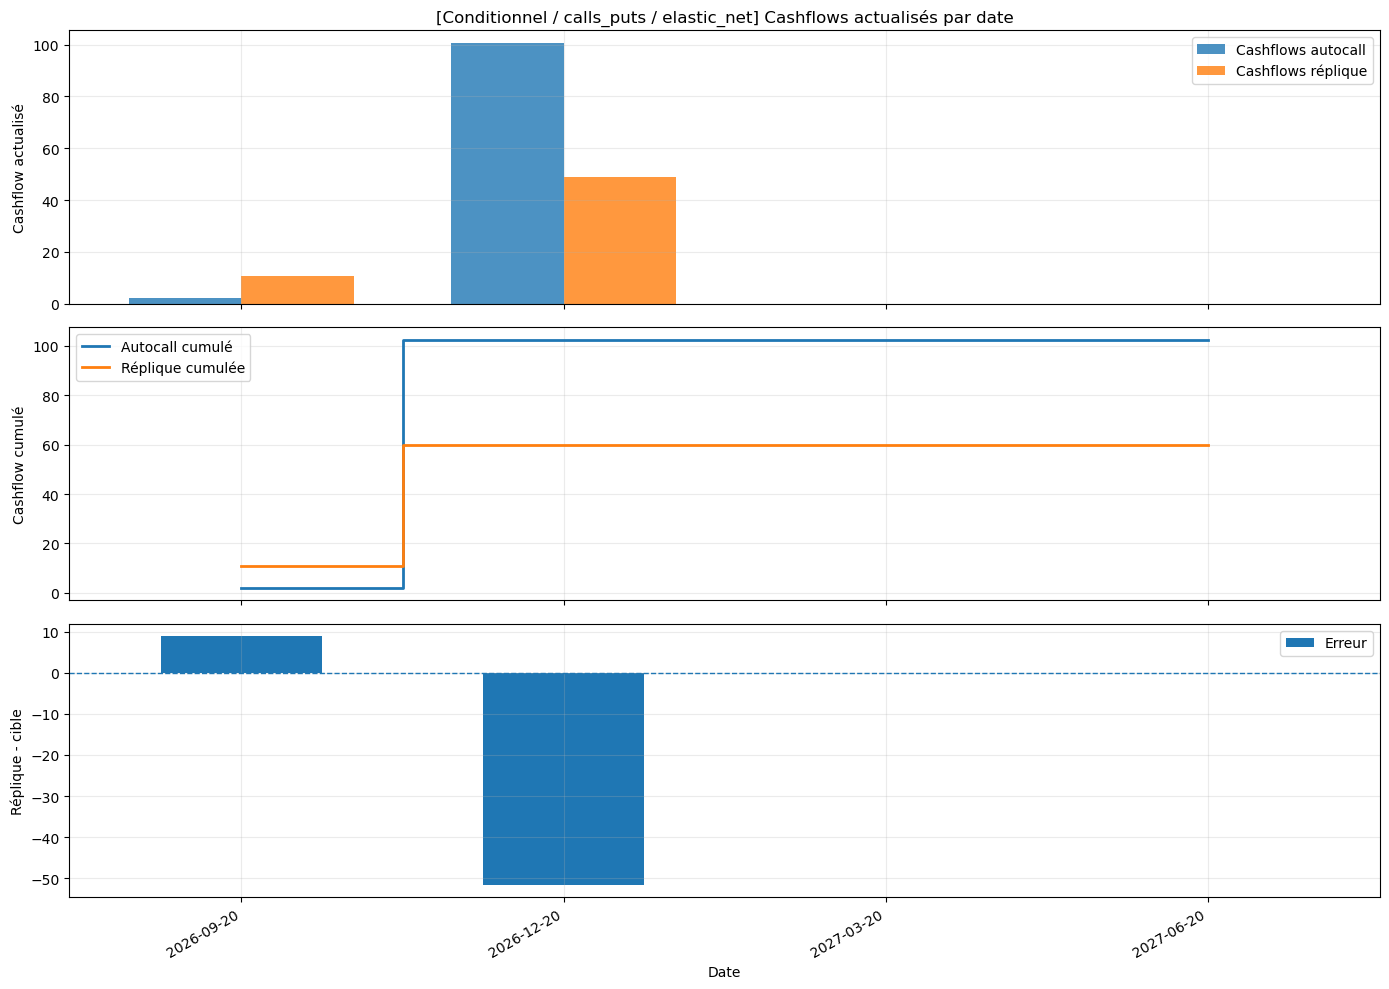

Métriques globales train :


mae               3.578263
rmse              9.516622
max_abs_error    55.188842
mean_error       -0.000008
dtype: float64

Métriques globales test :


mae               3.646415
rmse              9.511358
max_abs_error    52.710673
mean_error       -0.069338
dtype: float64

Métriques train sur les paths vivants :


...

,date,n_test,n_alive,mae,rmse,max_abs_error,mean_error,mae_alive,rmse_alive,max_abs_error_alive,mean_error_alive
0,2026-09-20,600,600,9.224116,15.367868,50.795278,-0.445999,9.224116,15.367868,50.795278,-0.445999
1,2026-12-20,600,312,3.501297,8.958073,52.710673,-0.441912,6.733263,12.422612,52.710673,-0.849830
2,2027-03-20,600,226,1.817621,6.739537,49.350984,0.605481,4.825543,10.981242,49.350984,1.607471
3,2027-06-20,600,176,0.042627,0.154555,1.104051,0.005077,0.145320,0.285367,1.104051,0.017309


États du path affiché :


,date,alive_before,barrier_hit
0,2026-09-20,True,False
1,2026-12-20,True,False
2,2027-03-20,False,False
3,2027-06-20,False,False


Paniers conditionnels :


,date,state,n_train_paths,name,kind,maturity_date,strike,weight,absolute_weight
0,2026-09-20,alive,1400,P_20260920_95.00,EuropeanPut,2026-09-20,95.0,13.900779,13.900779
1,2026-09-20,alive,1400,C_20260920_105.00,EuropeanCall,2026-09-20,105.0,-10.754229,10.754229
2,2026-09-20,alive,1400,P_20260920_105.00,EuropeanPut,2026-09-20,105.0,-6.507804,6.507804
3,2026-09-20,alive,1400,P_20260920_90.00,EuropeanPut,2026-09-20,90.0,-5.687772,5.687772
4,2026-09-20,alive,1400,C_20260920_110.00,EuropeanCall,2026-09-20,110.0,5.250755,5.250755
5,2026-09-20,alive,1400,C_20260920_95.00,EuropeanCall,2026-09-20,95.0,3.088039,3.088039
6,2026-09-20,alive,1400,C_20260920_115.00,EuropeanCall,2026-09-20,115.0,-1.161624,1.161624
7,2026-09-20,alive,1400,C_20260920_100.00,EuropeanCall,2026-09-20,100.0,1.154167,1.154167
8,2026-09-20,alive,1400,P_20260920_85.00,EuropeanPut,2026-09-20,85.0,1.059268,1.059268
9,2026-09-20,alive,1400,P_20260920_80.00,EuropeanPut,2026-09-20,80.0,-0.969356,0.969356


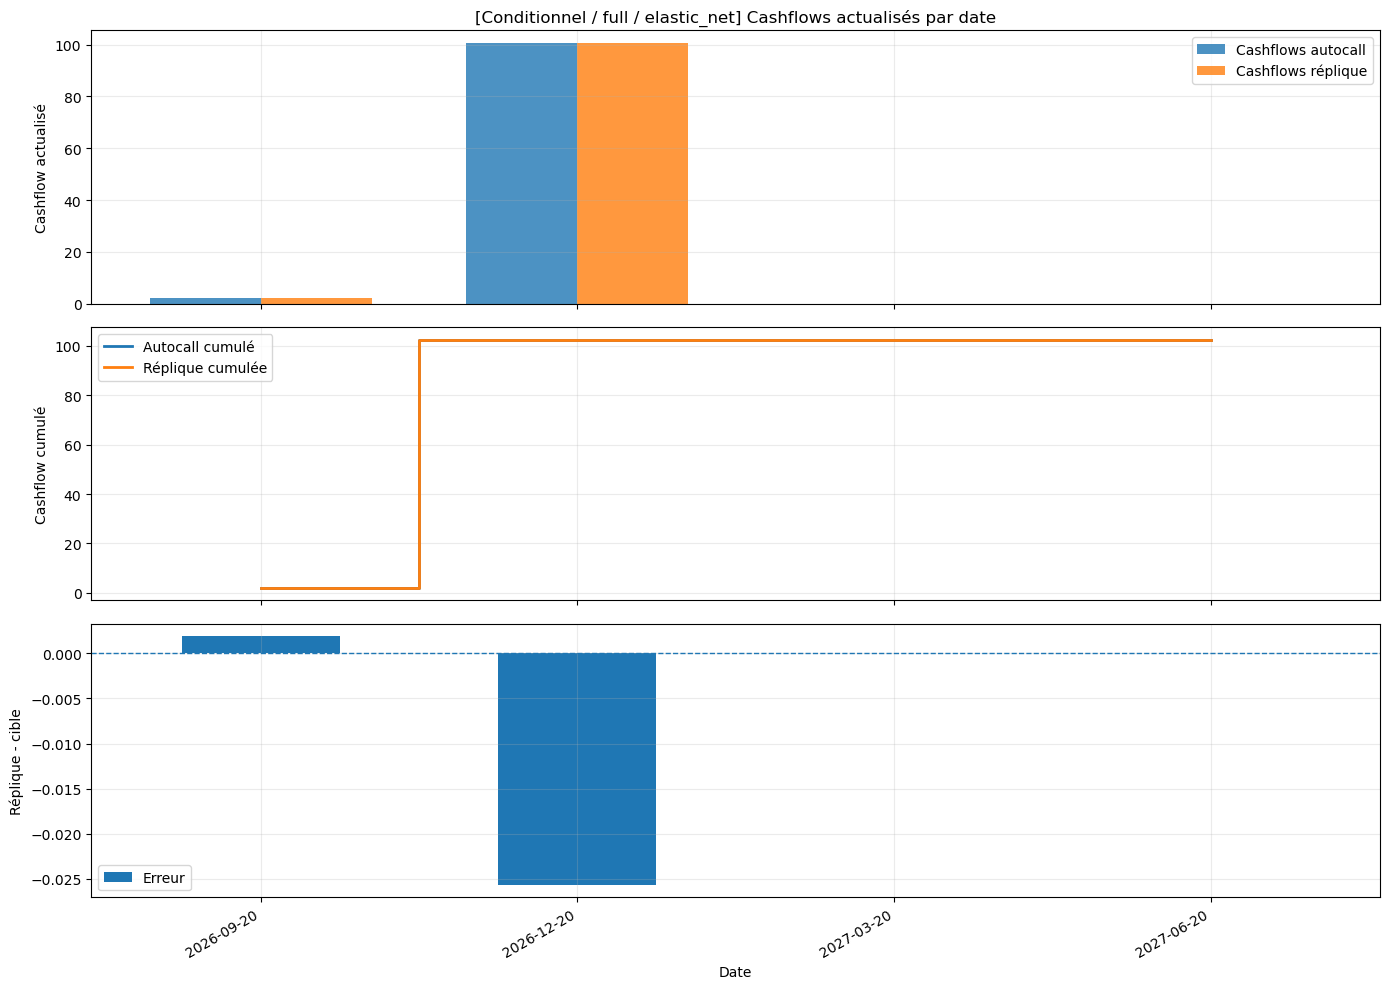

Métriques globales train :


mae              0.001613
rmse             0.004777
max_abs_error    0.027622
mean_error      -0.000003
dtype: float64

Métriques globales test :


mae              0.001655
rmse             0.004802
max_abs_error    0.029054
mean_error      -0.000025
dtype: float64

Métriques train sur les paths vivants :


...

,date,n_test,n_alive,mae,rmse,max_abs_error,mean_error,mae_alive,rmse_alive,max_abs_error_alive,mean_error_alive
0,2026-09-20,600,600,0.003890,0.007680,0.026486,-0.000070,0.003890,0.007680,0.026486,-0.000070
1,2026-12-20,600,312,0.001558,0.004319,0.026296,-0.000192,0.002995,0.005989,0.026296,-0.000370
2,2027-03-20,600,226,0.001010,0.003611,0.026778,0.000196,0.002680,0.005884,0.026778,0.000521
3,2027-06-20,600,176,0.000164,0.001251,0.029054,-0.000035,0.000559,0.002309,0.029054,-0.000119


États du path affiché :


,date,alive_before,barrier_hit
0,2026-09-20,True,False
1,2026-12-20,True,False
2,2027-03-20,False,False
3,2027-06-20,False,False


Paniers conditionnels :


,date,state,n_train_paths,name,kind,maturity_date,strike,weight,absolute_weight
0,2026-09-20,alive,1400,BP_20260920_100.00,BinaryPut,2026-09-20,100.0,-52.467004,52.467004
1,2026-09-20,alive,1400,BC_20260920_100.00,BinaryCall,2026-09-20,100.0,47.479405,47.479405
2,2026-09-20,alive,1400,BP_20260920_80.00,BinaryPut,2026-09-20,80.0,-1.943380,1.943380
3,2026-09-20,alive,1400,CASH_20260920,Cash,2026-09-20,0.0,0.544505,0.544505
4,2026-09-20,alive,1400,BC_20260920_80.00,BinaryCall,2026-09-20,80.0,0.056583,0.056583
5,2026-09-20,alive,1400,BP_20260920_95.00,BinaryPut,2026-09-20,95.0,0.013200,0.013200
6,2026-09-20,alive,1400,BC_20260920_105.00,BinaryCall,2026-09-20,105.0,-0.010820,0.010820
7,2026-09-20,alive,1400,P_20260920_95.00,EuropeanPut,2026-09-20,95.0,0.005715,0.005715
8,2026-09-20,alive,1400,P_20260920_105.00,EuropeanPut,2026-09-20,105.0,-0.003739,0.003739
9,2026-09-20,alive,1400,C_20260920_105.00,EuropeanCall,2026-09-20,105.0,-0.003039,0.003039


In [85]:
# ============================================================
# EXÉCUTION DU BENCHMARK CONDITIONNEL
# ============================================================

# Path réellement hors échantillon.
test_path = simulate_gbm_path(spot0=spot0,start_date=pd.Timestamp(valuation_date),end_date=pd.Timestamp(maturity_date),rate=rate,dividend_yield=dividend_yield,vol=vol,seed=95020)

for penalty in ["l2", "l1", "elastic_net"]:
    for family in ["calls", "calls_puts", "full"]:
    
        res_conditional = run_conditional_benchmark_curve(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family=family,n_paths=2000,penalty=penalty,alpha=1e-4,train_frac=0.7,seed=42,split_final_by_barrier=True,min_state_paths=20)

        (target_conditional_curve,replica_conditional_curve,state_conditional_curve) = conditional_portfolio_value_curve_on_path(result=res_conditional,product=prod,path=test_path,valuation_date=valuation_date,rate=rate)

        plot_timewise_curve_benchmark(target_conditional_curve.index,target_conditional_curve.to_numpy(),replica_conditional_curve.to_numpy(),title_prefix=f"[Conditionnel / {family} / {penalty}] ")

        print("Métriques globales train :")
        display(pd.Series(res_conditional["metrics_train"]))

        print("Métriques globales test :")
        display(pd.Series(res_conditional["metrics_test"]))

        print("Métriques train sur les paths vivants :")
        display(pd.Series(res_conditional["metrics_train_alive"]))

        print("Métriques test sur les paths vivants :")
        display(pd.Series(res_conditional["metrics_test_alive"]))

        print("Métriques test par date :")
        display(res_conditional["metrics_by_date"])

        print("États du path affiché :")
        display(state_conditional_curve)

        print("Paniers conditionnels :")
        display(res_conditional["weights"].head(50))

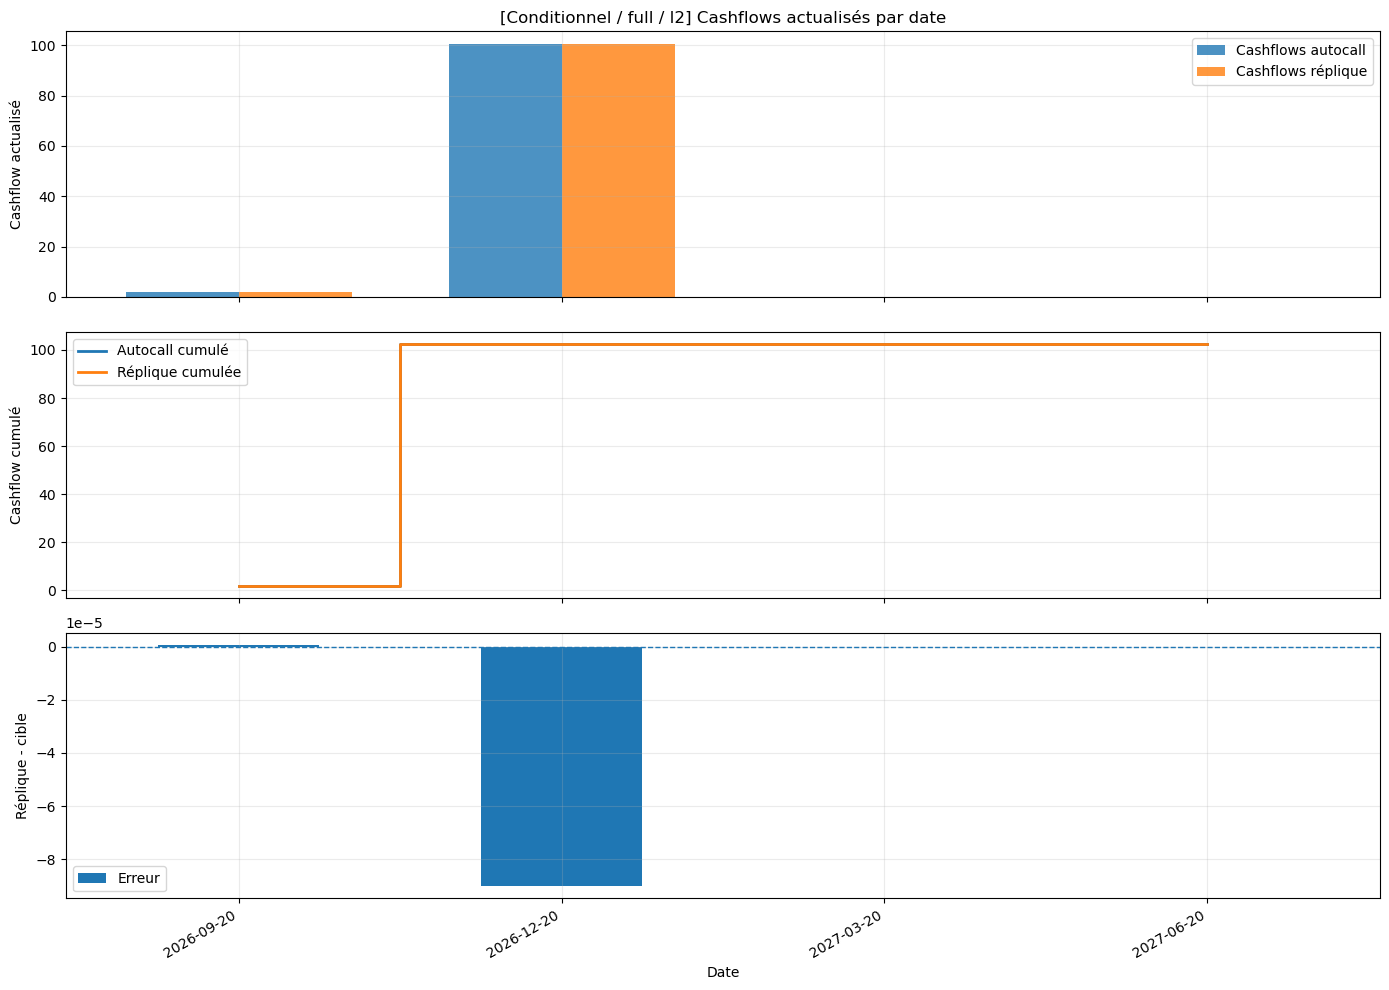

Métriques globales train :


mae              2.271608e-01
rmse             1.531531e+00
max_abs_error    2.272426e+01
mean_error      -2.230343e-13
dtype: float64

Métriques globales test :


mae               0.206596
rmse              1.398237
max_abs_error    17.393793
mean_error        0.017727
dtype: float64

Métriques train sur les paths vivants :


...

,date,n_test,n_alive,mae,rmse,max_abs_error,mean_error,mae_alive,rmse_alive,max_abs_error_alive,mean_error_alive
0,2026-09-20,600,600,0.000006,0.000012,0.000043,-1.941295e-07,0.000006,0.000012,0.000043,-1.941295e-07
1,2026-12-20,600,312,0.000005,0.000015,0.000092,-5.754647e-07,0.000009,0.000020,0.000092,-1.106663e-06
2,2027-03-20,600,226,0.000004,0.000017,0.000131,8.830350e-07,0.000010,0.000028,0.000131,2.344341e-06
3,2027-06-20,600,176,0.826371,2.796474,17.393793,7.090632e-02,2.817172,5.163332,17.393793,2.417261e-01


États du path affiché :


,date,alive_before,barrier_hit
0,2026-09-20,True,False
1,2026-12-20,True,False
2,2027-03-20,False,False
3,2027-06-20,False,False


Paniers conditionnels :


,date,state,n_train_paths,name,kind,maturity_date,strike,weight,absolute_weight
0,2026-09-20,alive,1400,BP_20260920_100.00,BinaryPut,2026-09-20,100.0,-5.249995e+01,5.249995e+01
1,2026-09-20,alive,1400,BC_20260920_100.00,BinaryCall,2026-09-20,100.0,4.749996e+01,4.749996e+01
2,2026-09-20,alive,1400,BP_20260920_80.00,BinaryPut,2026-09-20,80.0,-1.935707e+00,1.935707e+00
3,2026-09-20,alive,1400,CASH_20260920,Cash,2026-09-20,0.0,5.443549e-01,5.443549e-01
4,2026-09-20,alive,1400,BC_20260920_80.00,BinaryCall,2026-09-20,80.0,6.429223e-02,6.429223e-02
5,2026-09-20,alive,1400,BP_20260920_105.00,BinaryPut,2026-09-20,105.0,3.873612e-05,3.873612e-05
6,2026-09-20,alive,1400,BP_20260920_125.00,BinaryPut,2026-09-20,125.0,3.585363e-05,3.585363e-05
7,2026-09-20,alive,1400,BC_20260920_125.00,BinaryCall,2026-09-20,125.0,3.585359e-05,3.585359e-05
8,2026-09-20,alive,1400,BP_20260920_95.00,BinaryPut,2026-09-20,95.0,3.555194e-05,3.555194e-05
9,2026-09-20,alive,1400,BP_20260920_110.00,BinaryPut,2026-09-20,110.0,3.023485e-05,3.023485e-05


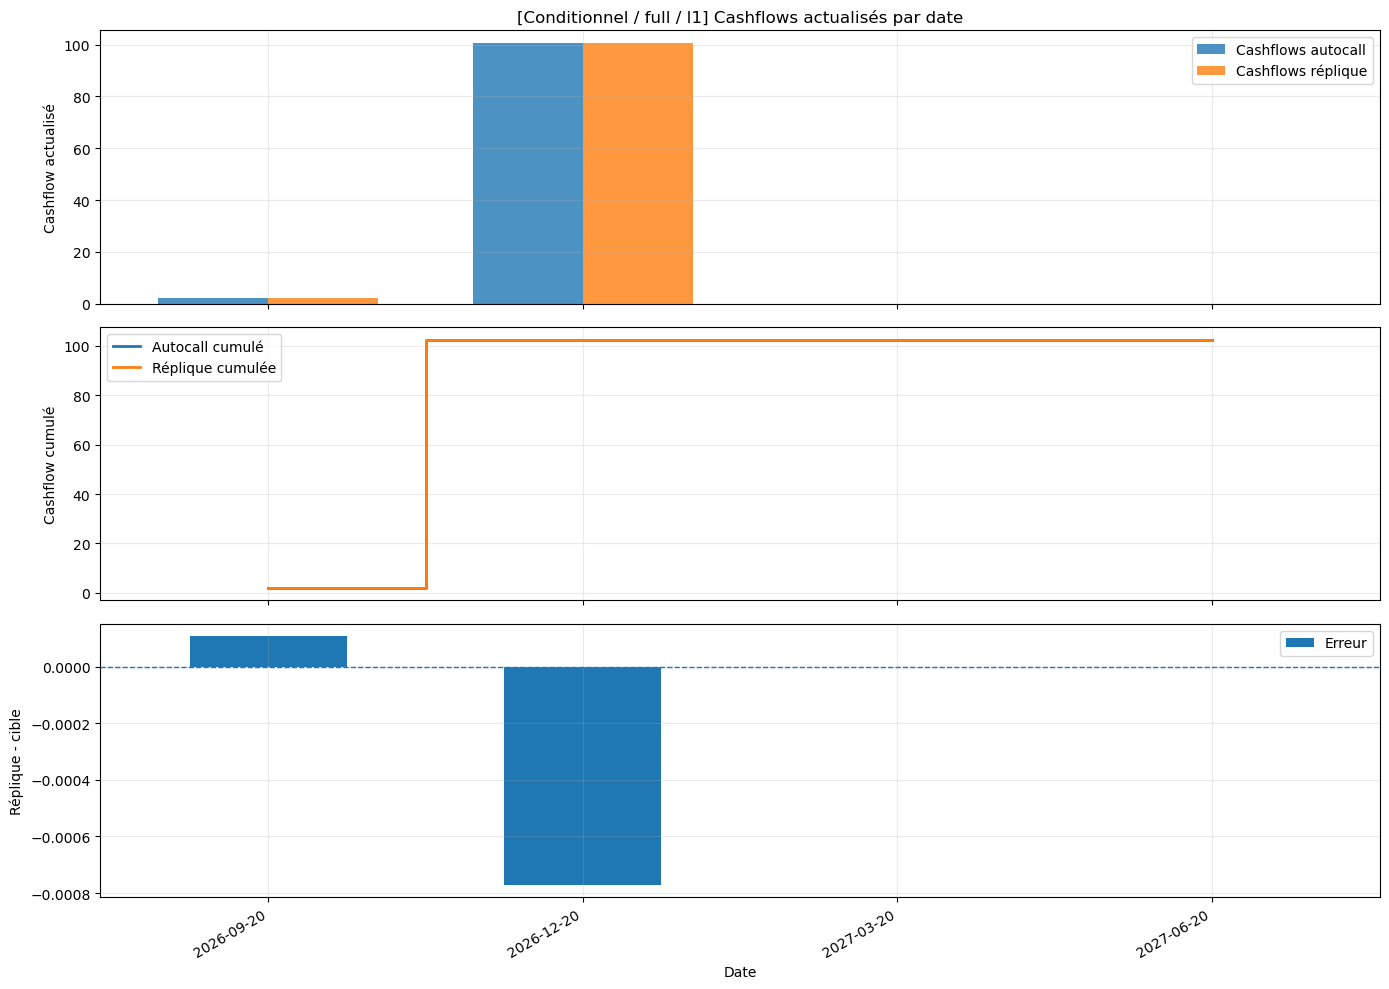

Métriques globales train :


mae               0.227230
rmse              1.531531
max_abs_error    22.724117
mean_error        0.000006
dtype: float64

Métriques globales test :


mae               0.206671
rmse              1.398242
max_abs_error    17.394462
mean_error        0.017718
dtype: float64

Métriques train sur les paths vivants :


...

,date,n_test,n_alive,mae,rmse,max_abs_error,mean_error,mae_alive,rmse_alive,max_abs_error_alive,mean_error_alive
0,2026-09-20,600,600,0.000076,0.000128,0.000821,0.000007,0.000076,0.000128,0.000821,0.000007
1,2026-12-20,600,312,0.000149,0.000264,0.000774,-0.000038,0.000287,0.000367,0.000774,-0.000074
2,2027-03-20,600,226,0.000047,0.000106,0.000437,-0.000005,0.000125,0.000173,0.000437,-0.000014
3,2027-06-20,600,176,0.826414,2.796485,17.394462,0.070906,2.817319,5.163352,17.394462,0.241726


États du path affiché :


,date,alive_before,barrier_hit
0,2026-09-20,True,False
1,2026-12-20,True,False
2,2027-03-20,False,False
3,2027-06-20,False,False


Paniers conditionnels :


,date,state,n_train_paths,name,kind,maturity_date,strike,weight,absolute_weight
0,2026-09-20,alive,1400,BP_20260920_100.00,BinaryPut,2026-09-20,100.0,-5.249455e+01,5.249455e+01
1,2026-09-20,alive,1400,BC_20260920_100.00,BinaryCall,2026-09-20,100.0,4.750515e+01,4.750515e+01
2,2026-09-20,alive,1400,BP_20260920_80.00,BinaryPut,2026-09-20,80.0,-1.934557e+00,1.934557e+00
3,2026-09-20,alive,1400,CASH_20260920,Cash,2026-09-20,0.0,5.443037e-01,5.443037e-01
4,2026-09-20,alive,1400,BC_20260920_80.00,BinaryCall,2026-09-20,80.0,6.442172e-02,6.442172e-02
5,2026-09-20,alive,1400,BP_20260920_75.00,BinaryPut,2026-09-20,75.0,-4.816804e-05,4.816804e-05
6,2026-09-20,alive,1400,P_20260920_80.00,EuropeanPut,2026-09-20,80.0,-1.863185e-05,1.863185e-05
7,2026-09-20,alive,1400,P_20260920_105.00,EuropeanPut,2026-09-20,105.0,-1.653588e-05,1.653588e-05
8,2026-09-20,alive,1400,BP_20260920_70.00,BinaryPut,2026-09-20,70.0,1.333647e-05,1.333647e-05
9,2026-09-20,alive,1400,P_20260920_70.00,EuropeanPut,2026-09-20,70.0,6.033241e-06,6.033241e-06


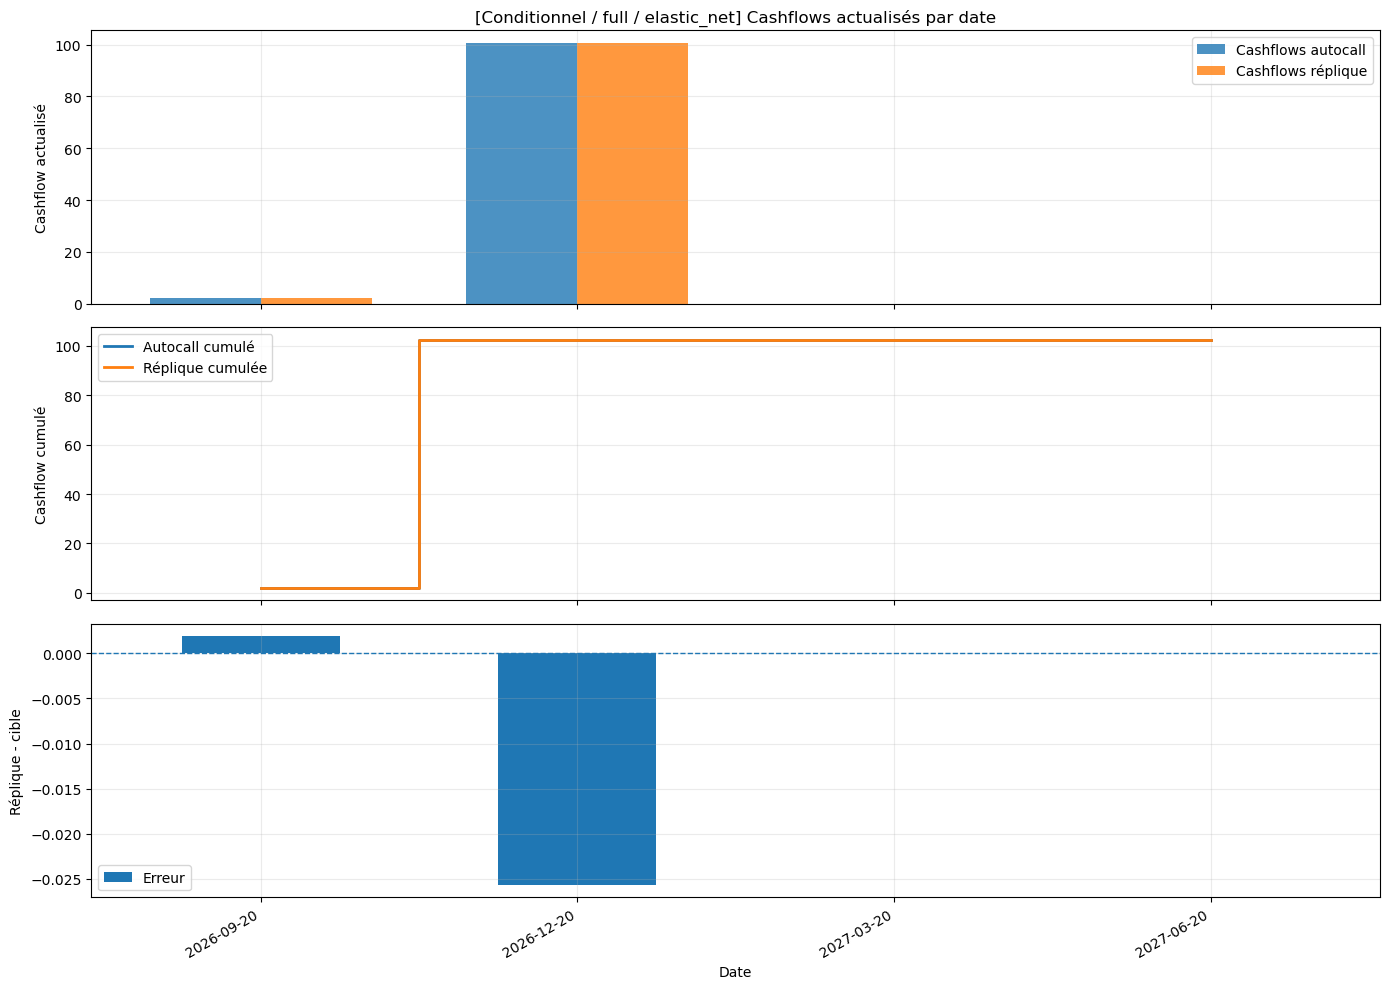

Métriques globales train :


mae               0.228894
rmse              1.531558
max_abs_error    22.681083
mean_error        0.000001
dtype: float64

Métriques globales test :


mae               0.208085
rmse              1.397752
max_abs_error    17.289488
mean_error        0.018090
dtype: float64

Métriques train sur les paths vivants :


...

,date,n_test,n_alive,mae,rmse,max_abs_error,mean_error,mae_alive,rmse_alive,max_abs_error_alive,mean_error_alive
0,2026-09-20,600,600,0.003890,0.007680,0.026486,-0.000070,0.003890,0.007680,0.026486,-0.000070
1,2026-12-20,600,312,0.001558,0.004319,0.026296,-0.000192,0.002995,0.005989,0.026296,-0.000370
2,2027-03-20,600,226,0.001010,0.003611,0.026778,0.000196,0.002680,0.005884,0.026778,0.000521
3,2027-06-20,600,176,0.825883,2.795488,17.289488,0.072425,2.815509,5.161513,17.289488,0.246902


États du path affiché :


,date,alive_before,barrier_hit
0,2026-09-20,True,False
1,2026-12-20,True,False
2,2027-03-20,False,False
3,2027-06-20,False,False


Paniers conditionnels :


,date,state,n_train_paths,name,kind,maturity_date,strike,weight,absolute_weight
0,2026-09-20,alive,1400,BP_20260920_100.00,BinaryPut,2026-09-20,100.0,-52.467004,52.467004
1,2026-09-20,alive,1400,BC_20260920_100.00,BinaryCall,2026-09-20,100.0,47.479405,47.479405
2,2026-09-20,alive,1400,BP_20260920_80.00,BinaryPut,2026-09-20,80.0,-1.943380,1.943380
3,2026-09-20,alive,1400,CASH_20260920,Cash,2026-09-20,0.0,0.544505,0.544505
4,2026-09-20,alive,1400,BC_20260920_80.00,BinaryCall,2026-09-20,80.0,0.056583,0.056583
5,2026-09-20,alive,1400,BP_20260920_95.00,BinaryPut,2026-09-20,95.0,0.013200,0.013200
6,2026-09-20,alive,1400,BC_20260920_105.00,BinaryCall,2026-09-20,105.0,-0.010820,0.010820
7,2026-09-20,alive,1400,P_20260920_95.00,EuropeanPut,2026-09-20,95.0,0.005715,0.005715
8,2026-09-20,alive,1400,P_20260920_105.00,EuropeanPut,2026-09-20,105.0,-0.003739,0.003739
9,2026-09-20,alive,1400,C_20260920_105.00,EuropeanCall,2026-09-20,105.0,-0.003039,0.003039


In [88]:
# ============================================================
# EXÉCUTION DU BENCHMARK CONDITIONNEL
# ============================================================

# Path réellement hors échantillon.
test_path = simulate_gbm_path(spot0=spot0,start_date=pd.Timestamp(valuation_date),end_date=pd.Timestamp(maturity_date),rate=rate,dividend_yield=dividend_yield,vol=vol,seed=95020)

for penalty in ["l2", "l1", "elastic_net"]:
    for family in ["full"]:
    
        res_conditional = run_conditional_benchmark_curve(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family=family,n_paths=2000,penalty=penalty,alpha=1e-4,train_frac=0.7,seed=42,split_final_by_barrier=False,min_state_paths=20)

        (target_conditional_curve,replica_conditional_curve,state_conditional_curve) = conditional_portfolio_value_curve_on_path(result=res_conditional,product=prod,path=test_path,valuation_date=valuation_date,rate=rate)

        plot_timewise_curve_benchmark(target_conditional_curve.index,target_conditional_curve.to_numpy(),replica_conditional_curve.to_numpy(),title_prefix=f"[Conditionnel / {family} / {penalty}] ")

        print("Métriques globales train :")
        display(pd.Series(res_conditional["metrics_train"]))

        print("Métriques globales test :")
        display(pd.Series(res_conditional["metrics_test"]))

        print("Métriques train sur les paths vivants :")
        display(pd.Series(res_conditional["metrics_train_alive"]))

        print("Métriques test sur les paths vivants :")
        display(pd.Series(res_conditional["metrics_test_alive"]))

        print("Métriques test par date :")
        display(res_conditional["metrics_by_date"])

        print("États du path affiché :")
        display(state_conditional_curve)

        print("Paniers conditionnels :")
        display(res_conditional["weights"].head(50))

## 7. Grille d’entraînement

Le fit ne doit pas être fait uniquement au spot initial.  
C’est une erreur fréquente et trompeuse.

On entraîne le portefeuille sur une grille de points comprenant :

- plusieurs spots ;
- plusieurs temps résiduels ;
- plusieurs états du produit ;
- éventuellement plusieurs scénarios de volatilité ou de skew.

Cela permet de mesurer la qualité du fit non seulement localement, mais aussi en robustesse.

---

## 8. Régularisation

Le problème de fit est souvent mal conditionné.  
Il faut donc régulariser.

On peut utiliser par exemple :

$$
\min_w \|Aw - b\|^2 + \lambda \|w\|^2
$$

avec éventuellement :

- une pénalité de courbure sur les poids ;
- des contraintes de signe ;
- des contraintes de budget ;
- des contraintes de neutralité delta.

La régularisation n’est pas un détail technique : elle est essentielle pour obtenir un portefeuille interprétable et stable.

---

## 9. Critères d’évaluation

La première partie du notebook doit mesurer au moins :

- l’erreur de prix moyenne ;
- l’erreur maximale ;
- la stabilité des poids ;
- la sensibilité du fit au changement de spot ;
- la sensibilité du fit à la grille de calibration ;
- le comportement hors échantillon.

Un bon benchmark naïf n’est pas celui qui fit le mieux un seul point, mais celui qui se comporte de manière acceptable dans des conditions variées.

---

## 10. Lecture de cette baseline

Cette baseline doit être présentée comme un point de comparaison volontairement simple.

Elle ne cherche pas à exploiter toute la structure du produit.  
Elle cherche plutôt à montrer ce que permet, et surtout ce que ne permet pas, un fit direct par panier fini de vanilles.


## 11. Remarques pratiques

Les cellules suivantes construisent une petite partie “marché” du notebook. Si `yfinance` n’est pas installé, cette section s’arrête proprement sans faire planter le notebook.


## 12. Données de marché optionnelles

Cette étape est utile pour récupérer un historique de sous-jacent et une chaîne d’options de test. Elle n’est pas indispensable pour comprendre la logique de réplication, mais elle rend l’exemple plus concret.


## 13. Vérification sur un sous-jacent de marché

On prend ici un ticker de test pour illustrer la construction de l’univers de vanilles à partir de données observées.


## 14. Lecture de la chaîne d’options

L’objectif est de garder uniquement les colonnes utiles pour la suite : strike, bid, ask, volatilité implicite, volume et open interest.


## 15. Contrôle de robustesse

Cette partie sert surtout à vérifier que les données récupérées sont cohérentes avant de les utiliser dans une calibration.


## 16. Préparation du panier de vanilles

On regroupe les calls et les puts dans un seul tableau pour faciliter la construction d’un univers de réplication.


## 17. Nettoyage des colonnes

On garde volontairement peu de colonnes au départ pour éviter d’introduire du bruit inutile dans le notebook.


## 18. Dernier affichage avant calibration

Ce tableau résume l’univers de départ utilisé pour la suite des tests.


Historique spot :


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2026-06-23,733.580017,739.630005,732.299988,733.809998,66846800
2026-06-24,733.239990,739.950012,730.840027,735.169983,57439500
2026-06-25,734.299988,739.369995,729.599976,738.909973,53934400
2026-06-26,728.989990,736.530029,716.580017,728.950012,71034000
2026-06-29,741.000000,741.559998,732.090027,736.530029,58035200


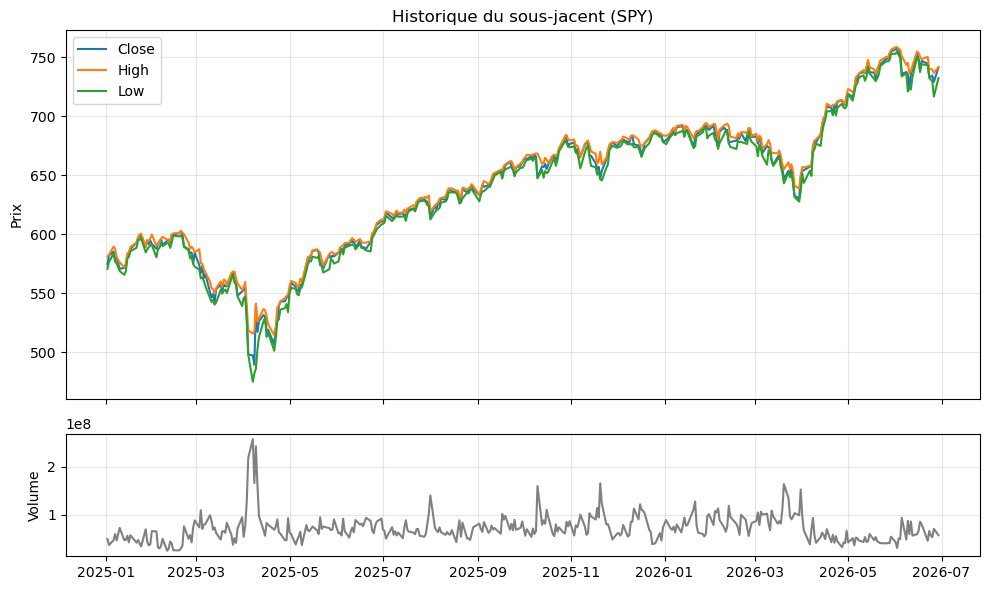

Maturities disponibles : ('2026-07-16', '2026-07-17', '2026-07-20', '2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-27', '2026-07-28', '2026-07-29', '2026-07-31', '2026-08-07', '2026-08-14', '2026-08-21', '2026-08-28', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-20', '2026-11-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-06-30', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')
Nombre de maturités : 34


,contractSymbol,kind,strike,lastPrice,impliedVolatility,Benchmark price BS
0,SPY260716C00680000,call,680.0,73.99,1.151371,105.207052
1,SPY260716C00685000,call,685.0,69.03,1.152836,102.379010
2,SPY260716C00690000,call,690.0,64.02,1.080327,95.292050
3,SPY260716C00700000,call,700.0,53.23,0.883302,77.966456
4,SPY260716C00705000,call,705.0,48.95,0.811037,70.790043
5,SPY260716C00708000,call,708.0,45.26,0.762209,66.146668
6,SPY260716C00710000,call,710.0,43.27,0.770022,65.465301
7,SPY260716C00711000,call,711.0,41.70,0.721927,62.004823
8,SPY260716C00714000,call,714.0,39.09,0.687991,58.241314
9,SPY260716C00715000,call,715.0,38.85,0.698001,58.278215


In [ ]:
ticker = "SPY"   # ou "AAPL"

if yf is None:      print("yfinance n'est pas installé dans cet environnement : la partie données de marché est ignorée.")
else:
    tk = yf.Ticker(ticker)

    # 1) Historique du sous-jacent
    spot_hist = yf.download(ticker,start="2025-01-01",end="2026-06-30",interval="1d",auto_adjust=True,progress=False)
    print("Historique spot :")
    display(spot_hist.tail())
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,gridspec_kw={"height_ratios": [3, 1]})
    ax1.plot(spot_hist.index, spot_hist["Close"], label="Close")
    ax1.plot(spot_hist.index, spot_hist["High"], label="High")
    ax1.plot(spot_hist.index, spot_hist["Low"], label="Low")
    ax1.set_title(f"Historique du sous-jacent ({ticker})")
    ax1.set_ylabel("Prix")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.plot(spot_hist.index, spot_hist["Volume"], color="gray")
    ax2.set_ylabel("Volume")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    spot = spot_hist["Close"].dropna().iloc[-1].item()  # dernier cours de clôture disponible, utilisé comme spot de référence 
    valuation_date = pd.Timestamp(spot_hist.index[-1])

    # 2) Liste des maturités disponibles
    expiries = tk.options
    if not expiries:        print("Aucune maturité disponible pour ce ticker.")
    else:
        print("Maturities disponibles :", expiries[:])
        print("Nombre de maturités :", len(expiries))
        expiry = expiries[0]
        maturity = pd.Timestamp(expiry)

        # 3) Chaîne d'options
        chain = tk.option_chain(expiry)
        calls = chain.calls.copy()
        puts = chain.puts.copy()

        # 4) Construction d'un petit univers de vanilles
        calls["kind"] = "call"
        puts["kind"] = "put"
        vanillas_market = pd.concat([calls, puts], ignore_index=True)

        cols = [c for c in ["contractSymbol","kind","strike","lastPrice","impliedVolatility","expiration"] if c in vanillas_market.columns]
        vanillas_market = vanillas_market[cols].copy()
        
        
        # Prix Black-Scholes théorique ligne par ligne
        def _bs_price_row(row):
            sigma = row["impliedVolatility"]
            if pd.isna(sigma) or sigma <= 0:    return np.nan

            if row["kind"] == "call":   prod = EuropeanCall(name="tmp",strike=float(row["strike"]),maturity_date=maturity,notional=1.0)
            else:                       prod = EuropeanPut(name="tmp",strike=float(row["strike"]),maturity_date=maturity,notional=1.0)

            return prod.price_bs(spot, valuation_date, rate, dividend_yield, sigma)

        vanillas_market["Benchmark price BS"] = vanillas_market.apply(_bs_price_row, axis=1)
        display(vanillas_market.head(10))
